# 2D Implmentation of the Helmoltz solver

2D Helmholtz Equation: Finite Difference Derivation and Spectral Decomposition

The 2D Helmholtz equation is:

$$
\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} + k^2 u = f(x, y)
$$

Discretization
* Domain: Split into an $ N \times M $ grid with spacing $ h = \frac{1}{N+1} $ in $ x $ and $ y $.
* Let $ u_{i,j} \approx u(x_i, y_j) $ and $ f_{i,j} = f(x_i, y_j) $, where $ x_i = ih $ and $ y_j = jh $.


Central Difference Approximation
The second derivatives are approximated as:

$$
\frac{\partial^2 u}{\partial x^2} \approx \frac{u_{i-1,j} - 2u_{i,j} + u_{i+1,j}}{h^2}, \quad \frac{\partial^2 u}{\partial y^2} \approx \frac{u_{i,j-1} - 2u_{i,j} + u_{i,j+1}}{h^2}
$$

Substituting into the Helmholtz Equation
$$
\frac{u_{i-1,j} + u_{i+1,j} + u_{i,j-1} + u_{i,j+1} - 4u_{i,j}}{h^2} + k^2 u_{i,j} = f_{i,j}
$$

Rearranging gives the linear equation for interior points:

$$
\frac{1}{h^2}u_{i-1,j} + \frac{1}{h^2}u_{i+1,j} + \frac{1}{h^2}u_{i,j-1} + \frac{1}{h^2}u_{i,j+1} + \left(\frac{-4}{h^2} + k^2\right)u_{i,j} = f_{i,j}
$$

Spectral Decomposition in the $ y $-Direction
To preserve the tridiagonal structure, decompose the problem using the Discrete Sine Transform (DST)} for Dirichlet BCs (or DCT for Neumann BCs):

Forward DST on $ f(x, y) $
* For each column $ x_i $, compute the spectral coefficients:
$$
\tilde{f}_{i,m} = \text{DST}\left[f_{i,j}\right] = \sum_{j=1}^{N_y-1} f_{i,j} \sin\left(\frac{m \pi j}{N_y}\right)
$$
This diagonalizes the $ y $-Laplacian into eigenvalues $ \lambda_m^{(y)} = -\frac{4}{h^2} \sin^2\left(\frac{m \pi h}{2L_y}\right) $.

Modified 1D Helmholtz Equations in $ x $:

For each mode $ m $, solve:
$$
\frac{d^2 \tilde{u}_m}{dx^2} + \left(k^2 - \lambda_m^{(y)}\right)\tilde{u}_m = \tilde{f}_m(x)
$$
*This is a tridiagonal system} identical to the 1D case, with effective wavenumber $ k_{\text{eff}}^2 = k^2 - \lambda_m^{(y)} $.

Matrix Form for Each Mode}

*For each $ m $, the tridiagonal matrix $ A_m $ has:

* Diagonal entries: $ \frac{-2}{h^2} + k_{\text{eff}}^2 $
* Off-diagonal entries: $ \frac{1}{h^2} $
* Solve $ A_m \tilde{u}_m = \tilde{f}_m $ using your 1D solver.

Inverse DST to Reconstruct $ u(x, y) $}

*For each column $ x_i $, compute:
$$
u_{i,j} = \text{Inverse DST}\left[\tilde{u}_{i,m}\right] = \frac{2}{N_y+1} \sum_{m=1}^{N_y-1} \tilde{u}_{i,m} \sin\left(\frac{m \pi j}{N_y}\right)
$$

Matrix Structure Summary

* Original 2D System: Block tridiagonal (not directly solvable with a 1D tridiagonal solver).
* After Spectral Decomposition}: Independent 1D tridiagonal systems for each mode $ m $.
* Key Advantage: Retains the efficiency of your 1D code by reducing the 2D problem to $ M $ 1D solves.




### Import the necessary modules

In [2]:
# make use of QLS jupyter env
import numpy as np
import scipy as sc
from linear_solvers import NumPyLinearSolver, HHL
from linear_solvers.matrices.tridiagonal_toeplitz import TridiagonalToeplitz
from linear_solvers.matrices.numpy_matrix import NumPyMatrix
from qiskit.utils import QuantumInstance
from numerical_solvers.thomas_algorithm import numerical_solvers
from qiskit.quantum_info import Statevector
from qiskit import Aer, transpile, execute
from scipy.sparse import diags
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
import warnings
import time

warnings.simplefilter('ignore')

### Define the Utility functions which we will need:

In [99]:
from math import log2
from os import error
import re
import stat
from turtle import color
from numpy import minimum
from pyparsing import line
from qiskit.utils import QuantumInstance
from sympy import E

def normalize(arr, t_min, t_max):
    """
    Normalize an array to a specified range [t_min, t_max].
    
    For data that spans both negative and positive values, this function
    uses a symmetric normalization (dividing by the maximum absolute value)
    to preserve the zero-crossing and the relative oscillatory behavior.
    
    For data that does not span both signs, it uses standard min-max normalization.
    """
    arr = np.array(arr)
    # Check if data spans both negative and positive values
    # Use symmetric normalization:
    max_abs = np.max(np.abs(arr))
    # Avoid division by zero
    if max_abs < 1e-12:
        norm_arr = arr.copy()
    else:
        norm_arr = arr / max_abs
    # If the target range is symmetric about zero (e.g., [-1, 1]),
    # then simply scale by the maximum absolute value.
    # Otherwise, map [-1, 1] to [t_min, t_max]:
    if t_min == -1 and t_max == 1:
        return norm_arr
    else:
        # Mapping from [-1,1] to [t_min, t_max]:
        return ((norm_arr + 1) / 2) * (t_max - t_min) + t_min
        
def qasm(solution, N, vector, backend, Nshots, backend_options, visual=False):
    """
    Extracts and normalizes the solution vector from measurement results of a quantum circuit.
    The circuit is executed using the provided backend and backend_options.
    
    Assumes that the measured bitstrings include the solution register as the last log2(len(vector)) bits.
    """

    # Record the start time
    start_time = time.time()
    
    vector_length = len(vector)
    sol_length = int(np.log2(vector_length))  # Number of qubits in solution register
    start = N - sol_length  # Starting index of the solution register
    
    # Get a copy of the circuit and add measurements
    qc = solution.state.copy()
    qc.measure_all()
    
    # Execute the circuit using the provided backend and backend options
    backend.set_options(**backend_options)
    job = execute(qc, backend, shots=Nshots)
    result = job.result()
    counts = result.get_counts(qc)
    total_shots = sum(counts.values())
    
    if visual:
        hist = counts
        # Create a histogram from the counts
        bitstrings = list(hist.keys())
        frequencies = list(hist.values())
    
        plt.figure(figsize=(10, 6))
        plt.xticks(rotation=45, ha='right')
        plt.bar(bitstrings, frequencies)
        plt.xlabel('Bitstrings')
        plt.ylabel('Counts')
        plt.grid(axis='y', alpha=0.5)
        plt.title('Histogram of QASM Results')
        plt.show()

    sol_counts = np.zeros(vector_length)  # Initialize the solution counts array

    # Process counts: extract only those bitstrings where the first bit is '1' and the clock bits (from index 1 to start-1) are all '0'
    for bitstring, count in counts.items():
        clock_bits = bitstring[1:start]
        if bitstring[0] == '1' and all(b == '0' for b in clock_bits):
            # Extract the solution register bits (from position 'start' onward)
            sol_bitstring = bitstring[start:]
            index = int(sol_bitstring, 2)
            sol_counts[index] += count

    # Compute probabilities, then amplitudes (square roots of probabilities)
    sol_probs = sol_counts / total_shots
    sol_amplitudes = np.sqrt(np.abs(sol_probs))
    
    # Scale the amplitudes by the euclidean norm provided by the solution object
    sol_norm = np.linalg.norm(sol_amplitudes)
    if sol_norm == 0:
        normalized_amplitudes = sol_amplitudes
    else:
        normalized_amplitudes = sol_amplitudes / sol_norm
        
    end_time = time.time()
    print(f"qasm execution time: {end_time - start_time}")
    
    return normalized_amplitudes

def statevector(solution, N, vector, Nshots):
    """Extracts and normalizes simulated state vector from LinearSolverResult."""
    # Record the start time
    start_time_total = time.time()
    start = int(2**(N-1))
    fin = int(2**(N-1) + len(vector))
    
    qc = solution.state.copy()
    qc.remove_final_measurements()

    backend = Aer.get_backend('statevector_simulator')
    job = execute(qc, backend, shots=Nshots)
    result = job.result()
    
    # Extract the state vector
    sv = result.get_statevector(qc)
    
    # Extraction
    solution_vector = sv.data[start:fin]
    solution_vector = np.real(solution_vector)
    
    #print("Statevector from Aer execution:", solution_vector)
    # Record the end time
    end_time = time.time()
    #print(f"State Vector execution time: {end_time - start_time_total}")
    
    return solution_vector

def construct_TT_matrix(main_diag, off_diag, size):
    '''
    Construct a tridiagonal Toeplitz matrix using the main diagonal and off-diagonal elements.
    '''
    matrix = diags([off_diag, main_diag, off_diag], offsets=[-1, 0, 1], shape=(size, size)).toarray()
    
    print(f'Matrix Condition number: {np.linalg.cond(matrix)}')
    return matrix

def construct_preconditioner(matrix, vector,h,k, alpha):
    """
    Return the numpy preconditioned matrix and vector for the given matrix and vector.
    """
    main_diag = matrix[0, 0]
    off_diag = matrix[0, 1]
    size = matrix.shape[0]

    # Build the complex-shifted Laplacian preconditioner
    a_shifted = -4 / h**2 + k**2 * (1 - 1j * alpha)
    b_shifted = 1 / h**2
    a_real = np.real(a_shifted)
    a_imag = np.imag(a_shifted)
    b_real = np.real(b_shifted)
    P_real = diags([b_real, a_real, b_real], [-1, 0, 1], shape=(size, size)).toarray()
    P_imag = diags([0, a_imag, 0], [-1, 0, 1], shape=(size, size)).toarray()
    P_complex = P_real + 1j * P_imag
    # Ensure the preconditioner matrix is positive definite
   # 7) Classical preconditioning
    P_inv = np.linalg.inv(P_complex)
    prec_matrix_complex = P_inv @ matrix
    prec_vector_complex = P_inv @ vector
    prec_matrix = np.real(prec_matrix_complex)
    prec_vector = np.real(prec_vector_complex)

    # 8) Approximate preconditioned matrix as TridiagonalToeplitz
    a_prec = np.mean(np.diag(prec_matrix))
    b_prec = np.mean(np.diag(prec_matrix, 1))

    matrix_prec = construct_TT_matrix(a_prec, b_prec, size)
    print('Preconditioner Condition number: ', np.linalg.cond(matrix_prec))
    return matrix_prec, prec_vector

def solve_1DHHL(matrix, vector, qubits, epsilon=0.01):
    '''
    Solves the 1D HHL
    '''
    a = matrix[0, 0]
    b = matrix[0, 1]
    # Set up quantum instance
    backend = Aer.get_backend('qasm_simulator')
    backend_options = {
    'max_parallel_threads': 8,      # use up to 4 threads
    'max_parallel_experiments': 16,    # run up to 2 experiments in parallel
    'seed_simulator': 42,            # set a seed for reproducibility
    }
    num_shots = 10000
    quantum_instance = QuantumInstance(backend, shots=num_shots, backend_options=backend_options)

    tridi_mat = TridiagonalToeplitz(qubits, a, b)
    hhl_solver = HHL(epsilon=epsilon, quantum_instance=quantum_instance)
    hhl_solution_obj = hhl_solver.solve(tridi_mat, vector)
 
    return hhl_solution_obj

def solve_1DHHL_Numpy(matrix, vector, qubits, epsilon=0.001):
    '''
    Solves the 1D HHL
    '''
    a = matrix[0, 0]
    b = matrix[0, 1]
    # Set up quantum instance
    backend = Aer.get_backend('qasm_simulator')
    backend_options = {
    'max_parallel_threads': 8,      # use up to 4 threads
    'max_parallel_experiments': 16,    # run up to 2 experiments in parallel
    'seed_simulator': 42,            # set a seed for reproducibility
    }
    num_shots = 1000
    quantum_instance = QuantumInstance(backend, shots=num_shots, backend_options=backend_options)

    mat = NumPyMatrix(matrix)
    hhl_solver = HHL(epsilon=epsilon, quantum_instance=quantum_instance)
    hhl_solution_obj = hhl_solver.solve(mat, vector)
 
    return hhl_solution_obj

def solve_1DHHL_prec(matrix, vector, qubits, alpha ,h,k,epsilon=0.001):
    '''
    Solves the 1D HHL using preconditioning
    '''
    matrix_prec, vector_prec = construct_preconditioner(matrix, vector, alpha, h, k)
    a = matrix_prec[0, 0]
    b = matrix_prec[0, 1]

    # Set up quantum instance
    backend = Aer.get_backend('qasm_simulator')
    backend_options = {
    'max_parallel_threads': 8,      # use up to 4 threads
    'max_parallel_experiments': 16,    # run up to 2 experiments in parallel
    'seed_simulator': 42,            # set a seed for reproducibility
    }
    num_shots = 1000
    quantum_instance = QuantumInstance(backend, shots=num_shots, backend_options=backend_options)

    tridi_mat = TridiagonalToeplitz(qubits, a, b)
    hhl_solver = HHL(epsilon=epsilon, quantum_instance=quantum_instance)
    hhl_solution_obj = hhl_solver.solve(tridi_mat, vector_prec)
 
    return hhl_solution_obj

def solve_1DThomas(matrix, vector):
    '''
    Solves the 1D Thomas algorithm
    '''
    
    # Compare to thomas
    matrix1 = matrix.copy()
    vector1 = vector.copy()
    thomas = numerical_solvers()
    num_solution = thomas.solve_tridiagonal_thomas(matrix1, vector1)
    #num_solution = np.concatenate(([0], num_solution, [0]))
    #num_solution = normalize(num_solution, -1.0, 1.0)
    return num_solution

def generate_forcing_function(Nx, Ny, Lx, Ly, forcing_type='uniform', **kwargs):
    """
    Generates a forcing function (RHS) for the 2D Helmholtz equation.
    
    Parameters:
        Nx, Ny : int
            Number of interior grid points in the x and y directions.
        Lx, Ly : float
            Domain lengths in x and y.
        forcing_type : str
            Type of forcing function to generate:
            - 'uniform': Constant value across domain
            - 'point_source': Point source at specified location
            - 'gaussian': Gaussian source
            - 'sinusoidal': Sinusoidal pattern
            - 'manufactured': Manufactured solution (for verification)
            - 'custom': Custom function provided as lambda
        **kwargs : dict
            Additional parameters for specific forcing types:
            - 'uniform': value (default=1.0)
            - 'point_source': x0, y0 (position), amplitude (default=1.0)
            - 'gaussian': x0, y0 (center), sigma (width), amplitude (default=1.0)
            - 'sinusoidal': kx, ky (wave numbers), amplitude (default=1.0)
            - 'manufactured': k (wave number from Helmholtz operator)
            - 'custom': func (lambda function taking x, y arrays)
    
    Returns:
        f : numpy.ndarray
            The forcing function as a flattened array of shape (Nx*Ny,).
        f_grid : numpy.ndarray
            The forcing function as a 2D grid of shape (Ny, Nx).
        x_grid, y_grid : numpy.ndarray
            Meshgrid of x and y coordinates.
    """
    # Compute grid spacings and coordinates
    hx = Lx / (Nx + 1)
    hy = Ly / (Ny + 1)
    
    # Create interior grid points
    x = np.linspace(hx, Lx - hx, Nx)
    y = np.linspace(hy, Ly - hy, Ny)
    x_grid, y_grid = np.meshgrid(x, y)
    
    # Initialize forcing function grid
    f_grid = np.zeros((Ny, Nx))
    
    # Generate forcing function based on type
    if forcing_type == 'uniform':
        value = kwargs.get('value', 1.0)
        f_grid = np.ones((Ny, Nx)) * value
        
    elif forcing_type == 'point_source':
        x0 = kwargs.get('x0', Lx/2)
        y0 = kwargs.get('y0', Ly/2)
        amplitude = kwargs.get('amplitude', 1.0)
        
        # Find closest grid point
        idx_x = np.argmin(np.abs(x - x0))
        idx_y = np.argmin(np.abs(y - y0))
        f_grid[idx_y, idx_x] = amplitude
        
    elif forcing_type == 'gaussian':
        x0 = kwargs.get('x0', Lx/2)
        y0 = kwargs.get('y0', Ly/2)
        sigma = kwargs.get('sigma', min(Lx, Ly)/8)
        amplitude = kwargs.get('amplitude', 1.0)
        
        f_grid = amplitude * np.exp(-((x_grid - x0)**2 + (y_grid - y0)**2) / (2 * sigma**2))
        
    elif forcing_type == 'sinusoidal':
        kx = kwargs.get('kx', np.pi/Lx)
        ky = kwargs.get('ky', np.pi/Ly)
        amplitude = kwargs.get('amplitude', 1.0)
        
        f_grid = amplitude * np.sin(kx * x_grid) * np.sin(ky * y_grid)
        
    elif forcing_type == 'manufactured':
        # For method of manufactured solutions, we choose a known solution u
        # and compute f = -∇²u - k²u
        k = kwargs.get('k', 1.0)
        
        # Define a known analytic solution that satisfies boundary conditions
        u_exact = np.sin(np.pi * x_grid / Lx) * np.sin(np.pi * y_grid / Ly)
        
        # Compute second derivatives for the Laplacian
        d2u_dx2 = -(np.pi/Lx)**2 * u_exact
        d2u_dy2 = -(np.pi/Ly)**2 * u_exact
        
        # Compute f = -∇²u - k²u
        f_grid = -(d2u_dx2 + d2u_dy2) - k**2 * u_exact
        
    elif forcing_type == 'custom':
        func = kwargs.get('func', lambda x, y: np.zeros_like(x))
        f_grid = func(x_grid, y_grid)
    
    else:
        raise ValueError(f"Unknown forcing_type: {forcing_type}")
    
    # Flatten the grid to match the format expected by the solver
    f = f_grid.flatten()
    
    return f, f_grid, x_grid, y_grid

def plot_forcing_function(f_grid, x_grid, y_grid, title="Forcing Function"):
    """
    Plot the 2D forcing function.
    
    Parameters:
        f_grid : numpy.ndarray
            The forcing function as a 2D grid.
        x_grid, y_grid : numpy.ndarray
            Meshgrid of x and y coordinates.
        title : str
            Plot title.
    """
    plt.figure(figsize=(6, 4))
    
    # Surface plot
    ax1 = plt.subplot(121, projection='3d')
    surf = ax1.plot_surface(x_grid, y_grid, f_grid, cmap='viridis')
    ax1.set_xlabel('x')
    ax1.set_ylabel('y')
    ax1.set_zlabel('f(x,y)')
    ax1.set_title('3D View')
    
    # 2D heatmap
    ax2 = plt.subplot(122)
    im = ax2.pcolormesh(x_grid, y_grid, f_grid, cmap='viridis', shading='auto')
    plt.colorbar(im, ax=ax2)
    ax2.set_xlabel('x')
    ax2.set_ylabel('y')
    ax2.set_title('2D View')
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

def ADI_qasm(u, Ax, Ay, f_interior, backend = None,backend_options=None, max_iter=4):
    """
    A general ADI method for comparing quantum (HHL) and Thomas solutions,
    using QASM simulation for the quantum solver. No analytic solution is referenced.
    """
    fun_start = time.time()
    N = u.shape[0]
    NUM_QUBITS = int(np.log2(N))

    backend = backend
    backend_options =backend_options
    # Arrays to store differences between HHL and Thomas each iteration
    errors = []
    pct_diff_list = []

    # Initialize local copies of the solution
    u_hhl = u.copy()
    u_thomas = u.copy()

    iter_count = 0
    while iter_count < max_iter:
        print(f'Iteration: {iter_count}')

        # 1) Treat x as implicit and y as explicit
        start = time.time()
        for j in range(N):
            f_j = f_interior[j, :].copy()

            # Absorb top/bottom neighbors
            top_row = u_hhl[j + 1, :] if j + 1 < N else np.zeros(N)
            bottom_row = u_hhl[j - 1, :] if j - 1 >= 0 else np.zeros(N)
            f_j_hhl = f_j - top_row - bottom_row

            top_row_t = u_thomas[j + 1, :] if j + 1 < N else np.zeros(N)
            bottom_row_t = u_thomas[j - 1, :] if j - 1 >= 0 else np.zeros(N)
            f_j_thomas = f_j - top_row_t - bottom_row_t

            # Solve via Thomas
            solution_thomas = solve_1DThomas(Ax, f_j_thomas)

            # Solve via HHL
            solution_hhl_obj = solve_1DHHL(Ax, f_j_hhl, NUM_QUBITS)
            euclidian_norm = solution_hhl_obj.euclidean_norm
            solution_hhl_vec = qasm(
                solution_hhl_obj,
                solution_hhl_obj.state.num_qubits,
                f_j_hhl,
                backend,
                1000,
                backend_options,
                visual=False
            )
            # Scale HHL to match the sign and norm of Thomas solution
            solution_hhl_vec = (
                np.sign(solution_thomas)
                * solution_hhl_vec
                * euclidian_norm
                / np.linalg.norm(solution_hhl_vec)
            )

            # Update solutions
            u_hhl[j, :] = solution_hhl_vec
            u_thomas[j, :] = solution_thomas

        print('Columns computed in:', time.time() - start)

        # 2) Treat y as implicit and x as explicit
        start = time.time()
        for i in range(N):
            f_i = f_interior[:, i].copy()

            # Absorb left/right neighbors
            left_col = u_hhl[:, i - 1] if i - 1 >= 0 else np.zeros(N)
            right_col = u_hhl[:, i + 1] if i + 1 < N else np.zeros(N)
            f_i_hhl = f_i - left_col - right_col

            left_col_t = u_thomas[:, i - 1] if i - 1 >= 0 else np.zeros(N)
            right_col_t = u_thomas[:, i + 1] if i + 1 < N else np.zeros(N)
            f_i_thomas = f_i - left_col_t - right_col_t

            # Solve via Thomas
            solution_thomas = solve_1DThomas(Ay, f_i_thomas)

            # Solve via HHL
            solution_hhl_obj = solve_1DHHL(Ay, f_i_hhl, NUM_QUBITS)
            solution_hhl_vec = qasm(
                solution_hhl_obj,
                solution_hhl_obj.state.num_qubits,
                f_i_hhl,
                backend,
                1000,
                backend_options,
                visual=False
            )
            solution_hhl_vec = (
                np.sign(solution_thomas)
                * solution_hhl_vec
                * np.linalg.norm(solution_thomas)
                / np.linalg.norm(solution_hhl_vec)
            )

            # Update solutions
            u_hhl[:, i] = solution_hhl_vec
            u_thomas[:, i] = solution_thomas

        print('Rows computed in:', time.time() - start)

        # Now compute the difference metrics
        diff_norm = np.linalg.norm(u_hhl - u_thomas)
        percent_diff = np.abs(u_hhl - u_thomas) / np.maximum(np.abs(u_thomas), 1e-12)
        errors.append(diff_norm)
        pct_diff_list.append(percent_diff)
        print("Norm of difference (HHL vs Thomas):", diff_norm)
        print(f"Percent difference array:\n{percent_diff}\n")

        iter_count += 1

    print('ADI run time:', time.time() - fun_start)

    return u_hhl, u_thomas, errors, pct_diff_list

def prepare_pseudoanalytic(Lx, Ly, k, N_high_res=100, type = 'gaussian'):
    """
    Prepare a pseudo-analytic solution using the ADI method with higher resolution.

    Parameters:
        f_high_grid : numpy.ndarray
            Forcing function grid at higher resolution.
        Lx, Ly : float
            Domain lengths in x and y directions.
        k : float
            Wave number for the Helmholtz equation.
        y_grid : numpy.ndarray
            Grid points in the y-direction.
        function : str, optional
            Description of the function being prepared (default is "Solution").
        N_high_res : int, optional
            Higher resolution grid size (default is 100).

    Returns:
        u_analytic_high_res : numpy.ndarray
            Pseudo-analytic solution at higher resolution.
        X_high_res, Y_high_res : numpy.ndarray
            Meshgrid of x and y coordinates at higher resolution.
    """
    # Define higher resolution parameters
    dx_high_res = Lx / (N_high_res + 1)
    dy_high_res = Ly / (N_high_res + 1)
    h_high_res = dx_high_res

    # Reconstruct the operator matrices for higher resolution
    main_diag_high_res = -4 / h_high_res**2 + k**2
    off_diag_high_res = 1 / h_high_res**2
    Ax_high_res = construct_TT_matrix(main_diag=main_diag_high_res, off_diag=off_diag_high_res, size=N_high_res)
    Ay_high_res = Ax_high_res

    # Generate the forcing function for higher resolution
    if type == 'gaussian':
        _, f_high_res_grid, _, _ = generate_forcing_function(
            N_high_res, N_high_res, Lx, Ly, forcing_type=type, x0=Lx/2, y0=Ly/2, sigma=0.1, amplitude=1.0
        )
    elif type == 'uniform':
        # Generate the forcing function for higher resolution
        _, f_high_res_grid, _, _ = generate_forcing_function(
            N_high_res, N_high_res, Lx, Ly, forcing_type='uniform', value=1.0
        )
    else:
        print('Invalid selection of forcing function type.')
        return None

    
    # Initialize the solution for higher resolution
    u_init_high_res = np.zeros((N_high_res, N_high_res))

    # Solve using the ADI method with the Thomas algorithm
    u_high_res_tom = ADI(u_init_high_res, Ax_high_res, Ay_high_res, f_high_res_grid)

    # Generate the high-resolution grid for visualization
    X_high_res, Y_high_res = np.meshgrid(np.linspace(0, Lx, N_high_res + 2), np.linspace(0, Ly, N_high_res + 2), indexing='ij')
    u_analytic_high_res = np.pad(u_high_res_tom, pad_width=1, mode='constant', constant_values=0)

    return u_analytic_high_res, X_high_res, Y_high_res

def ADI_sv_prec(u, Ax, Ay, f_interior,h, k, alpha = 0.1, max_iter = 4):
    """
        ADI with statevector simulator and preconditioning
    """
    fun_start = time.time() 
    N = u.shape[0]
    NUM_QUBITS = int(np.log2(N))
    
    # Necessary for error calculation
    pct_diff = []
    u_hhl = u.copy()
    u_thomas = u.copy()
    iter = 0
    while iter < max_iter:
        print(f'Iteration: {iter}')
        start = time.time()
        # Now treat x as implicit and the y as explicit
        for j in range(N):
            # Extract the f for this row
            f_j = f_interior[j, :].copy()
            
            # Absorb the top row and bottom row into the vector
            topu_hhl = u_hhl[j + 1, :] if j + 1 < N else np.zeros(N)
            bottomu_hhl = u_hhl[j - 1, :] if j - 1 >= 0 else np.zeros(N)
            f_j_hhl = f_j - topu_hhl - bottomu_hhl
            
            topu_thomas = u_thomas[j + 1, :] if j + 1 < N else np.zeros(N)
            bottomu_thomas = u_thomas[j - 1, :] if j - 1 >= 0 else np.zeros(N)
            f_j_thomas = f_j - topu_thomas - bottomu_thomas
            

            # Solve using Thomas
            solution_thomas = solve_1DThomas(Ax, f_j_thomas)

            # Solve using HHL
            solution_hhl = solve_1DHHL_prec(Ax, f_j_hhl, NUM_QUBITS, alpha, h, k)
            solution_hhl = statevector(solution_hhl, solution_hhl.state.num_qubits, f_j_hhl, 1000)
            solution_hhl = solution_hhl * np.linalg.norm(solution_thomas) / np.linalg.norm(solution_hhl)
            
            
            # Update the solutions
            u_hhl[j, :] = solution_hhl
            u_thomas[j, :] = solution_thomas
        
        print('Columns computed in:', time.time() - start)
        
        
        # Now treat y as implicit and the x as explicit
        start = time.time()
        for i in range(N):
            # Extract the f for this column
            f_i = f_interior[:, i].copy()
            
            # Absorb the left column and right column into the vector
            leftu_hhl = u_hhl[:, i - 1] if i - 1 >= 0 else np.zeros(N)
            rightu_hhl = u_hhl[:, i + 1] if i + 1 < N else np.zeros(N)
            f_i_hhl = f_i - leftu_hhl - rightu_hhl
            
            leftu_thomas = u_thomas[:, i - 1] if i - 1 >= 0 else np.zeros(N)
            rightu_thomas = u_thomas[:, i + 1] if i + 1 < N else np.zeros(N)
            f_i_thomas = f_i - leftu_thomas - rightu_thomas
            
            # Solve using Thomas
            solution_thomas = solve_1DThomas(Ay, f_i_thomas)

            # Solve using HHL
            solution_hhl = solve_1DHHL_prec(Ay, f_i_hhl, NUM_QUBITS, alpha, h, k)
            solution_hhl = statevector(solution_hhl, solution_hhl.state.num_qubits, f_i_hhl, 10000)
            solution_hhl = solution_hhl * np.linalg.norm(solution_thomas) / np.linalg.norm(solution_hhl)        
            
            # Update the solutions
            u_hhl[:, i] = solution_hhl
            u_thomas[:, i] = solution_thomas
        
        print('Rows computed in:', time.time() - start)

        # compute the percentdifference to the thomas
        percent_diff = np.abs(u_hhl - u_thomas) / np.abs(u_thomas)
        pct_diff.append(percent_diff)
        print('Percent Difference to Thomas: \n', percent_diff)
        
        iter += 1
    print('ADI run time:', time.time() - fun_start)            

    return u_hhl, u_thomas, pct_diff

def ADI_val_sv(u, f_interior, u_analytical_resampled, shift,k, ek, eps_tol = 1e-3, max_iter=3, numShots=1000):
    """
    ADI validation for the Helmholtz equation using a shift parameter.

    The ADI splitting for Helmholtz here applies a shift to each directional solve,
    i.e., we solve modified 1D systems of the form:

        (A + shift*I) u* = [f - (neighbors)] + shift*u_current,

    in both the x (row) and y (column) sweeps.

    Parameters:
      u                     : initial guess for u (2D numpy array)
      Ax, Ay                : coefficient matrices for x and y directions (N x N arrays)
      f_interior            : right-hand side for the interior grid points
      u_analytical_resampled: analytical solution (resampled onto grid) for error evaluation
      shift                 : shift parameter to be added to the matrices and forcing term
      max_iter              : number of ADI iterations
      numShots              : shots for the HHL statevector simulation

    Returns:
      u_hhl, u_thomas : final solution arrays from the HHL and Thomas solvers, respectively
      errors        : list of tuples containing the L2 norm error and mean absolute error
                      for HHL and Thomas compared to the analytical solution per iteration:
                      [((l2_error_hhl, mean_error_hhl), (l2_error_thomas, mean_error_thomas)), ...]
      pct_diff      : list of element-wise percent differences between the HHL and Thomas solutions.
    """
    fun_start = time.time() 
    N = u.shape[0]
    h = 1.0/(N + 1)
    iteration = 0
    NUM_QUBITS = int(np.log2(N))
    errors = []
    depth = []

    # Inside the function, before the main loop:
    a = 1.0 / h**2
    
    diag_x = shift + 2.0*a - (k**2)/2.0
    off_diag_x = -a
    diag_y = shift + 2.0*a - (k**2)/2.0
    offdiag_y = -a
    
    
    Ax_implicit = np.diag(np.full(N, diag_x)) + \
              np.diag(np.full(N-1, off_diag_x), 1) + \
              np.diag(np.full(N-1, off_diag_x), -1)
              
    Ay_implicit = np.diag(np.full(N, diag_y)) + \
            np.diag(np.full(N-1, offdiag_y), 1) + \
            np.diag(np.full(N-1, offdiag_y), -1)
            
    # Compute the minimum eps_tol for the HHL solver
    print(f"For {NUM_QUBITS}, Condition number of matrx:{ np.linalg.cond(Ax_implicit)}")
    eigenvalues = np.linalg.eigvals(Ax_implicit)
        
    # reciprocal eigenvalue spectrum
    spectrum = max(1/eigenvalues) - min(1/eigenvalues)
    print(f"Reciprocal eigenvalue spectrum: {spectrum}, with eps_tol: {eps_tol}")
    
    if spectrum < eps_tol:
        print('Warning: Spectrum is too small')
        eps_tol = round(spectrum, -int(np.floor(np.log10(abs(spectrum)))))
        eps_tol = 0.01* eps_tol
        # round to the 1st non zero digit
        print(f" New eps_tol: {eps_tol}")
    
             
    u_hhl = u.copy()
    u_thomas = u.copy()
    
    u_hhl_prev = u_hhl.copy() # Solution from previous iteration (n)
    u_hhl_intermediate = np.zeros_like(u_hhl) # Solution after x-sweep (n+1/2)
    u_hhl_next = np.zeros_like(u) # Solution after y-sweep (n+1)
    
    u_thomas_prev = u_thomas.copy() # Solution from previous iteration (n)
    u_thomas_intermediate = np.zeros_like(u_thomas) # Solution after x-sweep (n+1/2)
    u_thomas_next = np.zeros_like(u) # Solution after y-sweep (n+1)

    for iteration in range(max_iter):
        
        # Y-sweep (column-by-column solve)
        for j in range(N): # Loop over rows
            u_j = u_hhl_prev[j, :]
            u_jp1 = u_hhl_prev[j+1, :] if j+1 < N else np.zeros(N) # Apply BC
            u_jm1 = u_hhl_prev[j-1, :] if j-1 >= 0 else np.zeros(N) # Apply BC

            delta_y_vec = a * (u_jp1 - 2*u_j + u_jm1)
            RHS_x_vec = (delta_y_vec + (k**2)/2.0 * u_j + shift * u_j) - f_interior[j, :]
            
            hhl_solution_obj = solve_1DHHL(Ax_implicit, RHS_x_vec, NUM_QUBITS, epsilon=eps_tol) # Use correct implicit matrix
            hhl_norm = hhl_solution_obj.euclidean_norm
            depth1 = transpile(hhl_solution_obj.state, basis_gates=['id', 'rz', 'sx', 'x', 'cx'])
            depth1 = depth1.depth()
            solution_hhl = statevector(hhl_solution_obj, hhl_solution_obj.state.num_qubits, RHS_x_vec, numShots)
            psi_norm = np.linalg.norm(solution_hhl)
            x_phys =  (hhl_norm / psi_norm) * solution_hhl
            x_phys = x_phys * np.linalg.norm(RHS_x_vec)
            
            u_hhl_intermediate[j, :] = x_phys # Store intermediate solution
            
            del u_jp1, u_jm1 # Free up memory

            u_j = u_thomas_prev[j, :]
            u_jp1 = u_thomas_prev[j+1, :] if j+1 < N else np.zeros(N) # Apply BC
            u_jm1 = u_thomas_prev[j-1, :] if j-1 >= 0 else np.zeros(N) # Apply BC

            delta_y_vec = a * (u_jp1 - 2*u_j + u_jm1)
            RHS_x_vec = (delta_y_vec + (k**2)/2.0 * u_j + shift * u_j) - f_interior[j, :]
            
            # Solve the tridiagonal system for row j
            u_thomas_intermediate[j, :] = solve_1DThomas(Ax_implicit, RHS_x_vec) # Use correct implicit matrix
            
            del u_jp1, u_jm1 # Free up memory
        
        for i in range(N):
            u_i = u_hhl_intermediate[:, i]
            u_ip1 = u_hhl_intermediate[:, i+1] if i+1 < N else np.zeros(N) # Apply BC
            u_im1 = u_hhl_intermediate[:, i-1] if i-1 >= 0 else np.zeros(N) # Apply BC
            
            delta_x_vec = a * (u_ip1 - 2*u_i + u_im1)
            RHS_y_vec = (delta_x_vec + (k**2)/2.0 * u_i + shift * u_i) - f_interior[:, i]
            
            hhl_solution_obj = solve_1DHHL(Ay_implicit, RHS_y_vec, NUM_QUBITS, epsilon=eps_tol) # Use correct implicit matrix
            hhl_norm = hhl_solution_obj.euclidean_norm
            depth2 =  transpile(hhl_solution_obj.state, basis_gates=['id', 'rz', 'sx', 'x', 'cx'])
            depth2 = depth2.depth()
            solution_hhl = statevector(hhl_solution_obj, hhl_solution_obj.state.num_qubits, RHS_y_vec, numShots)
            psi_norm = np.linalg.norm(solution_hhl)
            y_phys =  (hhl_norm / psi_norm) * solution_hhl
            y_phys = y_phys * np.linalg.norm(RHS_y_vec)
            
            u_hhl_next[:, i] = y_phys # Store intermediate solution
            
            del u_ip1, u_im1 # Free up memory
            
            u_i = u_thomas_intermediate[:, i]
            u_ip1 = u_thomas_intermediate[:, i+1] if i+1 < N else np.zeros(N) # Apply BC
            u_im1 = u_thomas_intermediate[:, i-1] if i-1 >= 0 else np.zeros(N) # Apply BC
            
            delta_x_vec = a * (u_ip1 - 2*u_i + u_im1)
            RHS_y_vec = (delta_x_vec + (k**2)/2.0 * u_i + shift * u_i) - f_interior[:, i]
            
            # Solve the tridiagonal system for column i
            u_thomas_next[:, i] = solve_1DThomas(Ay_implicit, RHS_y_vec) # Use correct implicit matrix
            
            del u_ip1, u_im1 # Free up memory
            
        # Update the solutions for the next iteration
        u_hhl = u_hhl_next.copy()
        u_thomas = u_thomas_next.copy()
        
       
            
        # Compute the L2 norm errors and mean absolute errors.
        diff = u_thomas - u_analytical_resampled  # both shape (N,N)
        E2_thomas = np.sqrt(h**2 * np.sum(diff**2))
        Einf_thomas = np.max(np.abs(diff))
        mae_thomas = np.mean(np.abs(diff))

        
        diff = u_hhl - u_analytical_resampled  # both shape (N,N)
        E2_hhl = np.sqrt(h**2 * np.sum(diff**2))
        Einf_hhl = np.max(np.abs(diff))
        mae_hhl = np.mean(np.abs(diff))
        

        rel_diff = u_hhl - u_thomas
        E2_rel = np.sqrt(h**2 * np.sum(rel_diff**2))
        Einf_rel = np.max(np.abs(rel_diff))
        mae_rel = np.mean(np.abs(rel_diff))
        
        depth= np.mean([depth1, depth2])

        tmp = [E2_thomas, Einf_thomas, mae_thomas, E2_hhl, Einf_hhl, mae_hhl, mae_rel, E2_rel, Einf_rel]
        errors.append(tmp)
    
        
        # Print the errors and percent differences.
        print(f"Iteration {iteration+1}:")
        print(f"  L2 norm error (Thomas): {E2_thomas:.6f}")
        print(f"  L∞ norm error (Thomas): {Einf_thomas:.6f}")
        print(f"  Mean absolute error (Thomas): {mae_thomas:.6f}")
        print()
        print(f"  L2 norm error (HHL): {E2_hhl:.6f}")
        print(f"  L∞ norm error (HHL): {Einf_hhl:.6f}")
        print(f"  Mean absolute error (HHL): {mae_hhl:.6f}")
        print()
        print(f"  Mean absolute error (Relative): {mae_rel:.6f}")
        print(f"  L2 norm error (Relative): {E2_rel:.6f}")
        print(f"  L∞ norm error (Relative): {Einf_rel:.6f}")
        
        # convergence check
        tol = u_hhl_next - u_hhl_prev
        if np.linalg.norm(tol) < ek:
            print(f"Converged at iteration {iteration+1} with tolerance {np.linalg.norm(tol)}")
            break
        
        # update the solutions for the next iteration
        u_hhl_prev = u_hhl_next.copy()
        u_thomas_prev = u_thomas_next.copy()
    
    return u_hhl, u_thomas, errors, eps_tol, depth

def plot_convergence(errors, nb, k, eps_tol, ek):
    """
    Plots convergence metrics stored in the errors list.

    Args:
        errors (list): A list where each element is a list/tuple containing error metrics
                       for one iteration in the order:
                       [E2_T, Einf_T, MAE_T, E2_H, Einf_H, MAE_H, MAE_R, E2_R, Einf_R]
                       where T=Thomas, H=HHL, R=Relative (HHL vs Thomas).
    """
    if not errors:
        print("Error list is empty, cannot generate plots.")
        return

    # Convert the list of lists/tuples into a NumPy array for easier slicing
    # Shape will be (num_iterations, num_error_metrics)
    errors_array = np.array(errors)
    num_iterations = errors_array.shape[0]

    # Create an array representing the iteration number (starting from 1)
    iterations = np.arange(1, num_iterations + 1)

    # --- Plot 1: Thomas Solver Convergence (vs Analytical) ---
    plt.figure(figsize=(6, 5)) # Adjust figure size as needed
    plt.plot(iterations, errors_array[:, 0], label='L2 Norm (Thomas)', marker='o', linestyle='-', markersize=4)
    plt.plot(iterations, errors_array[:, 1], label='Inf Norm (Thomas)', marker='s', linestyle='-', markersize=4)
    plt.plot(iterations, errors_array[:, 2], label='MAE (Thomas)', marker='^', linestyle='-', markersize=4)

    plt.xlabel('Iteration Number')
    plt.ylabel('Error Norm')
    #plt.title('Convergence of Thomas Solver (vs Analytical Solution)')
    plt.yscale('log')  # Use logarithmic scale for error visualization
    plt.legend()       # Display the legend
    plt.grid(True, which='both', linestyle='--', linewidth=0.5) # Add grid for readability
    plt.tight_layout() # Adjust layout to prevent labels overlapping
    plt.savefig(f'figures/2D/Thomas_convergence_N{nb}_k{k}_eps{eps_tol}_ek={ek}.png', dpi=300)  # Save the figure if needed
    plt.show()         # Display the plot

    # --- Plot 2: HHL Solver Convergence (vs Analytical) ---
    plt.figure(figsize=(6, 5))
    # Use different linestyles or colors if desired to distinguish from Thomas plot easily
    plt.plot(iterations, errors_array[:, 3], label='L2 Norm (HHL)', marker='o', linestyle='--', markersize=4)
    plt.plot(iterations, errors_array[:, 4], label='Inf Norm (HHL)', marker='s', linestyle='--', markersize=4)
    plt.plot(iterations, errors_array[:, 5], label='MAE (HHL)', marker='^', linestyle='--', markersize=4)

    plt.xlabel('Iteration Number')
    plt.ylabel('Error Norm')
    #plt.title('Convergence of HHL Solver (vs Analytical Solution)')
    plt.yscale('log')
    plt.legend()
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.savefig(f'figures/2D/HHL_convergence_N{nb}_k{k}_eps{eps_tol}_ek={ek}.png', dpi=300)  # Save the figure if needed
    plt.show()

    # --- Plot 3: Relative Difference Convergence (HHL vs Thomas) ---
    plt.figure(figsize=(6, 5))
    # Indices for relative errors: MAE_R=6, E2_R=7, Einf_R=8
    plt.plot(iterations, errors_array[:, 7], label='Relative L2 Norm', marker='o', linestyle=':', markersize=4)
    plt.plot(iterations, errors_array[:, 8], label='Relative Inf Norm', marker='s', linestyle=':', markersize=4)
    plt.plot(iterations, errors_array[:, 6], label='Relative MAE', marker='^', linestyle=':', markersize=4)


    plt.xlabel('Iteration Number')
    plt.ylabel('Relative Difference Norm (log scale)')
    #plt.title('Convergence of Relative Difference (HHL vs Thomas)')
    #plt.yscale('log')
    plt.legend()
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.savefig(f'figures/2D/Relative_difference_convergence_N{nb}_k{k}_eps{eps_tol}_ek={ek}.png', dpi=300)  # Save the figure if needed
    
    # --- Plot of HHL vs Thomas L2 with iterations
    plt.figure(figsize=(6, 5))
    plt.plot(iterations, errors_array[:, 3], 'rs-', label='L2 Norm (HHL)', markersize=4, linewidth=0.7)
    plt.plot(iterations, errors_array[:, 0], 'ks-', label='L2 Norm (Thomas)', markersize=4, linewidth=0.7)
    plt.xlabel('Iteration Number')
    plt.ylabel('L2 Norm')
    plt.yscale('log')  # Use logarithmic scale for error visualization
    plt.grid(True, which='both', linestyle='--', linewidth=0.5) # Add grid for readability
    plt.tight_layout() # Adjust layout to prevent labels overlapping
    plt.legend()
    plt.savefig(f'figures/2D/L2_norm_comparison_N{nb}_k{k}_eps{eps_tol}_ek={ek}.png', dpi=300)  # Save the figure if needed
    
    # Gradient of convergence
    res = linregress(iterations, np.log(errors_array[:, 3]))
    print(f"Gradient of convergence for HHL L2 norm: {res.slope:.4f}")
    res = linregress(iterations, np.log(errors_array[:, 0]))
    print(f"Gradient of convergence for Thomas L2 norm: {res.slope:.4f}")

    
    
    
    plt.show()

def ADI_val_sv_2(u, f_interior, u_analytical_resampled, shift, k, ek, max_iter=3, numShots=1000):
    """
    ADI validation for the Helmholtz equation using a shift parameter.

    The ADI splitting for Helmholtz here applies a shift to each directional solve,
    i.e., we solve modified 1D systems of the form:

        (A + shift*I) u* = [f - (neighbors)] + shift*u_current,

    in both the x (row) and y (column) sweeps.

    Parameters:
      u                     : initial guess for u (2D numpy array)
      Ax, Ay                : coefficient matrices for x and y directions (N x N arrays)
      f_interior            : right-hand side for the interior grid points
      u_analytical_resampled: analytical solution (resampled onto grid) for error evaluation
      shift                 : shift parameter to be added to the matrices and forcing term
      max_iter              : number of ADI iterations
      numShots              : shots for the HHL statevector simulation

    Returns:
      u_hhl, u_thomas : final solution arrays from the HHL and Thomas solvers, respectively
      errors        : list of tuples containing the L2 norm error and mean absolute error
                      for HHL and Thomas compared to the analytical solution per iteration:
                      [((l2_error_hhl, mean_error_hhl), (l2_error_thomas, mean_error_thomas)), ...]
      pct_diff      : list of element-wise percent differences between the HHL and Thomas solutions.
    """
    fun_start = time.time() 
    N = u.shape[0]
    h = 1.0/(N + 1)
    a     =  1.0 / h**2            # off–diagonal
    NUM_QUBITS = int(np.log2(N))
    
    errors = []
    pct_diff = []
    # Inside the function, before the main loop:
    a = 1.0 / h**2

    # Correct matrix for X-sweep (Implicit in x)
    diag_x = shift + 2.0*a - (k**2)/2.0
    off_diag_x = -a
    u_thomas = u.copy()
    
    Ax_implicit = np.diag(np.full(N, diag_x)) + \
              np.diag(np.full(N-1, off_diag_x), 1) + \
              np.diag(np.full(N-1, off_diag_x), -1)
              
    diag_y = shift + 2.0*a - (k**2)/2.0
    offdiag_y = -a
    
    Ay_implicit = np.diag(np.full(N, diag_y)) + \
                np.diag(np.full(N-1, offdiag_y), 1) + \
                np.diag(np.full(N-1, offdiag_y), -1)

    u_prev =  u.copy() # Solution from previous iteration (n)
    u_intermediate = np.zeros_like(u) # Solution after x-sweep (n+1/2)
    u_next = np.zeros_like(u) # Solution after y-sweep (n+1)
    
    # PREVIOUS ERROR
    prev_Error = 10000
    curr_Error = 100
    iteration = 0
    
    minimum_error = 100
    minimum_error_iteration = 0

    while iteration < max_iter:
        # compute the shift parameter
        #shift = 4 *(np.sin( (2 * (iteration ) + 1)*np.pi/(4 * N) ) )**2
        # Step 1: X-sweep (Implicit in x) - Solve for u_intermediate
        for j in range(N): # Loop over rows
            #ssumes u_prev is indexed [row, col], f_interior is [row, col]
            u_j = u_prev[j, :]
            u_jp1 = u_prev[j+1, :] if j+1 < N else np.zeros(N) # Apply BC
            u_jm1 = u_prev[j-1, :] if j-1 >= 0 else np.zeros(N) # Apply BC

            delta_y_vec = a * (u_jp1 - 2*u_j + u_jm1)
            RHS_x_vec = (delta_y_vec + (k**2)/2.0 * u_j + shift * u_j) - f_interior[j, :]

            # Solve the tridiagonal system for row j
            u_intermediate[j, :] = solve_1DThomas(Ax_implicit, RHS_x_vec) # Use correct implicit matrix
                        

        # Step 2: Y-sweep (Implicit in y) - Solve for u_next
        for i in range(N): # Loop over columns
            # Inside the Y-sweep loop (for i in range(N):)
            # Assumes u_intermediate is indexed [row, col], f_interior is [row, col]
            u_i_inter = u_intermediate[:, i]
            u_ip1_inter = u_intermediate[:, i+1] if i+1 < N else np.zeros(N) # Apply BC
            u_im1_inter = u_intermediate[:, i-1] if i-1 >= 0 else np.zeros(N) # Apply BC

            delta_x_vec = a * (u_ip1_inter - 2*u_i_inter + u_im1_inter)
            RHS_y_vec = (delta_x_vec + (k**2)/2.0 * u_i_inter + shift * u_i_inter) - f_interior[:, i]

            # Solve the tridiagonal system for column i
            u_next[:, i] = solve_1DThomas(Ay_implicit, RHS_y_vec) # Use correct implicit matrix

        # Update solution for next iteration
        u_thomas = u_next.copy()
        
        # Compute the L2 norm errors and mean absolute errors.
        diff = u_thomas - u_analytical_resampled  # both shape (N,N)
        E2_thomas = np.sqrt(h**2 * np.sum(diff**2))
        Einf_thomas = np.max(np.abs(diff))
        mae_thomas = np.mean(np.abs(diff))
        
        
        iteration += 1
        
        # Print the errors and percent differences.
        print("**Iteration {}: \n L2 error (Thomas): {:.6f}**".format(iteration, E2_thomas))
        #print("**Iteration {}: \n Inf error (Thomas): {:.6f}**".format(iteration, Einf_thomas))
        #print("**Iteration {}: \n Mean error (Thomas): {:.6f}**".format(iteration, mae_thomas))
        if E2_thomas < minimum_error:
            minimum_error = E2_thomas
            minimum_error_iteration = iteration

        tmp = [E2_thomas, Einf_thomas, mae_thomas, minimum_error, minimum_error_iteration]
        errors.append(tmp)
        
        
        # Check for convergence
        tol = np.linalg.norm(u_next - u_prev)
        if tol < ek:
            print(f"Converged at iteration {iteration} with tolerance {tol}")
            break
        
        
        # Update the solutions for the next iteration
        u_prev = u_next.copy()
        
    return u_thomas, errors
    
def ADI_neumann(u, Ax, Ay, f_interior, backend=None, backend_options=None, max_iter=4):
    """
    
    ADI method with Neumann boundary conditions for the 2D Helmholtz equation 
    (finite differences).

    For interior rows/columns the standard tridiagonal Toeplitz operators (Ax, Ay)
    are used. At the boundaries (i.e. j or i equal to 0 or N-1) we:
    
      1. Modify the operator to enforce a Neumann condition (here by doubling the 
         off-diagonal element).
      2. Adjust the finite difference neighbor absorption by reflecting the interior 
         neighbor (i.e. using u[1] instead of 0 when j == 0, and similarly for the other 
         boundaries).

    Parameters:
      u             : initial guess solution (2D NumPy array of shape [N, N])
      Ax, Ay        : 1D finite-difference operators (N x N arrays) for the interior 
                      (assumed tridiagonal Toeplitz)
      f_interior    : right-hand side of the equation (2D NumPy array)
      backend, backend_options:
                      parameters for the QASM simulation (for the quantum HHL solver)
      max_iter      : number of ADI iterations to perform

    Returns:
      u_hhl, u_thomas   : computed solutions from the quantum (HHL) and classical 
                          (Thomas/dense) solvers, respectively
      errors            : list of the Euclidean norm of the difference (HHL vs Thomas)
                          at each iteration
      pct_diff_list     : list of the element-wise percent differences at each iteration
    """

    fun_start = time.time()
    N = u.shape[0]
    NUM_QUBITS = int(np.log2(N))

    # Build modified (Neumann) operators for the boundaries.
    # Here we assume that for a standard second-derivative discretization the interior
    # operator has off-diagonals = 1/h^2 (for example). At a Neumann boundary the ghost
    # point is replaced by the adjacent interior value and the off-diagonal should be doubled.
    Ax_neumann = Ax.copy()
    Ay_neumann = Ay.copy()
    Ax_neumann[0, 1] = 2 * Ax[0, 1]
    Ax_neumann[-1, -2] = 2 * Ax[-1, -2]
    Ay_neumann[0, 1] = 2 * Ay[0, 1]
    Ay_neumann[-1, -2] = 2 * Ay[-1, -2]

    Ax_neumann = 0.5 * (Ax_neumann + Ax_neumann.T)
    Ay_neumann = 0.5 * (Ay_neumann + Ay_neumann.T)

    # (backend settings passed in as parameters)
    backend = backend
    backend_options = backend_options

    errors = []
    pct_diff_list = []

    # Initialize copies for the HHL and Thomas solutions
    u_hhl = u.copy()
    u_thomas = u.copy()

    iter_count = 0
    while iter_count < max_iter:
        print(f'Iteration: {iter_count}')

        # 1) X-implicit, Y-explicit sweep (solve along rows)
        start = time.time()
        for j in range(N):
            f_j = f_interior[j, :].copy()

            # Modify neighbor absorption for Neumann boundaries:
            # For interior rows: use the row above and below.
            # For boundaries, reflect the neighbor (i.e. use the adjacent interior row).
            if j == 0:
                # At the bottom boundary (j=0) there is no row below so we reflect using row 1.
                bottom_row_hhl = u_hhl[j + 1, :]
                bottom_row_thomas = u_thomas[j + 1, :]
                # In this case we also reflect for the top neighbor (only one neighbor exists).
                top_row_hhl = u_hhl[j + 1, :]
                top_row_thomas = u_thomas[j + 1, :]
            elif j == N - 1:
                # At the top boundary (j=N-1) there is no row above; reflect using row N-2.
                top_row_hhl = u_hhl[j - 1, :]
                top_row_thomas = u_thomas[j - 1, :]
                bottom_row_hhl = u_hhl[j - 1, :]
                bottom_row_thomas = u_thomas[j - 1, :]
            else:
                top_row_hhl = u_hhl[j + 1, :]
                bottom_row_hhl = u_hhl[j - 1, :]
                top_row_thomas = u_thomas[j + 1, :]
                bottom_row_thomas = u_thomas[j - 1, :]

            # Adjust the forcing term to account for neighbors.
            f_j_hhl = f_j - top_row_hhl - bottom_row_hhl
            f_j_thomas = f_j - top_row_thomas - bottom_row_thomas

            # Choose the operator and solver:
            # If on a boundary row, use the Neumann operator and a dense solver.
            if j == 0 or j == N - 1:
                operator = Ax_neumann
                solution_thomas = np.linalg.solve(operator, f_j_thomas)
                solution_hhl_obj = solve_1DHHL_Numpy(operator, f_j_hhl, NUM_QUBITS)
            else:
                operator = Ax
                solution_thomas = solve_1DThomas(operator, f_j_thomas)
                solution_hhl_obj = solve_1DHHL(operator, f_j_hhl, NUM_QUBITS)

            euclidian_norm = solution_hhl_obj.euclidean_norm
            solution_hhl_vec = qasm(
                solution_hhl_obj,
                solution_hhl_obj.state.num_qubits,
                f_j_hhl,
                backend,
                1000,
                backend_options,
                visual=False
            )
            # Scale the quantum (HHL) solution to match the Thomas result.
            solution_hhl_vec = (
                np.sign(solution_thomas)
                * solution_hhl_vec
                * euclidian_norm
                / np.linalg.norm(solution_hhl_vec)
            )

            u_hhl[j, :] = solution_hhl_vec
            u_thomas[j, :] = solution_thomas

        print('Columns computed in:', time.time() - start)

        # 2) Y-implicit, X-explicit sweep (solve along columns)
        start = time.time()
        for i in range(N):
            f_i = f_interior[:, i].copy()

            # For the x-direction neighbors, apply similar reflection for Neumann BC.
            if i == 0:
                left_col_hhl = u_hhl[:, i + 1]
                left_col_thomas = u_thomas[:, i + 1]
                right_col_hhl = u_hhl[:, i + 1]
                right_col_thomas = u_thomas[:, i + 1]
            elif i == N - 1:
                right_col_hhl = u_hhl[:, i - 1]
                right_col_thomas = u_thomas[:, i - 1]
                left_col_hhl = u_hhl[:, i - 1]
                left_col_thomas = u_thomas[:, i - 1]
            else:
                left_col_hhl = u_hhl[:, i - 1]
                right_col_hhl = u_hhl[:, i + 1]
                left_col_thomas = u_thomas[:, i - 1]
                right_col_thomas = u_thomas[:, i + 1]

            f_i_hhl = f_i - left_col_hhl - right_col_hhl
            f_i_thomas = f_i - left_col_thomas - right_col_thomas

            if i == 0 or i == N - 1:
                operator = Ay_neumann
                solution_thomas = np.linalg.solve(operator, f_i_thomas)
                solution_hhl_obj = solve_1DHHL_Numpy(operator, f_i_hhl, NUM_QUBITS)
            else:
                operator = Ay
                solution_thomas = solve_1DThomas(operator, f_i_thomas)
                solution_hhl_obj = solve_1DHHL(operator, f_i_hhl, NUM_QUBITS)

            euclidian_norm = solution_hhl_obj.euclidean_norm
            solution_hhl_vec = qasm(
                solution_hhl_obj,
                solution_hhl_obj.state.num_qubits,
                f_i_hhl,
                backend,
                1000,
                backend_options,
                visual=False
            )
            solution_hhl_vec = (
                np.sign(solution_thomas)
                * solution_hhl_vec
                * euclidian_norm
                / np.linalg.norm(solution_hhl_vec)
            )

            u_hhl[:, i] = solution_hhl_vec
            u_thomas[:, i] = solution_thomas

        print('Rows computed in:', time.time() - start)

        # Compute error metrics.
        diff_norm = np.linalg.norm(u_hhl - u_thomas)
        percent_diff = np.abs(u_hhl - u_thomas) / np.maximum(np.abs(u_thomas), 1e-12)
        errors.append(diff_norm)
        pct_diff_list.append(percent_diff)
        print("Norm of difference (HHL vs Thomas):", diff_norm)
        print(f"Percent difference array:\n{percent_diff}\n")

        iter_count += 1

    print('ADI run time:', time.time() - fun_start)
    return u_hhl, u_thomas, errors, pct_diff_list

def ADI(u, Ax, Ay, f_interior, max_iter=4):
    """
    A general ADI method for comparing quantum (HHL) and Thomas solutions,
    using QASM simulation for the quantum solver. No analytic solution is referenced.
    """
    fun_start = time.time()
    N = u.shape[0]
    
    u_thomas = u.copy()

    iter_count = 0
    while iter_count < max_iter:
        print(f'Iteration: {iter_count}')

        # 1) Treat x as implicit and y as explicit
        start = time.time()
        for j in range(N):
            f_j = f_interior[j, :].copy()


            top_row_t = u_thomas[j + 1, :] if j + 1 < N else np.zeros(N)
            bottom_row_t = u_thomas[j - 1, :] if j - 1 >= 0 else np.zeros(N)
            f_j_thomas = f_j - top_row_t - bottom_row_t

            # Solve via Thomas
            solution_thomas = solve_1DThomas(Ax, f_j_thomas)

            
            u_thomas[j, :] = solution_thomas

        print('Columns computed in:', time.time() - start)

        # 2) Treat y as implicit and x as explicit
        start = time.time()
        for i in range(N):
            f_i = f_interior[:, i].copy()

            left_col_t = u_thomas[:, i - 1] if i - 1 >= 0 else np.zeros(N)
            right_col_t = u_thomas[:, i + 1] if i + 1 < N else np.zeros(N)
            f_i_thomas = f_i - left_col_t - right_col_t

            # Solve via Thomas
            solution_thomas = solve_1DThomas(Ay, f_i_thomas)

            u_thomas[:, i] = solution_thomas

        print('Rows computed in:', time.time() - start)


        iter_count += 1

    print('ADI run time:', time.time() - fun_start)

    return  u_thomas

def visualize(x, y, X_high_res, Y_high_res, u_analytic_high_res, u_hhl_padded, u_tom_padded, cmap='plasma'):
    """
    Plot the 3D surface plots and contour plots of the solutions side by side.

    Parameters:
        x, y : numpy.ndarray
            Meshgrid for the padded computed solutions.
        X_high_res, Y_high_res : numpy.ndarray
            High-resolution meshgrid for the analytical solution.
        u_analytic_high_res : numpy.ndarray
            High-resolution analytical solution.
        u_hhl_padded : numpy.ndarray
            Padded solution computed using the HHL method.
        u_tom_padded : numpy.ndarray
            Padded solution computed using the Thomas method.
        cmap : str, optional
            Colormap to use for the plots (default is 'plasma').
    """
    # Plot the 3D surface plots of the solutions side by side
    fig = plt.figure(figsize=(18, 6))
    ax1 = fig.add_subplot(131, projection='3d')
    ax1.set_title('Analytical Solution')
    ax1.plot_surface(X_high_res, Y_high_res, u_analytic_high_res, cmap=cmap)
    ax2 = fig.add_subplot(132, projection='3d')
    ax2.set_title('HHL Solution (Padded)')
    ax2.plot_surface(x, y, u_hhl_padded, cmap=cmap)
    ax3 = fig.add_subplot(133, projection='3d')
    ax3.set_title('Numerical Solution (Padded)')
    ax3.plot_surface(x, y, u_tom_padded, cmap=cmap)
    plt.tight_layout()
    plt.show()

    # Plot the contour plots of the computed solutions side by side
    plt.figure(figsize=(18, 6))
    plt.subplot(1, 3, 1)
    plt.title('Analytical Solution')
    sns.heatmap(u_analytic_high_res, cmap=cmap)
    plt.subplot(1, 3, 2)
    plt.title('HHL Computed Solution (Padded)')
    sns.heatmap(u_hhl_padded, cmap=cmap)
    plt.subplot(1, 3, 3)
    plt.title('Numerical Computed Solution (Padded)')
    sns.heatmap(u_tom_padded, cmap=cmap)
    plt.show()

    # Plot the contour plots of the computed solutions side by side
    plt.figure(figsize=(12, 6))
    plt.title('Error Heatmap (HHL vs. Thomas)')
    sns.heatmap(abs(u_hhl_padded - u_tom_padded), cmap=cmap)

    plt.show()


# Solution Validation :: SINE
This is for a known analytical solution
First define the simulation parameters

## Simulation Definition

In [ ]:
# Domain specifications
Lx = 1.0       # Length of the x-dimension
Ly = 1.0       # Length of the y-dimension
NUM_QUBITS = 2 # Number of qubits used to represent the solution
N = 2**NUM_QUBITS  # Number of interior grid points in each dimension
shift = 1.0 * np.cos(np.pi / N)  # Shift value for ADI
N_total = N + 2    # Total grid points including boundaries
k = 2.0              # Wave Number


dx = Lx / (N + 1)  # Grid spacing (consistent with N interior points)
dy = Ly / (N + 1)
h = dx

# Create full grid including boundaries
x_vals = np.linspace(0, Lx, N_total)
y_vals = np.linspace(0, Ly, N_total)

# Generate grid
x, y = np.meshgrid(x_vals, y_vals, indexing='ij')

# Extract interior points (excluding boundaries)
interior_x = x_vals[1:-1]
interior_y = y_vals[1:-1]
interior_X, interior_Y = np.meshgrid(interior_x, interior_y, indexing='ij')

# Evaluate forcing function only on the interior grid points
f_interior  = (k**2*(1 - 2*np.pi**2)) * np.sin(k*np.pi*interior_X)*np.sin(k*np.pi*interior_Y)

# Generate resampled solution for error comparison
u_analytical_resampled = np.sin(k * np.pi * interior_X) * np.sin(k * np.pi * interior_Y) 

# Adjust the forcing function for boundary conditions using the analytical solution
#### ONLY APPLY TO THE INHOMOGENEOUS BOUNDARY
# f_interior[:, 0] -= (1 / h**2) * u_analytical_resampled[:, 0]  # Left boundary
# f_interior[:, -1] -= (1 / h**2) * u_analytical_resampled[:, -1]  # Right boundary
# f_interior[0, :] -= (1 / h**2) * u_analytical_resampled[0, :]  # Bottom boundary
# f_interior[-1, :] -= (1 / h**2) * u_analytical_resampled[-1, :]  # Top boundary

# make a high resolution grid
X_high_res, Y_high_res = np.meshgrid(np.linspace(0, Lx, 100), np.linspace(0, Ly, 100), indexing='ij')
u_analytical = np.sin(k * np.pi * X_high_res) * np.sin(k * np.pi * Y_high_res) 




Generate the Operator matrices. Using unpreconditioned

## ADI statevector validation :: confirmed working

In [ ]:
max_iter = 1000
num_shots = 10000
shift = 1.0 * np.cos(np.pi / N)
eps_tol = 0.1
ek = 0.01

u_init = np.zeros((N, N))
# Solve using the ADI now in quantum
u_hhl, u_thomas, errors, new_eps, depth = ADI_val_sv(u_init, f_interior, u_analytical_resampled,shift, k,ek,eps_tol=eps_tol, max_iter=max_iter, numShots=num_shots)
u_thomas,thomas_errors = ADI_val_sv_2(u_init, f_interior, u_analytical_resampled,shift, k, ek, max_iter=max_iter, numShots=num_shots)



For 2, Condition number of matrx:10.798834850424779
Reciprocal eigenvalue spectrum: 0.10990421085337504, with eps_tol: 0.1
 Number of ancilla qubits :  1  Number of flag qubits :  1  Number of clock qubits :  5 Number of b qubits :  2
 Number of ancilla qubits :  1  Number of flag qubits :  1  Number of clock qubits :  5 Number of b qubits :  2
 Number of ancilla qubits :  1  Number of flag qubits :  1  Number of clock qubits :  5 Number of b qubits :  2
 Number of ancilla qubits :  1  Number of flag qubits :  1  Number of clock qubits :  5 Number of b qubits :  2
 Number of ancilla qubits :  1  Number of flag qubits :  1  Number of clock qubits :  5 Number of b qubits :  2
 Number of ancilla qubits :  1  Number of flag qubits :  1  Number of clock qubits :  5 Number of b qubits :  2
 Number of ancilla qubits :  1  Number of flag qubits :  1  Number of clock qubits :  5 Number of b qubits :  2
 Number of ancilla qubits :  1  Number of flag qubits :  1  Number of clock qubits :  5 Numbe

Errors: [[0.3607902085160623, 0.6526756186096379, 0.4271817382870988, 0.36079038422852133, 0.653066081001412, 0.4270841257238772, 0.0004233135911314344, 0.00035717670325382, 0.0006514376082535911], [0.2590135440222531, 0.4685599029095394, 0.30667643789563137, 0.25901428581186453, 0.46921183930488763, 0.30651352955790556, 0.0007152921056188654, 0.0006033427513967771, 0.0011046859067130876], [0.18460434244909663, 0.3339523927258288, 0.21857467869514308, 0.1846061067465094, 0.33477608750803955, 0.2183690250979622, 0.0009145466392986717, 0.0007712474344555981, 0.0014172916140878788], [0.13020356888973686, 0.23554046884980395, 0.1541632382937178, 0.13020689463172888, 0.23647399766175026, 0.15393041116859912, 0.0010486788515605729, 0.0008842740077225127, 0.0016305684683513566], [0.09043101252186465, 0.16359123847058765, 0.1070718556444216, 0.09043661195764821, 0.16459227053065473, 0.10682247134085737, 0.0011373625016976203, 0.0009590641305571592, 0.0017740894991167266], [0.061353186297398915

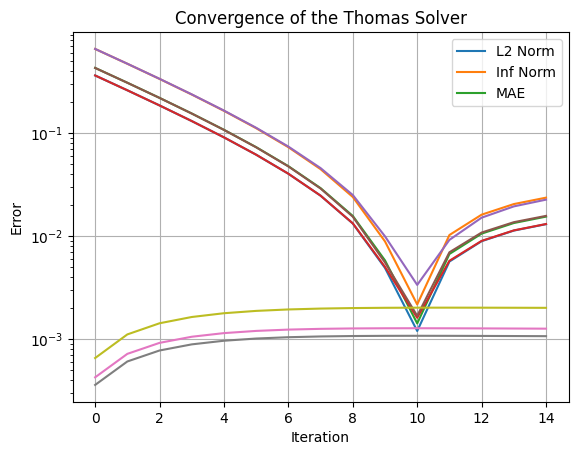

In [65]:
# plot convergence just for the thomas
print('Errors:', errors)    

plt.plot(errors)
plt.title('Convergence of the Thomas Solver')
plt.xlabel('Iteration')
plt.legend(['L2 Norm', 'Inf Norm', 'MAE'])
plt.ylabel('Error')
plt.yscale('log')
plt.grid()
plt.show()


## ADI Statevector w/ Preconditioning ::confirmed working

In [ ]:
def ADI_val_sv_prec(u, Lx,Ly, Ax, Ay, f_interior, method = 'q', max_iter = 4):
    """
        Validation of the ADI method
        Going to be using the statevector simulator for this
    """
    fun_start = time.time() 
    N = u.shape[0]
    
    x_vals = np.linspace(0, Lx, N+2)
    y_vals = np.linspace(0, Ly, N+2)
    X_full, Y_full = np.meshgrid(x_vals, y_vals, indexing='ij')
    
    # Necessary for error calculation
    errors = []
    pct_diff = []
    u_analytical_resampled = np.sin(np.pi * X_full) * np.sin(np.pi * Y_full) / (2 * np.pi**2 - k**2)
    u_hhl = u.copy()
    u_thomas = u.copy()
    iter = 0
    alpha = 0.1
    while iter < max_iter:
        print(f'Iteration: {iter}')
        start = time.time()
        # Now treat x as implicit and the y as explicit
        for j in range(N):
            # Extract the f for this row
            f_j = f_interior[j, :].copy()
            
            # Absorb the top row and bottom row into the vector
            topu_hhl = u_hhl[j + 1, :] if j + 1 < N else np.zeros(N)
            bottomu_hhl = u_hhl[j - 1, :] if j - 1 >= 0 else np.zeros(N)
            f_j_hhl = f_j - topu_hhl - bottomu_hhl
            
            topu_thomas = u_thomas[j + 1, :] if j + 1 < N else np.zeros(N)
            bottomu_thomas = u_thomas[j - 1, :] if j - 1 >= 0 else np.zeros(N)
            f_j_thomas = f_j - topu_thomas - bottomu_thomas
            

            # Solve using Thomas
            solution_thomas = solve_1DThomas(Ax, f_j_thomas)

            # Solve using HHL
            #solution_hhl = solve_1DHHL(Ax, f_j_hhl, NUM_QUBITS)
            solution_hhl = solve_1DHHL_prec(Ax, f_j_hhl, NUM_QUBITS, alpha, h, k)
            solution_hhl = statevector(solution_hhl, solution_hhl.state.num_qubits, f_j_hhl, 1000)
            solution_hhl = solution_hhl * np.linalg.norm(solution_thomas) / np.linalg.norm(solution_hhl)
            #normalize(solution_hhl, min(solution_thomas), max(solution_thomas))
            
            
            # Update the solutions
            u_hhl[j, :] = solution_hhl
            u_thomas[j, :] = solution_thomas
        
        print('Columns computed in:', time.time() - start)
        print('HHL Solution:\n', u_hhl)
        print('Thomas Solution:\n', u_thomas)
        print('Difference \n ', u_hhl - u_thomas)

        
        
        # Now treat y as implicit and the x as explicit
        start = time.time()
        for i in range(N):
            # Extract the f for this column
            f_i = f_interior[:, i].copy()
            
            # Absorb the left column and right column into the vector
            leftu_hhl = u_hhl[:, i - 1] if i - 1 >= 0 else np.zeros(N)
            rightu_hhl = u_hhl[:, i + 1] if i + 1 < N else np.zeros(N)
            f_i_hhl = f_i - leftu_hhl - rightu_hhl
            
            leftu_thomas = u_thomas[:, i - 1] if i - 1 >= 0 else np.zeros(N)
            rightu_thomas = u_thomas[:, i + 1] if i + 1 < N else np.zeros(N)
            f_i_thomas = f_i - leftu_thomas - rightu_thomas
            
            # Solve using Thomas
            solution_thomas = solve_1DThomas(Ay, f_i_thomas)

            # Solve using HHL
            #solution_hhl = solve_1DHHL(Ay, f_i_hhl, NUM_QUBITS)
            solution_hhl = solve_1DHHL_prec(Ay, f_i_hhl, NUM_QUBITS, alpha, h, k)
            solution_hhl = statevector(solution_hhl, solution_hhl.state.num_qubits, f_i_hhl, 10000)
            solution_hhl = solution_hhl * np.linalg.norm(solution_thomas) / np.linalg.norm(solution_hhl)

            #solution_hhl = normalize(solution_hhl, min(solution_thomas), max(solution_thomas))
        
            
            # Update the solutions
            u_hhl[:, i] = solution_hhl
            u_thomas[:, i] = solution_thomas
        
        print('Rows computed in:', time.time() - start)
        print('HHL Solution:\n', u_hhl)
        print('Thomas Solution:\n', u_thomas)
        print('Difference \n ', u_hhl - u_thomas)

        
        # Plot heatmaps for HHL and Thomas solutions
        fig, axes = plt.subplots(1, 2, figsize=(6, 4))
        sns.heatmap(u_hhl, ax=axes[0], cmap="hot", cbar=True)
        axes[0].set_title(f"HHL Solution (Iteration {iter+1})")
        sns.heatmap(u_thomas, ax=axes[1], cmap="hot", cbar=True)
        axes[1].set_title(f"Thomas Solution (Iteration {iter+1})")
        plt.tight_layout()
        plt.show()
        
        # Calculate error by padding current solution and comparing to analytical
        u_hhl_padded = np.pad(u_hhl, pad_width=1, mode='constant', constant_values=0)
        u_thomas_padded = np.pad(u_thomas, pad_width=1, mode='constant', constant_values=0)
        error_hhl = np.linalg.norm(u_hhl_padded - u_analytical_resampled)
        error_thomas = np.linalg.norm(u_thomas_padded - u_analytical_resampled)
        errors.append((error_hhl, error_thomas))

        # compute the percentdifference to the thomas
        percent_diff = np.abs(u_hhl - u_thomas) / np.abs(u_thomas)
        pct_diff.append(percent_diff)
        print('Percent Difference to Thomas: \n', percent_diff)
        
        print()
        print(f"Error after iteration {iter+1} (HHL): {error_hhl}")
        print(f"Error after iteration {iter+1} (Thomas): {error_thomas}")
        print()
        iter += 1
    print('ADI run time:', time.time() - fun_start)                
    return u_hhl, u_thomas, errors, pct_diff
        
u_init = np.zeros((N, N))
# Solve using the ADI now in quantum
u_hhl, u_thomas, errors, pct_diff = ADI_val_sv_prec(u_init ,Lx, Ly, Ax, Ay, f_interior, method='q')

## ADI qasm validation :: confirmed working

In [ ]:
def ADI_val_qasm(u, Lx,Ly, Ax, Ay, f_interior, method = 'q', max_iter = 4):
    """
        Validation of the ADI method
        Going to be using the statevector simulator for this
    """
    fun_start = time.time() 
    N = u.shape[0]
    
    x_vals = np.linspace(0, Lx, N+2)
    y_vals = np.linspace(0, Ly, N+2)
    X_full, Y_full = np.meshgrid(x_vals, y_vals, indexing='ij')
    
    # Solve using the ADI now in quantum
    backend = Aer.get_backend('qasm_simulator')
    backend_options = {
        'max_parallel_threads': 8,      # use up to 4 threads
        'max_parallel_experiments': 16,    # run up to 2 experiments in parallel
        'seed_simulator': 42,            # set a seed for reproducibility
        }
    
    
    # Necessary for error calculation
    errors = []
    pct_diff = []
    u_analytical_resampled = np.sin(np.pi * X_full) * np.sin(np.pi * Y_full) / (2 * np.pi**2 - k**2)
    u_hhl = u.copy()
    u_thomas = u.copy()
    iter = 0
    while iter < max_iter:
        print(f'Iteration: {iter}')
        start = time.time()
        # Now treat x as implicit and the y as explicit
        for j in range(N):
            # Extract the f for this row
            f_j = f_interior[j, :].copy()
            
            # Absorb the top row and bottom row into the vector
            topu_hhl = u_hhl[j + 1, :] if j + 1 < N else np.zeros(N)
            bottomu_hhl = u_hhl[j - 1, :] if j - 1 >= 0 else np.zeros(N)
            f_j_hhl = f_j - topu_hhl - bottomu_hhl
            
            topu_thomas = u_thomas[j + 1, :] if j + 1 < N else np.zeros(N)
            bottomu_thomas = u_thomas[j - 1, :] if j - 1 >= 0 else np.zeros(N)
            f_j_thomas = f_j - topu_thomas - bottomu_thomas
            

            # Solve using Thomas
            solution_thomas = solve_1DThomas(Ax, f_j_thomas)

            # Solve using HHL
            solution_hhl = solve_1DHHL(Ax, f_j_hhl, NUM_QUBITS)
            euclidian_norm = solution_hhl.euclidean_norm
            solution_hhl = qasm(solution_hhl, solution_hhl.state.num_qubits, f_j_hhl, backend, 1000, backend_options, visual=False)
            solution_hhl = np.sign(solution_thomas) * solution_hhl * euclidian_norm / np.linalg.norm(solution_hhl)
            
            
            # Update the solutions
            u_hhl[j, :] = solution_hhl
            u_thomas[j, :] = solution_thomas
        
        print('Columns computed in:', time.time() - start)
        print('HHL Solution:\n', u_hhl)
        print('Thomas Solution:\n', u_thomas)
        print('Difference \n ', u_hhl - u_thomas)

        
        
        # Now treat y as implicit and the x as explicit
        start = time.time()
        for i in range(N):
            # Extract the f for this column
            f_i = f_interior[:, i].copy()
            
            # Absorb the left column and right column into the vector
            leftu_hhl = u_hhl[:, i - 1] if i - 1 >= 0 else np.zeros(N)
            rightu_hhl = u_hhl[:, i + 1] if i + 1 < N else np.zeros(N)
            f_i_hhl = f_i - leftu_hhl - rightu_hhl
            
            leftu_thomas = u_thomas[:, i - 1] if i - 1 >= 0 else np.zeros(N)
            rightu_thomas = u_thomas[:, i + 1] if i + 1 < N else np.zeros(N)
            f_i_thomas = f_i - leftu_thomas - rightu_thomas
            
            # Solve using Thomas
            solution_thomas = solve_1DThomas(Ay, f_i_thomas)

            # Solve using HHL
            solution_hhl = solve_1DHHL(Ay, f_i_hhl, NUM_QUBITS)
            solution_hhl = qasm(solution_hhl, solution_hhl.state.num_qubits, f_i_hhl, backend, 1000, backend_options, visual=False)
            solution_hhl = np.sign(solution_thomas) * solution_hhl * np.linalg.norm(solution_thomas) / np.linalg.norm(solution_hhl)

            # Update the solutions
            u_hhl[:, i] = solution_hhl
            u_thomas[:, i] = solution_thomas
        
        print('Rows computed in:', time.time() - start)
        print('HHL Solution:\n', u_hhl)
        print('Thomas Solution:\n', u_thomas)
        print('Difference \n ', u_hhl - u_thomas)

        
        # Plot heatmaps for HHL and Thomas solutions
        fig, axes = plt.subplots(1, 2, figsize=(6, 4))
        sns.heatmap(u_hhl, ax=axes[0], cmap="hot", cbar=True)
        axes[0].set_title(f"HHL Solution (Iteration {iter+1})")
        sns.heatmap(u_thomas, ax=axes[1], cmap="hot", cbar=True)
        axes[1].set_title(f"Thomas Solution (Iteration {iter+1})")
        plt.tight_layout()
        plt.show()
        
        # Calculate error by padding current solution and comparing to analytical
        u_hhl_padded = np.pad(u_hhl, pad_width=1, mode='constant', constant_values=0)
        u_thomas_padded = np.pad(u_thomas, pad_width=1, mode='constant', constant_values=0)
        error_hhl = np.linalg.norm(u_hhl_padded - u_analytical_resampled)
        error_thomas = np.linalg.norm(u_thomas_padded - u_analytical_resampled)
        errors.append((error_hhl, error_thomas))

        # compute the percentdifference to the thomas
        percent_diff = np.abs(u_hhl - u_thomas) / np.abs(u_thomas)
        pct_diff.append(percent_diff)
        print('Percent Difference to Thomas: \n', percent_diff)
        
        print()
        print(f"Error after iteration {iter+1} (HHL): {error_hhl}")
        print(f"Error after iteration {iter+1} (Thomas): {error_thomas}")
        print()
        iter += 1
    print('ADI run time:', time.time() - fun_start)                
    return u_hhl, u_thomas, errors, pct_diff
        
u_init = np.zeros((N, N))
# Solve using the ADI now in quantum
u_hhl, u_thomas, errors, pct_diff = ADI_val_qasm(u_init, Lx,Ly, Ax, Ay, f_interior, method = 'q', max_iter = 4)


## Visualize solution

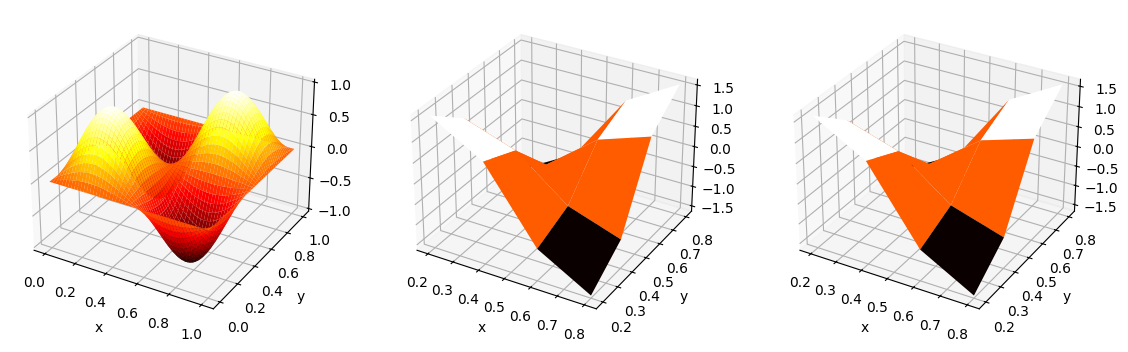

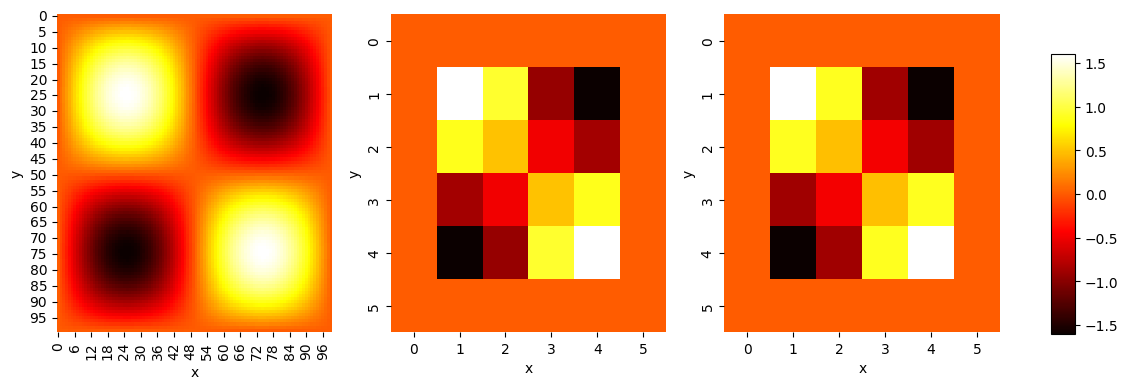

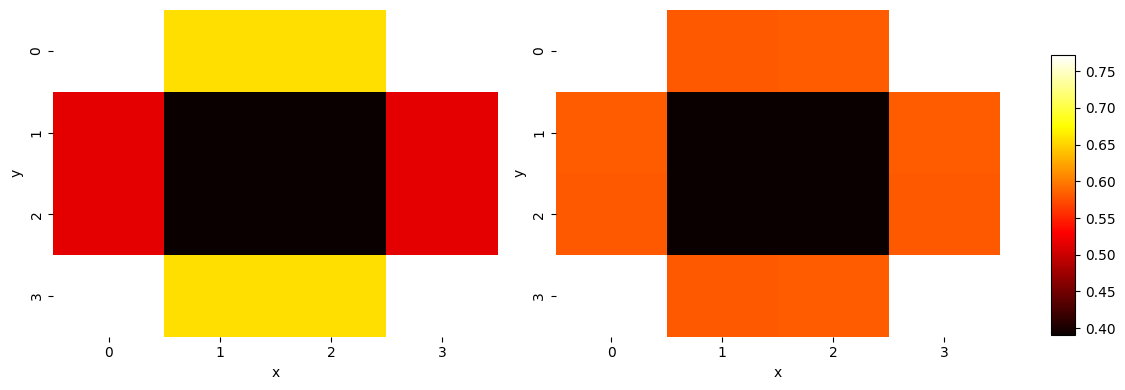

In [ ]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

from linear_solvers import hhl

lb, ub = -1.0, 1.0
####################################### Final solution #########################################################################
# Pad the computed solution with a boundary of zeros (Dirichlet condition)
u_tom_padded = np.pad(u_thomas, pad_width=1, mode='constant', constant_values=0)
#u_tom_padded = normalize(u_tom_padded, lb, ub)

#u_analytical = normalize(u_analytical, lb, ub)
#u_analytical_resampled = normalize(u_analytical_resampled, lb, ub)

u_hhl_padded = np.pad(u_hhl, pad_width=1, mode='constant', constant_values=0)

#u_hhl_padded = normalize(u_hhl_padded, lb, ub)

# error_hhl_grid = np.abs(u_hhl_padded - u_analytical_resampled)
# error_tom_grid = np.abs(u_tom_padded - u_analytical_resampled)

####################################### Final solution #########################################################################
# plot the iteration wise errors
# Plot HHL and Thomas error convergence side by side



# # subplots of the erros heatmap
# plt.figure(figsize=(12, 6))
# plt.subplot(1, 2, 1)
# plt.title('Error Heatmap (HHL)')
# sns.heatmap(error_hhl_grid, cmap='hot', cbar=True)
# plt.subplot(1, 2, 2)
# plt.title('Error Heatmap (Thomas)')
# sns.heatmap(error_tom_grid, cmap='hot', cbar=True)
# plt.tight_layout()
# plt.show()


# plot the 3D surface plots of the solutions side by side using the padded computed solution
fig = plt.figure(figsize=(14, 5))
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot_surface(X_high_res, Y_high_res, u_analytical, cmap='hot')
ax2 = fig.add_subplot(132, projection='3d')
ax2.plot_surface(x, y, u_hhl_padded, cmap='hot')
ax3 = fig.add_subplot(133, projection='3d')
ax3.plot_surface(x, y, u_tom_padded, cmap='hot')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
#ax1.set_title('Analytical')
#ax2.set_title('HHL')
#ax3.set_title('Thomas')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax3.set_xlabel('x')
ax3.set_ylabel('y')
#plt.tight_layout()
plt.savefig(f'figures/2D/2D-validation-sidebyside_k={k}_ek={ek}_eps={new_eps}.png', dpi=600)
plt.close()

# # Plot and save each padded surface individually
# fig = plt.figure(figsize=(6, 6))
# ax = fig.add_subplot(111, projection='3d')
# ax.plot_surface(X_high_res, Y_high_res, u_analytical, cmap='hot')
# ax.set_xlabel('x')
# ax.set_ylabel('y')
# ax.set_zlabel('u')
# plt.tight_layout()
# plt.savefig('figures/2D/2D-validation-analytical_solution.png')
# plt.close(fig)

# fig = plt.figure(figsize=(6, 6))
# ax = fig.add_subplot(111, projection='3d')
# ax.plot_surface(x, y, u_hhl_padded, cmap='hot')
# ax.set_xlabel('x')
# ax.set_ylabel('y')
# ax.set_zlabel('u')
# plt.tight_layout()
# plt.savefig('figures/2D/2D-validation-hhl_solution_padded.png')
# plt.close(fig)

# fig = plt.figure(figsize=(6, 6))
# ax = fig.add_subplot(111, projection='3d')
# ax.plot_surface(x, y, u_tom_padded, cmap='hot')
# ax.set_xlabel('x')
# ax.set_ylabel('y')
# ax.set_zlabel('u')
# plt.tight_layout()
# plt.savefig('figures/2D/2D-validation-numerical_solution_padded.png')
# plt.close(fig)

# plot the contour plot of the computed solution side by side using the padded computed solution
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
# Plot heatmaps with a single shared colorbar

# Create the heatmaps without colorbars
hm0 = sns.heatmap(u_analytical, cmap='hot', ax=axs[0], cbar=False)
#axs[0].set_title('Analytical')
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')

hm1 = sns.heatmap(u_hhl_padded, cmap='hot', ax=axs[1], cbar=False)
#axs[1].set_title('HHL')
axs[1].set_xlabel('x')
axs[1].set_ylabel('y')

hm2 = sns.heatmap(u_tom_padded, cmap='hot', ax=axs[2], cbar=False)
#axs[2].set_title('Thomas')
axs[2].set_xlabel('x')
axs[2].set_ylabel('y')

# Add a single colorbar to the right of all subplots

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])
vmin = min(np.min(u_analytical_resampled), np.min(u_hhl_padded), np.min(u_tom_padded))
vmax = max(np.max(u_analytical_resampled), np.max(u_hhl_padded), np.max(u_tom_padded))
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = plt.cm.ScalarMappable(cmap='hot', norm=norm)
sm.set_array([])
fig.colorbar(sm, cax=cbar_ax)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.savefig(f'figures/2D/2D-validation-contour-sidebyside_k={k}_ek={ek}_eps={new_eps}.png', dpi=300)
plt.show()

hhl_diff = np.abs(u_hhl - u_analytical_resampled)/np.abs(u_analytical_resampled)
# use L2 error
thomas_diff = np.abs(u_thomas - u_analytical_resampled)/np.abs(u_analytical_resampled)
# plot the error heat map
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
# Plot heatmaps with a single shared colorbar
# Create the heatmaps without colorbars
hm0 = sns.heatmap(hhl_diff, cmap='hot', ax=axs[0], cbar=False)
#axs[0].set_title('HHL Error')
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')
hm1 = sns.heatmap(thomas_diff, cmap='hot', ax=axs[1], cbar=False)
#axs[1].set_title('Thomas Error')
axs[1].set_xlabel('x')
axs[1].set_ylabel('y')
# Add a single colorbar to the right of all subplots
fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])
vmin = min(np.min(hhl_diff), np.min(thomas_diff))
vmax = max(np.max(hhl_diff), np.max(thomas_diff))
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = plt.cm.ScalarMappable(cmap='hot', norm=norm)
sm.set_array([])
fig.colorbar(sm, cax=cbar_ax)
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.savefig(f'figures/2D/2D-validation-error-sidebyside_k={k}_ek={ek}_eps={new_eps}.png', dpi=300)


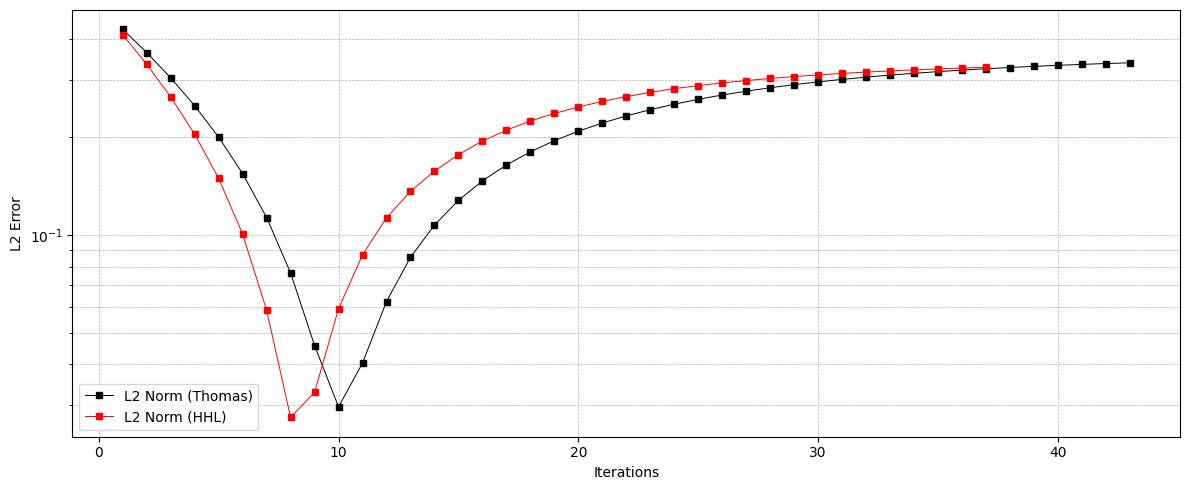

In [82]:
#plot_convergence(errors, NUM_QUBITS, k, new_eps)


if not errors:
    print("Error list is empty. Please provide data.")
    # exit() # or handle error appropriately
else:
    errors_array = np.array(errors)
    thomas_errors_array = np.array(thomas_errors)
    num_total_iterations = errors_array.shape[0]
    iterations_axis_hhl = np.arange(1, num_total_iterations + 1)
    iterations_axis_thomas = np.arange(1,thomas_errors_array.shape[0] + 1)

    # Extract specific error types for clarity (e.g., L2 norms)
    l2_thomas_vs_analytical = thomas_errors_array[:, 0]
    l2_hhl_vs_analytical = errors_array[:, 3]
    
    
plt.figure(figsize=(12, 5))

plt.plot(iterations_axis_thomas, l2_thomas_vs_analytical, 'ks-', label='L2 Norm (Thomas)', markersize=4, linewidth=0.7)
plt.plot(iterations_axis_hhl, l2_hhl_vs_analytical, 'rs-', label='L2 Norm (HHL)', markersize=4, linewidth=0.7)


plt.xlabel('Iterations')
plt.ylabel('L2 Error')
# Assuming N = 2**3 = 8 for NUM_QUBITS = 3
#plt.title(f'ADI Iteration Convergence (NUM_QUBITS = 3, N = 8)')
plt.yscale('log')
plt.legend(loc='best') # 'best' tries to find an optimal spot
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.tight_layout()
# You can save this figure if needed:
plt.savefig(f'figures/2D/iterations_k={k}_ek={ek}_nb={NUM_QUBITS}_eps={new_eps}.png', dpi=300)
plt.show()


# Solution Convergence Study :: Disretization

Investigate the impact of discretisation on the solution accuracy when using the ADI method

## Useful functions

In [95]:

def plot_3d_and_heatmaps(u_thomas, u_hhl, u_analytical, u_analytical_resampled, x, y, X_high_res, Y_high_res, k, ek, new_eps, nb):
    # Pad the computed solution with a boundary of zeros (Dirichlet condition)
    u_tom_padded = np.pad(u_thomas, pad_width=1, mode='constant', constant_values=0)
    u_hhl_padded = np.pad(u_hhl, pad_width=1, mode='constant', constant_values=0)

    # Plot the 3D surface plots of the solutions side by side using the padded computed solution
    fig = plt.figure(figsize=(12, 4))
    ax1 = fig.add_subplot(131, projection='3d')
    ax1.plot_surface(X_high_res, Y_high_res, u_analytical, cmap='hot')
    ax2 = fig.add_subplot(132, projection='3d')
    ax2.plot_surface(x, y, u_hhl_padded, cmap='hot')
    ax3 = fig.add_subplot(133, projection='3d')
    ax3.plot_surface(x, y, u_tom_padded, cmap='hot')
    ax1.set_xlabel('x')
    ax1.set_ylabel('y')
    ax2.set_xlabel('x')
    ax2.set_ylabel('y')
    ax3.set_xlabel('x')
    ax3.set_ylabel('y')
    plt.savefig(f'figures/2D/mesh/2D-mesh-sidebyside_np={nb}_k={k}_ek={ek}_eps={new_eps}.png', dpi=600)
    plt.show()

    fig, axs = plt.subplots(1, 3, figsize=(12, 4))
    # Plot heatmaps with a single shared colorbar
    hm0 = sns.heatmap(u_analytical, cmap='hot', ax=axs[0], cbar=False)
    axs[0].set_xlabel('x')
    axs[0].set_ylabel('y')

    hm1 = sns.heatmap(u_hhl_padded, cmap='hot', ax=axs[1], cbar=False)
    axs[1].set_xlabel('x')
    axs[1].set_ylabel('y')

    hm2 = sns.heatmap(u_tom_padded, cmap='hot', ax=axs[2], cbar=False)
    axs[2].set_xlabel('x')
    axs[2].set_ylabel('y')

    # Add a single colorbar to the right of all subplots
    fig.subplots_adjust(right=0.85)
    cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])
    vmin = min(np.min(u_analytical_resampled), np.min(u_hhl_padded), np.min(u_tom_padded))
    vmax = max(np.max(u_analytical_resampled), np.max(u_hhl_padded), np.max(u_tom_padded))
    norm = plt.Normalize(vmin=vmin, vmax=vmax)
    sm = plt.cm.ScalarMappable(cmap='hot', norm=norm)
    sm.set_array([])
    fig.colorbar(sm, cax=cbar_ax)

    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.savefig(f'figures/2D/Mesh/mesh-contour-sidebyside_nb={nb}_k={k}_ek={ek}_eps={new_eps}.png', dpi=300)
    plt.close()

    hhl_diff = np.abs(u_hhl - u_analytical_resampled) / np.abs(u_analytical_resampled)
    thomas_diff = np.abs(u_thomas - u_analytical_resampled) / np.abs(u_analytical_resampled)

    # Plot the error heat map
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    hm0 = sns.heatmap(hhl_diff, cmap='hot', ax=axs[0], cbar=False)
    axs[0].set_xlabel('x')
    axs[0].set_ylabel('y')
    hm1 = sns.heatmap(thomas_diff, cmap='hot', ax=axs[1], cbar=False)
    axs[1].set_xlabel('x')
    axs[1].set_ylabel('y')

    fig.subplots_adjust(right=0.85)
    cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])
    vmin = min(np.min(hhl_diff), np.min(thomas_diff))
    vmax = max(np.max(hhl_diff), np.max(thomas_diff))
    norm = plt.Normalize(vmin=vmin, vmax=vmax)
    sm = plt.cm.ScalarMappable(cmap='hot', norm=norm)
    sm.set_array([])
    fig.colorbar(sm, cax=cbar_ax)
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.savefig(f'figures/2D/Mesh/mesh-error-sidebyside_nb={nb}_k={k}_ek={ek}_eps={new_eps}.png', dpi=300)
    plt.close()

## Run Simulation

Running mesh convergence study for NUM_QUBITS = 1
For 1, Condition number of matrx:3.571428571428571
Reciprocal eigenvalue spectrum: 0.10285714285714284, with eps_tol: 0.001
 Number of ancilla qubits :  0  Number of flag qubits :  1  Number of clock qubits :  4 Number of b qubits :  1
 Number of ancilla qubits :  0  Number of flag qubits :  1  Number of clock qubits :  4 Number of b qubits :  1
 Number of ancilla qubits :  0  Number of flag qubits :  1  Number of clock qubits :  4 Number of b qubits :  1
 Number of ancilla qubits :  0  Number of flag qubits :  1  Number of clock qubits :  4 Number of b qubits :  1
Iteration 1:
  L2 norm error (Thomas): 0.500000
  L∞ norm error (Thomas): 0.750000
  Mean absolute error (Thomas): 0.750000

  L2 norm error (HHL): 0.425571
  L∞ norm error (HHL): 0.638357
  Mean absolute error (HHL): 0.638357

  Mean absolute error (Relative): 0.111643
  L2 norm error (Relative): 0.074429
  L∞ norm error (Relative): 0.111643
 Number of ancilla qubits :  0  N

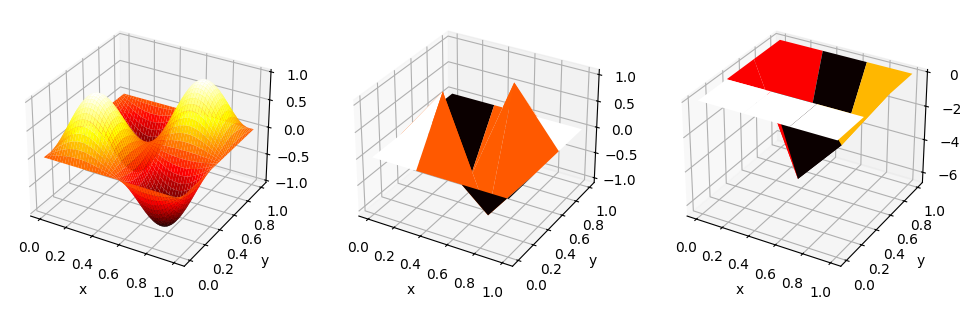


NUM_QUBITS = 1: L2 Error (Thomas) = 0.4999999999999999 Linf Error (Thomas) = 0.7500000000000001 MAE Error (Thomas) = 0.7499999999999998



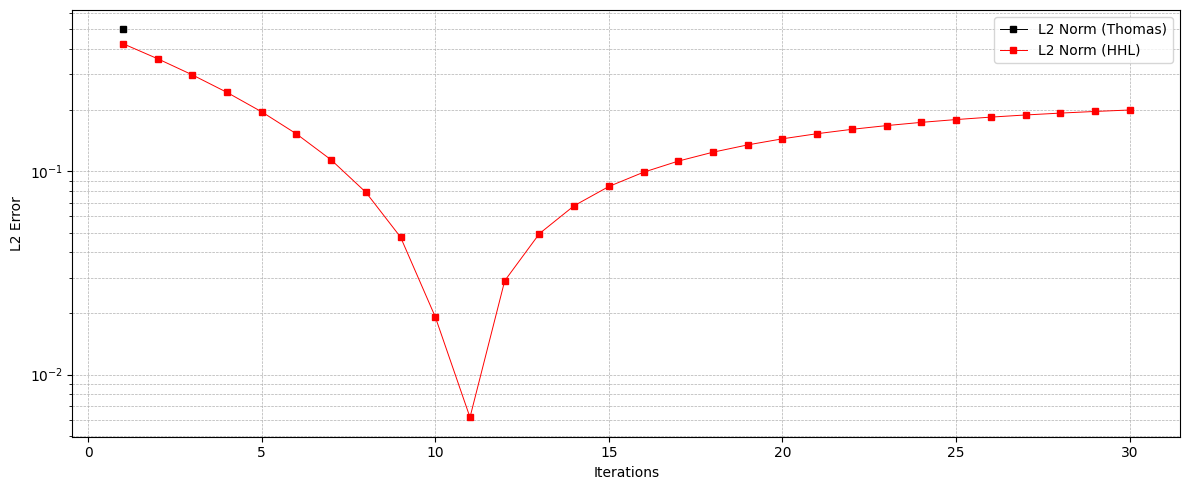

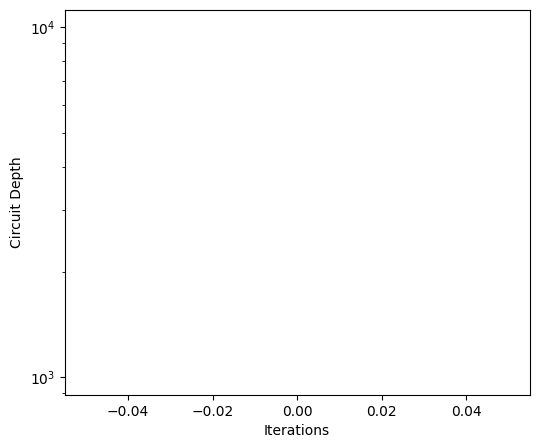

Running mesh convergence study for NUM_QUBITS = 2
For 2, Condition number of matrx:10.798834850424779
Reciprocal eigenvalue spectrum: 0.10990421085337504, with eps_tol: 0.001
 Number of ancilla qubits :  1  Number of flag qubits :  1  Number of clock qubits :  5 Number of b qubits :  2
 Number of ancilla qubits :  1  Number of flag qubits :  1  Number of clock qubits :  5 Number of b qubits :  2
 Number of ancilla qubits :  1  Number of flag qubits :  1  Number of clock qubits :  5 Number of b qubits :  2
 Number of ancilla qubits :  1  Number of flag qubits :  1  Number of clock qubits :  5 Number of b qubits :  2
 Number of ancilla qubits :  1  Number of flag qubits :  1  Number of clock qubits :  5 Number of b qubits :  2
 Number of ancilla qubits :  1  Number of flag qubits :  1  Number of clock qubits :  5 Number of b qubits :  2
 Number of ancilla qubits :  1  Number of flag qubits :  1  Number of clock qubits :  5 Number of b qubits :  2
 Number of ancilla qubits :  1  Number of

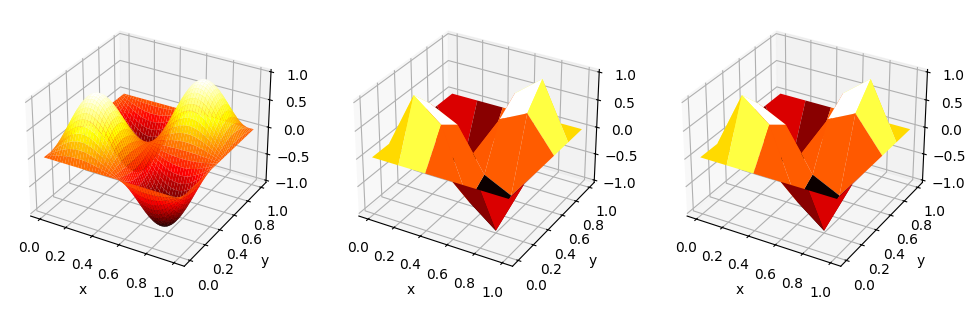


NUM_QUBITS = 2: L2 Error (Thomas) = 0.04301411960405234 Linf Error (Thomas) = 0.0778132733618081 MAE Error (Thomas) = 0.050929448609274536



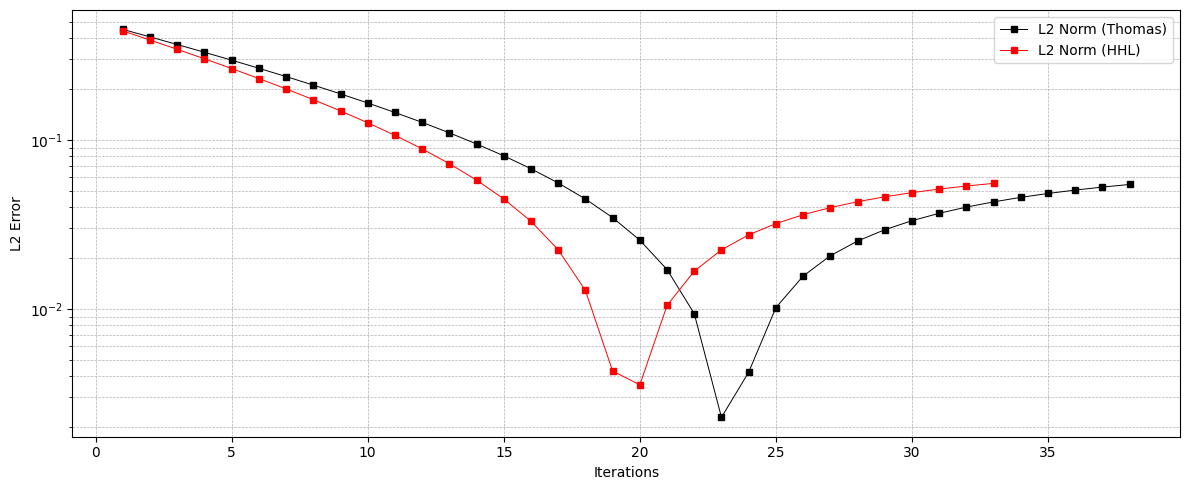

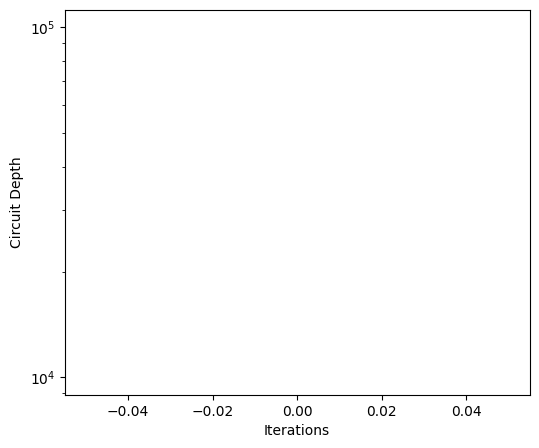

Running mesh convergence study for NUM_QUBITS = 3
For 3, Condition number of matrx:36.020910070087524
Reciprocal eigenvalue spectrum: 0.11183283836376005, with eps_tol: 0.001
 Number of ancilla qubits :  2  Number of flag qubits :  1  Number of clock qubits :  7 Number of b qubits :  3
 Number of ancilla qubits :  2  Number of flag qubits :  1  Number of clock qubits :  7 Number of b qubits :  3
 Number of ancilla qubits :  2  Number of flag qubits :  1  Number of clock qubits :  7 Number of b qubits :  3
 Number of ancilla qubits :  2  Number of flag qubits :  1  Number of clock qubits :  7 Number of b qubits :  3
 Number of ancilla qubits :  2  Number of flag qubits :  1  Number of clock qubits :  7 Number of b qubits :  3
 Number of ancilla qubits :  2  Number of flag qubits :  1  Number of clock qubits :  7 Number of b qubits :  3
 Number of ancilla qubits :  2  Number of flag qubits :  1  Number of clock qubits :  7 Number of b qubits :  3
 Number of ancilla qubits :  2  Number of

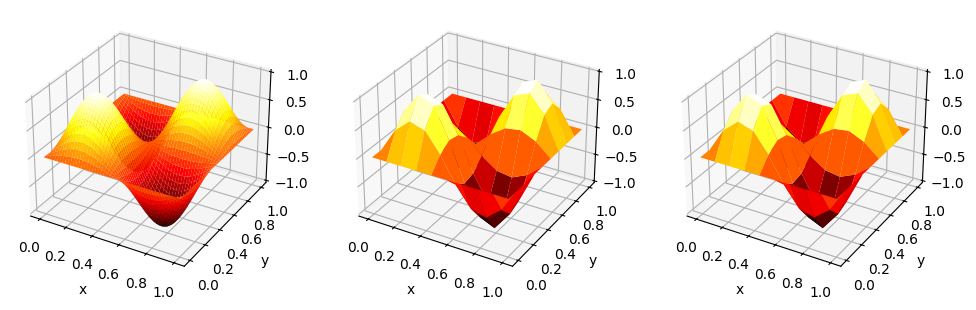


NUM_QUBITS = 3: L2 Error (Thomas) = 0.007760765384667727 Linf Error (Thomas) = 0.015053499348296029 MAE Error (Thomas) = 0.00780040288210954



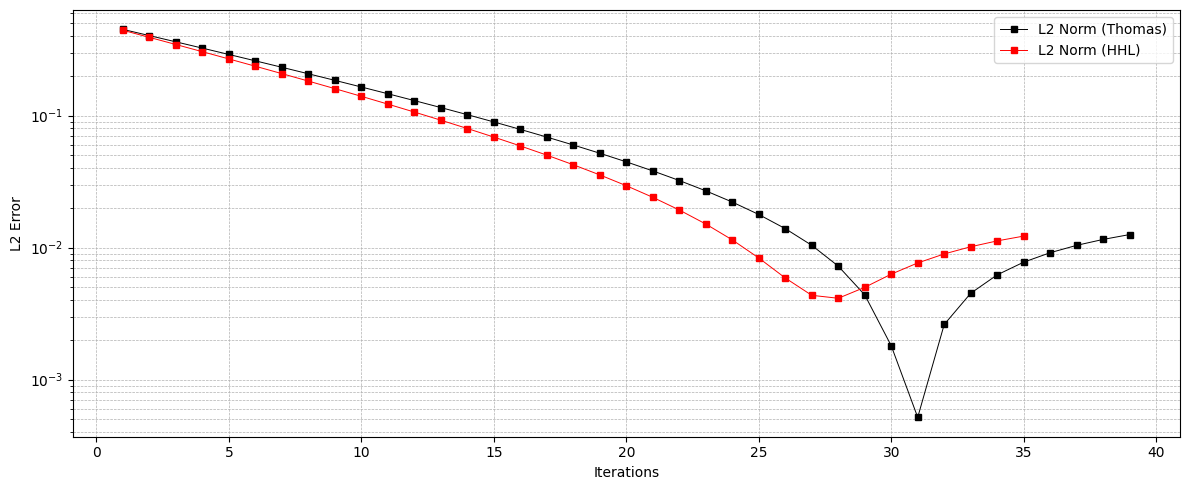

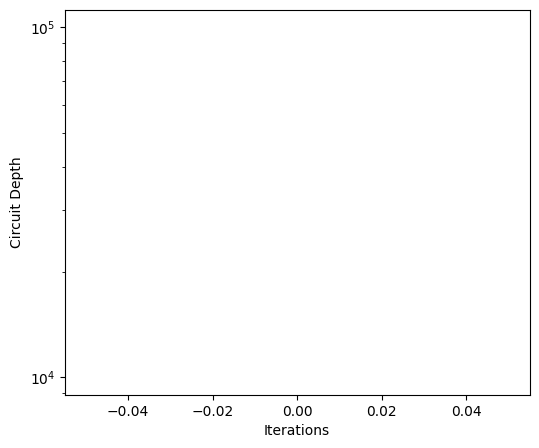

Running mesh convergence study for NUM_QUBITS = 4
For 4, Condition number of matrx:129.8000371133419
Reciprocal eigenvalue spectrum: 0.11247543788847375, with eps_tol: 0.001
 Number of ancilla qubits :  3  Number of flag qubits :  1  Number of clock qubits :  9 Number of b qubits :  4
 Number of ancilla qubits :  3  Number of flag qubits :  1  Number of clock qubits :  9 Number of b qubits :  4
 Number of ancilla qubits :  3  Number of flag qubits :  1  Number of clock qubits :  9 Number of b qubits :  4
 Number of ancilla qubits :  3  Number of flag qubits :  1  Number of clock qubits :  9 Number of b qubits :  4
 Number of ancilla qubits :  3  Number of flag qubits :  1  Number of clock qubits :  9 Number of b qubits :  4
 Number of ancilla qubits :  3  Number of flag qubits :  1  Number of clock qubits :  9 Number of b qubits :  4
 Number of ancilla qubits :  3  Number of flag qubits :  1  Number of clock qubits :  9 Number of b qubits :  4
 Number of ancilla qubits :  3  Number of 

In [ ]:
# List of qubit counts to test (increase as needed)
from more_itertools import last
from sympy import plot


qubit_list = [1, 2, 3, 4]#, 5]# 4, 5, 6, 7, 8]
Lx = 1.0       # Length of the x-dimension
Ly = 1.0       # Length of the y-dimension
k = 2.0              # Wave Number
max_iter = 1000
num_shots = 10000
eps_tol = 0.001
ek = 0.01

# Dictionary to store the L2 error for each mesh resolution
errors_vs_qubits = {}


for NUM_QUBITS in qubit_list:
    print(f"Running mesh convergence study for NUM_QUBITS = {NUM_QUBITS}")
    N = 2**NUM_QUBITS
    N_total = N + 2
    
    # Define grid spacing and grids
    dx = Lx / (N + 1)
    dy = Ly / (N + 1)
    h = dx  # h assumed same in both directions

    # Create full grid including boundaries
    x_vals = np.linspace(0, Lx, N_total)
    y_vals = np.linspace(0, Ly, N_total)
    x, y = np.meshgrid(x_vals, y_vals, indexing='ij')
    
    # Interior grid points
    interior_x = x_vals[1:-1]
    interior_y = y_vals[1:-1]
    interior_X, interior_Y = np.meshgrid(interior_x, interior_y, indexing='ij')
    
    # Forcing function (evaluated on the interior)
    f_interior  = (k**2*(1 - 2*np.pi**2)) * np.sin(k*np.pi*interior_X)*np.sin(k*np.pi*interior_Y)

    
    # High resolution grid for the analytical solution
    X_high_res, Y_high_res = np.meshgrid(np.linspace(0, Lx, 100), np.linspace(0, Ly, 100), indexing='ij')
    u_analytical = np.sin(k * np.pi * X_high_res) * np.sin(k * np.pi * Y_high_res)
    
    # Resampled analytical solution on the computed grid (for error estimation)
    u_analytical_resampled = np.sin(k * np.pi * interior_X) * np.sin(k * np.pi * interior_Y)
    
    # Operator matrices
    shift = 1.0 * np.cos(np.pi / N)  # Shift value for HHL
   
    # Initial guess
    u_init = np.zeros((N, N))
    

    # Solve using the ADI statevector validation method
    u_hhl, u_thomas, errors, new_eps, depth = ADI_val_sv(u_init, f_interior, u_analytical_resampled,shift, k , ek,  eps_tol=eps_tol, max_iter=max_iter, numShots=num_shots)
    u_thomas,thomas_errors = ADI_val_sv_2(u_init, f_interior, u_analytical_resampled,shift, k, ek, max_iter=max_iter, numShots=num_shots)

    plot_3d_and_heatmaps(u_thomas, u_hhl, u_analytical, u_analytical_resampled, x, y, X_high_res, Y_high_res, k, ek, new_eps, NUM_QUBITS)
  

    
    last_error = errors[-1]
    last_error_thomas = errors[-1]

    # Store the computed errors and percent difference in the dictionary
    errors_vs_qubits[NUM_QUBITS] = {
        "L2 Error (Thomas)": last_error_thomas[0],
        "Linf Error (Thomas)": last_error_thomas[1],
        "MAE Error (Thomas)": last_error_thomas[2],
        "L2 Error (HHL)": last_error[3],
        "Linf Error (HHL)": last_error[4],
        "MAE Error (HHL)": last_error[5],
        "MAE Relative Error": last_error[6],
        "L2 Relative Error": last_error[7],
        "Linf Relative Error": last_error[8],
        "new eps value": new_eps,
        "depths" : depth,
    }
    # errors_vs_qubits[NUM_QUBITS] = {
    #     "L2 Error (Thomas)": last_error[0],
    #     "Linf Error (Thomas)": last_error[1],
    #     "MAE Error (Thomas)": last_error[2],
    #     "minimum_error" : last_error[3],
    #     }
    
   
    
    print()
    #print(f"NUM_QUBITS = {NUM_QUBITS}: L2 Error (HHL) = {last_error[3]}, L2 Error (Thomas) = {last_error[0]}")
    print(f"NUM_QUBITS = {NUM_QUBITS}: L2 Error (Thomas) = {last_error[0]} Linf Error (Thomas) = {last_error[1]} MAE Error (Thomas) = {last_error[2]}")
    print()
    
    # # Plot the errors
    #plot_convergence(errors)

    # # plot the errors
    # fig = plt.figure(figsize=(12, 6))
    # plt.plot(errors)
    # plt.legend(['L2 Norm', 'Inf Norm', 'MAE'])
    # plt.title('Convergence of the Thomas Solver')
    # plt.yscale('log')
    # plt.grid()
    # plt.show()


        
    if not errors:
        print("Error list is empty. Please provide data.")
        # exit() # or handle error appropriately
    else:
        errors_array = np.array(errors)
        thomas_errors_array = np.array(thomas_errors)
        num_total_iterations = errors_array.shape[0]
        iterations_axis_hhl = np.arange(1, num_total_iterations + 1)
        iterations_axis_thomas = np.arange(1,thomas_errors_array.shape[0] + 1)

        # Extract specific error types for clarity (e.g., L2 norms)
        l2_thomas_vs_analytical = thomas_errors_array[:, 0]
        l2_hhl_vs_analytical = errors_array[:, 3]
        
        
    plt.figure(figsize=(12, 5))

    plt.plot(iterations_axis_thomas, l2_thomas_vs_analytical, 'ks-', label='L2 Norm (Thomas)', markersize=4, linewidth=0.7)
    plt.plot(iterations_axis_hhl, l2_hhl_vs_analytical, 'rs-', label='L2 Norm (HHL)', markersize=4, linewidth=0.7)
    plt.xlabel('Iterations')
    plt.ylabel('L2 Error')
    # Assuming N = 2**3 = 8 for NUM_QUBITS = 3
    #plt.title(f'ADI Iteration Convergence (NUM_QUBITS = 3, N = 8)')
    plt.yscale('log')
    plt.legend(loc='best') # 'best' tries to find an optimal spot
    plt.grid(True, which="both", ls="--", linewidth=0.5)
    plt.tight_layout()
    # You can save this figure if needed:
    plt.savefig(f'figures/2D/Mesh/iterations_k={k}_ek={ek}_nb={NUM_QUBITS}_eps={new_eps}.png', dpi=300)
    plt.show()


    #PLot the depths vs iterations
    plt.figure(figsize=(6, 5))
    plt.plot(depth)
    plt.xlabel('Iterations')
    plt.ylabel('Circuit Depth')
    plt.yscale('log')
    plt.savefig(f'figures/2D/Mesh/depths_k={k}_ek={ek}_nb={NUM_QUBITS}_eps={new_eps}.png', dpi=300)
    plt.show()
# create a final plot for the number of qubits and error




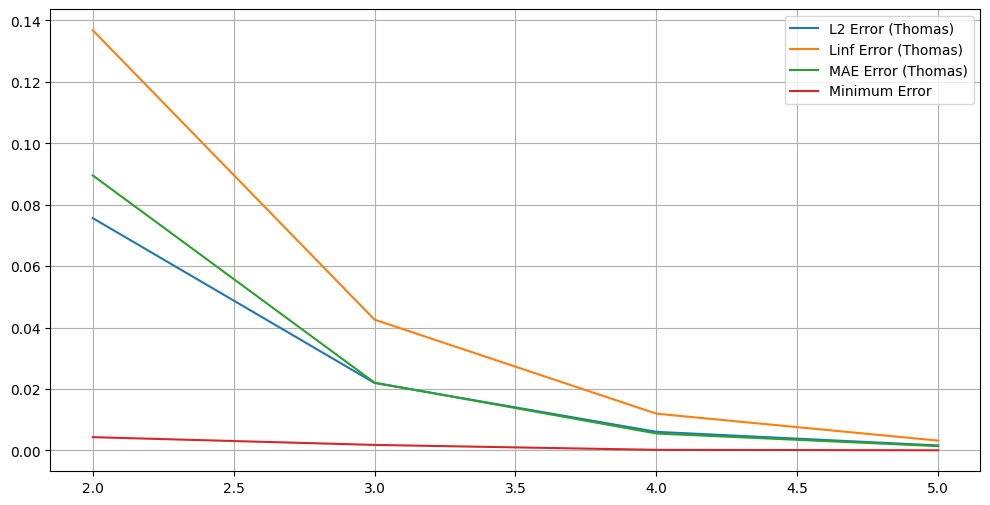

Minimum errors for each qubit count:
Qubits: 2, Ratio of Converged to Minimum Error: 17.643974195252518
Qubits: 3, Ratio of Converged to Minimum Error: 12.468967268358462
Qubits: 4, Ratio of Converged to Minimum Error: 39.429239319835226
Qubits: 5, Ratio of Converged to Minimum Error: 125.84903978509405


In [125]:
fig = plt.figure(figsize=(12, 6))
plt.plot(errors_vs_qubits.keys(), [errors_vs_qubits[q]["L2 Error (Thomas)"] for q in errors_vs_qubits.keys()], label='L2 Error (Thomas)')
plt.plot(errors_vs_qubits.keys(), [errors_vs_qubits[q]["Linf Error (Thomas)"] for q in errors_vs_qubits.keys()], label='Linf Error (Thomas)')
plt.plot(errors_vs_qubits.keys(), [errors_vs_qubits[q]["MAE Error (Thomas)"] for q in errors_vs_qubits.keys()], label='MAE Error (Thomas)')
plt.plot(errors_vs_qubits.keys(), [errors_vs_qubits[q]["minimum_error"] for q in errors_vs_qubits.keys()], label='Minimum Error')
#plt.yscale('log')
plt.grid()
plt.legend()
plt.show()

# Print the smallest error for each qubit count
print("Minimum errors for each qubit count:")
# ratio of converged to the minimum error
for qubit_count, error_data in errors_vs_qubits.items():
    #print(f"Qubits: {qubit_count}, Minimum Error: {error_data['minimum_error']}")
    print(f"Qubits: {qubit_count}, Ratio of Converged to Minimum Error: {error_data['L2 Error (Thomas)'] / error_data['minimum_error']}")

## Plot Results

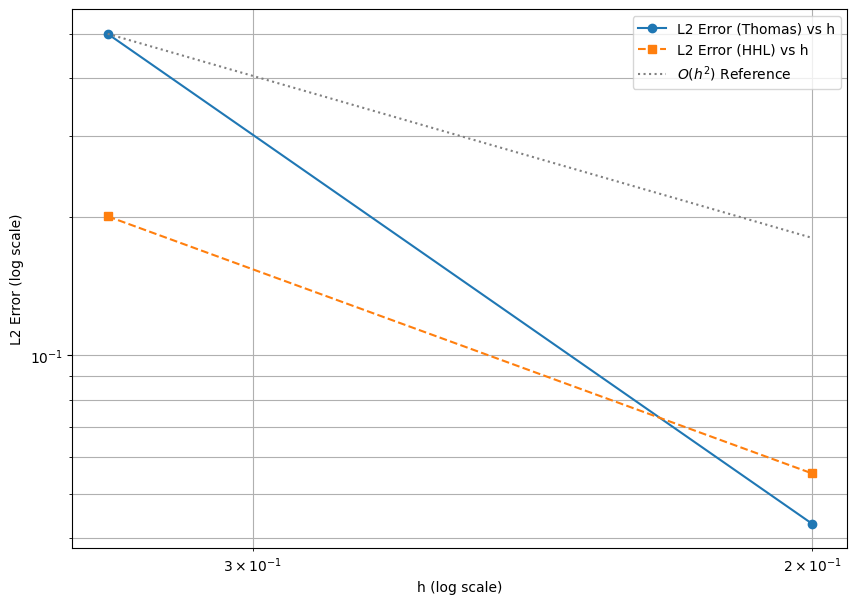


--- Observed Order of Accuracy (from Log-Log Plot Gradients) ---
Order of accuracy (Thomas solver, L2 error vs h): 4.80
Order of accuracy (HHL solver, L2 error vs h): 2.52
-------------------------------------------------------------------



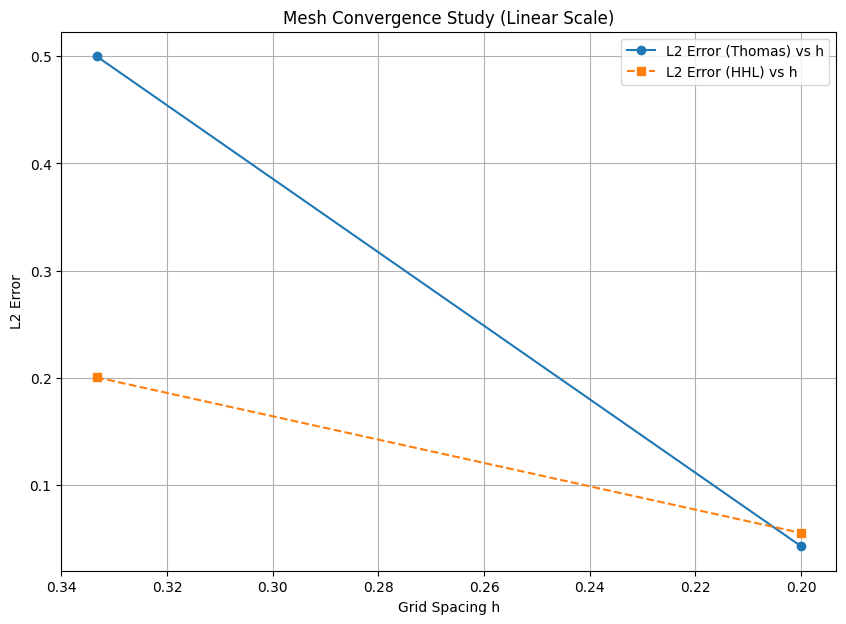

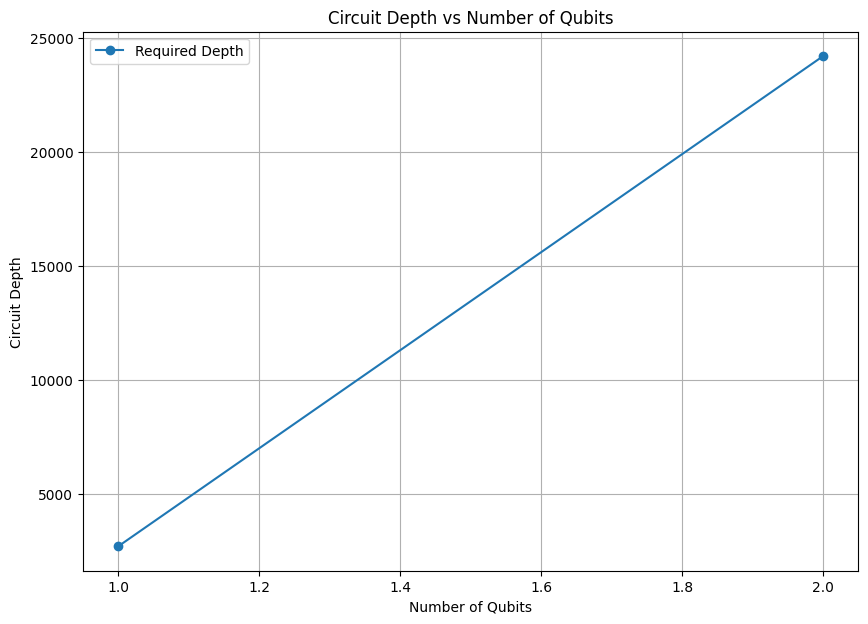

In [101]:
# --- Data Extraction for Plotting ---
h_values = []
l2_errors_thomas = []
l2_errors_hhl = []
required_depth = []
required_eps = []

# For gradient calculation on log-log scale
log_h_values = []
log_l2_errors_thomas = []
log_l2_errors_hhl = []

# Sort by NUM_QUBITS to ensure h_values are in a sensible order for plotting (decreasing h)
# and for consistent polyfit if using multiple points.
sorted_qubit_keys = sorted(errors_vs_qubits.keys())

for q_val in sorted_qubit_keys:
    n_val = 2**q_val
    current_h = Lx / (n_val + 1) # Make sure Lx is the one used in your study
    
    h_values.append(current_h)
    thomas_error = errors_vs_qubits[q_val]["L2 Error (Thomas)"]
    l2_errors_thomas.append(thomas_error)
    hhl_error = errors_vs_qubits[q_val]["L2 Error (HHL)"]
    l2_errors_hhl.append(hhl_error)
    required_depth.append(errors_vs_qubits[q_val]["depths"])
    required_eps.append(errors_vs_qubits[q_val]["new eps value"])

    # Prepare data for log-log gradient calculation
    # Ensure errors are positive before taking log, skip if not (e.g. if error is zero)
    if current_h > 0: # h should always be positive
        log_h_values.append(np.log(current_h))
        if thomas_error > 0:
            log_l2_errors_thomas.append(np.log(thomas_error))
        else:
            # Handle case where error might be zero or invalid for log
            log_l2_errors_thomas.append(np.nan) # Or skip this point

        if hhl_error > 0:
            log_l2_errors_hhl.append(np.log(hhl_error))
        else:
            log_l2_errors_hhl.append(np.nan) # Or skip this point

# Convert lists to numpy arrays for easier handling
h_values = np.array(h_values)
l2_errors_thomas = np.array(l2_errors_thomas)
l2_errors_hhl = np.array(l2_errors_hhl)

log_h_values = np.array(log_h_values)
log_l2_errors_thomas = np.array(log_l2_errors_thomas)
log_l2_errors_hhl = np.array(log_l2_errors_hhl)

# --- 1. Log-Log Convergence Plot ---
plt.figure(figsize=(10, 7))
plt.loglog(h_values, l2_errors_thomas, marker='o', linestyle='-', label='L2 Error (Thomas) vs h')
plt.loglog(h_values, l2_errors_hhl, marker='s', linestyle='--', label='L2 Error (HHL) vs h')

# Optional: Plot reference lines for expected order of accuracy (e.g., O(h^2))
if len(h_values) > 1 and l2_errors_thomas[0] > 0 : # Check if there's a valid starting point
    # Normalize reference line to start at the first data point
    h_squared_ref = [l2_errors_thomas[0] * (h / h_values[0])**2 for h in h_values]
    plt.loglog(h_values, h_squared_ref, linestyle=':', color='gray', label=r'$O(h^2)$ Reference')

plt.xlabel('h (log scale)')
plt.ylabel('L2 Error (log scale)')
#plt.title('Mesh Convergence Study (Log-Log Scale)')
plt.legend()
plt.grid(True, which="both", ls="-")
plt.gca().invert_xaxis() # Typically h decreases from left to right
plt.savefig('figures/2D/Mesh/mesh_convergence.png')
plt.show()

# --- 2. Calculate and Output Gradients (Order of Accuracy) ---
print("\n--- Observed Order of Accuracy (from Log-Log Plot Gradients) ---")
# Filter out NaN values that might have occurred if errors were not positive
valid_indices_thomas = ~np.isnan(log_h_values) & ~np.isnan(log_l2_errors_thomas)
valid_indices_hhl = ~np.isnan(log_h_values) & ~np.isnan(log_l2_errors_hhl)

if np.sum(valid_indices_thomas) >= 2:
    coeffs_thomas = np.polyfit(log_h_values[valid_indices_thomas], log_l2_errors_thomas[valid_indices_thomas], 1)
    gradient_thomas = coeffs_thomas[0]
    print(f"Order of accuracy (Thomas solver, L2 error vs h): {gradient_thomas:.2f}")
else:
    print("Not enough valid data points (need at least 2) to calculate Thomas solver convergence order.")

if np.sum(valid_indices_hhl) >= 2:
    coeffs_hhl = np.polyfit(log_h_values[valid_indices_hhl], log_l2_errors_hhl[valid_indices_hhl], 1)
    gradient_hhl = coeffs_hhl[0]
    print(f"Order of accuracy (HHL solver, L2 error vs h): {gradient_hhl:.2f}")
else:
    print("Not enough valid data points (need at least 2) to calculate HHL solver convergence order.")
print("-------------------------------------------------------------------\n")

# --- 3. Linear Scale Convergence Plot ---
plt.figure(figsize=(10, 7))
plt.plot(h_values, l2_errors_thomas, marker='o', linestyle='-', label='L2 Error (Thomas) vs h')
plt.plot(h_values, l2_errors_hhl, marker='s', linestyle='--', label='L2 Error (HHL) vs h')
plt.xlabel('Grid Spacing h')
plt.ylabel('L2 Error')
plt.title('Mesh Convergence Study (Linear Scale)')
plt.legend()
plt.grid(True, which="major", ls="-") # "both" is less critical for linear, "major" is fine
plt.gca().invert_xaxis() # Keep consistent with h decreasing, showing refinement
plt.savefig('figures/2D/convergence_linear.png')
plt.show()

# Generate a plot for the iterations and required depth
plt.figure(figsize=(10, 7))
plt.plot(errors_vs_qubits.keys(), required_depth, marker='o', linestyle='-', label='Required Depth')
plt.xlabel('Number of Qubits')
plt.ylabel('Circuit Depth')
plt.title('Circuit Depth vs Number of Qubits')
plt.legend()
plt.grid(True, which="major", ls="-")
#plt.savefig('figures/2D/Mesh/depth_vs_qubits.png')

# Solution ADI Iteration Convergence study
How does the number of steps influence the solution accuracy?

## Run Simulation

In [177]:
# Define the range of ADI iterations to test
max_iter_values = 1000
NUM_QUBITS = 3  # Number of qubits used to represent the solution

errors_hhl = []
errors_thomas = []

print(f"Running ADI convergence study for NUM_QUBITS = {NUM_QUBITS}")
N = 2**NUM_QUBITS
N_total = N + 2
Lx, Ly = 1.0, 1.0  # Length of the x and y dimensions
k  = 2.0  # Wave Number
num_shots = 10000  # Number of shots for HHL simulation

# Define grid spacing and grids
dx = Lx / (N + 1)
dy = Ly / (N + 1)
h = dx  # h assumed same in both directions

# Create full grid including boundaries
x_vals = np.linspace(0, Lx, N_total)
y_vals = np.linspace(0, Ly, N_total)
x, y = np.meshgrid(x_vals, y_vals, indexing='ij')

# Interior grid points
interior_x = x_vals[1:-1]
interior_y = y_vals[1:-1]
interior_X, interior_Y = np.meshgrid(interior_x, interior_y, indexing='ij')

# Forcing function (evaluated on the interior)
f_interior  = (k**2*(1 - 2*np.pi**2)) * np.sin(k*np.pi*interior_X)*np.sin(k*np.pi*interior_Y)


# High resolution grid for the analytical solution
X_high_res, Y_high_res = np.meshgrid(np.linspace(0, Lx, 100), np.linspace(0, Ly, 100), indexing='ij')
u_analytical = np.sin(k * np.pi * X_high_res) * np.sin(k * np.pi * Y_high_res)

# Resampled analytical solution on the computed grid (for error estimation)
u_analytical_resampled = np.sin(k * np.pi * interior_X) * np.sin(k * np.pi * interior_Y)

# Initial guess
u_init = np.zeros((N, N))

shift = 1.0 * np.cos(np.pi / N)  #np.sqrt((2 * (np.sin(np.pi/(2*N)))**2 + k/2.0) * (2 * (np.cos(np.pi/(2*N)))**2 + k/2.0))
print('Shift:', shift)
# Solve using the ADI statevector validation method
ek = 0.001
eps_tol = 0.001
max_iter_values = 1000
u_hhl, u_thomas, errors, cv_iter = ADI_val_sv(u_init, f_interior, u_analytical_resampled,shift, ek,eps_tol=eps_tol, max_iter=max_iter_values, numShots=num_shots)
u_thomas,thomas_errors = ADI_val_sv_2(u_init, f_interior, u_analytical_resampled,shift, ek, max_iter=max_iter_values, numShots=num_shots)

Running ADI convergence study for NUM_QUBITS = 3
Shift: 0.9238795325112867
 Number of ancilla qubits :  2  Number of flag qubits :  1  Number of clock qubits :  7 Number of b qubits :  3
 Number of ancilla qubits :  2  Number of flag qubits :  1  Number of clock qubits :  7 Number of b qubits :  3
 Number of ancilla qubits :  2  Number of flag qubits :  1  Number of clock qubits :  7 Number of b qubits :  3
 Number of ancilla qubits :  2  Number of flag qubits :  1  Number of clock qubits :  7 Number of b qubits :  3
 Number of ancilla qubits :  2  Number of flag qubits :  1  Number of clock qubits :  7 Number of b qubits :  3
 Number of ancilla qubits :  2  Number of flag qubits :  1  Number of clock qubits :  7 Number of b qubits :  3
 Number of ancilla qubits :  2  Number of flag qubits :  1  Number of clock qubits :  7 Number of b qubits :  3
 Number of ancilla qubits :  2  Number of flag qubits :  1  Number of clock qubits :  7 Number of b qubits :  3
 Number of ancilla qubits :  

**Iteration 1: 
 L2 error (Thomas): 0.448932**
**Iteration 2: 
 L2 error (Thomas): 0.402860**
**Iteration 3: 
 L2 error (Thomas): 0.361296**
**Iteration 4: 
 L2 error (Thomas): 0.323799**
**Iteration 5: 
 L2 error (Thomas): 0.289970**
**Iteration 6: 
 L2 error (Thomas): 0.259450**
**Iteration 7: 
 L2 error (Thomas): 0.231917**
**Iteration 8: 
 L2 error (Thomas): 0.207077**
**Iteration 9: 
 L2 error (Thomas): 0.184668**
**Iteration 10: 
 L2 error (Thomas): 0.164451**
**Iteration 11: 
 L2 error (Thomas): 0.146212**
**Iteration 12: 
 L2 error (Thomas): 0.129757**
**Iteration 13: 
 L2 error (Thomas): 0.114913**
**Iteration 14: 
 L2 error (Thomas): 0.101520**
**Iteration 15: 
 L2 error (Thomas): 0.089438**
**Iteration 16: 
 L2 error (Thomas): 0.078538**
**Iteration 17: 
 L2 error (Thomas): 0.068705**
**Iteration 18: 
 L2 error (Thomas): 0.059833**
**Iteration 19: 
 L2 error (Thomas): 0.051830**
**Iteration 20: 
 L2 error (Thomas): 0.044609**
**Iteration 21: 
 L2 error (Thomas): 0.038095**
*

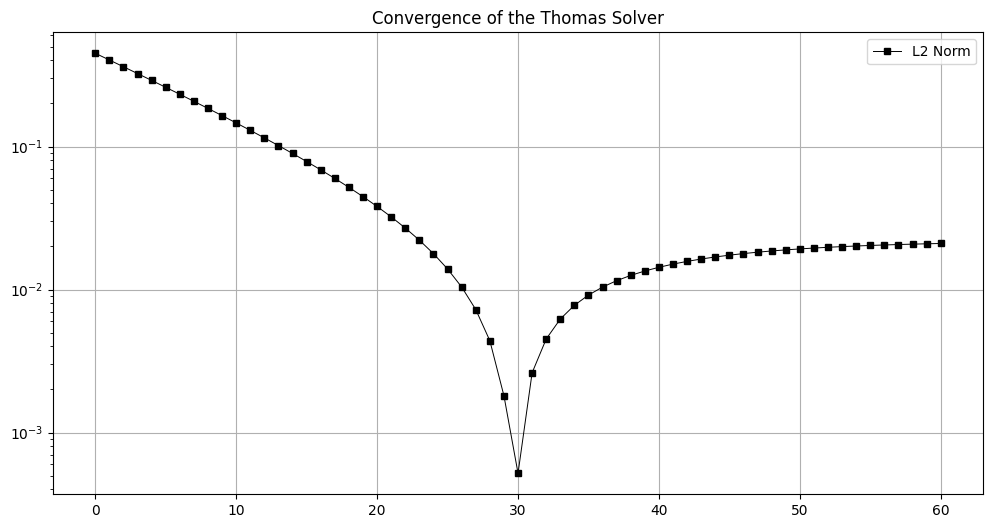

In [176]:
# Using only the errors in thomas
u_thomas,thomas_errors = ADI_val_sv_2(u_init, f_interior, u_analytical_resampled,shift, ek, max_iter=max_iter_values, numShots=num_shots)
thomas_errors_array = np.array(thomas_errors)
l2_thomas_vs_analytical = thomas_errors_array[:, 0]

fig = plt.figure(figsize=(12, 6))
plt.plot(l2_thomas_vs_analytical, 'ks-', label='L2 Norm (Thomas)', markersize=4, linewidth=0.7)
plt.legend(['L2 Norm', 'Inf Norm', 'MAE'])
plt.title('Convergence of the Thomas Solver')
plt.yscale('log')
plt.grid()
#plt.savefig('figures/2D/2D-convergence-thomas.png')
plt.show()

## Plot Results

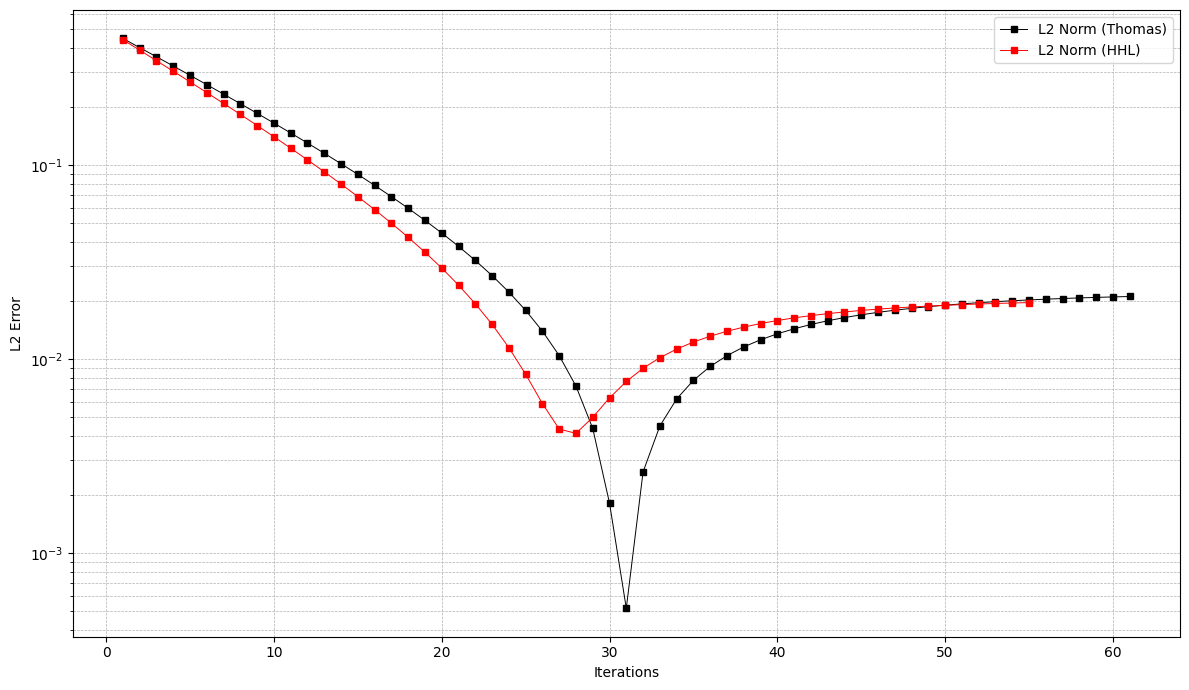


--- Convergence Rate Analysis (Mean Gradient of Log-Error) ---
Mean gradient of log(L2 Error Thomas): -0.0511
Mean gradient of log(L2 Error HHL): -0.0578
------------------------------------------------------------------



In [178]:
import numpy as np
import matplotlib.pyplot as plt

if not errors:
    print("Error list is empty. Please provide data.")
    # exit() # or handle error appropriately
else:
    errors_array = np.array(errors)
    thomas_errors_array = np.array(thomas_errors)
    num_total_iterations = errors_array.shape[0]
    iterations_axis_hhl = np.arange(1, num_total_iterations + 1)
    iterations_axis_thomas = np.arange(1,thomas_errors_array.shape[0] + 1)

    # Extract specific error types for clarity (e.g., L2 norms)
    l2_thomas_vs_analytical = thomas_errors_array[:, 0]
    l2_hhl_vs_analytical = errors_array[:, 3]
    
    
plt.figure(figsize=(12, 7))

plt.plot(iterations_axis_thomas, l2_thomas_vs_analytical, 'ks-', label='L2 Norm (Thomas)', markersize=4, linewidth=0.7)
plt.plot(iterations_axis_hhl, l2_hhl_vs_analytical, 'rs-', label='L2 Norm (HHL)', markersize=4, linewidth=0.7)


plt.xlabel('Iterations')
plt.ylabel('L2 Error')
# Assuming N = 2**3 = 8 for NUM_QUBITS = 3
#plt.title(f'ADI Iteration Convergence (NUM_QUBITS = 3, N = 8)')
plt.yscale('log')
plt.legend(loc='best') # 'best' tries to find an optimal spot
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.tight_layout()
# You can save this figure if needed:
plt.savefig(f'figures/2D/eps_iterations_ek={ek}_nb={NUM_QUBITS}_eps={eps_tol}.png', dpi=300)
plt.show()

print("\n--- Convergence Rate Analysis (Mean Gradient of Log-Error) ---")

def calculate_and_print_mean_gradient(error_series, label):
    # Ensure errors are positive before taking log
    positive_errors = error_series[error_series > 0]
    if len(positive_errors) < 2: # np.gradient needs at least 2 points for meaningful output
        print(f"Not enough positive data points for '{label}' to calculate gradient.")
        return None
    
    log_errors = np.log(positive_errors)
    gradients = np.gradient(log_errors) # Gradient w.r.t. index (iteration step = 1)
    mean_gradient = np.mean(gradients)
    print(f"Mean gradient of log({label}): {mean_gradient:.4f}")
    return mean_gradient

grad_T = calculate_and_print_mean_gradient(l2_thomas_vs_analytical, "L2 Error Thomas")
grad_H = calculate_and_print_mean_gradient(l2_hhl_vs_analytical, "L2 Error HHL")
print("------------------------------------------------------------------\n")

# Solution ADI Shift Parameter 
Investigate the impact of the shift parameter on accuracy,
Results: There is very little impact of this parameter on the solution accuracy.

## Run Simulation

Running shift study for shift = 0.1
**Iteration 1: 
 L2 error (Thomas): 0.492968**
**Iteration 2: 
 L2 error (Thomas): 0.486022**
**Iteration 3: 
 L2 error (Thomas): 0.479161**
**Iteration 4: 
 L2 error (Thomas): 0.472384**
**Iteration 5: 
 L2 error (Thomas): 0.465689**
**Iteration 6: 
 L2 error (Thomas): 0.459077**
**Iteration 7: 
 L2 error (Thomas): 0.452545**
**Iteration 8: 
 L2 error (Thomas): 0.446092**
**Iteration 9: 
 L2 error (Thomas): 0.439719**
**Iteration 10: 
 L2 error (Thomas): 0.433423**
**Iteration 11: 
 L2 error (Thomas): 0.427205**
**Iteration 12: 
 L2 error (Thomas): 0.421062**
**Iteration 13: 
 L2 error (Thomas): 0.414994**
**Iteration 14: 
 L2 error (Thomas): 0.409001**
**Iteration 15: 
 L2 error (Thomas): 0.403081**
**Iteration 16: 
 L2 error (Thomas): 0.397232**
**Iteration 17: 
 L2 error (Thomas): 0.391456**
**Iteration 18: 
 L2 error (Thomas): 0.385750**
**Iteration 19: 
 L2 error (Thomas): 0.380113**
**Iteration 20: 
 L2 error (Thomas): 0.374546**
**Iteration 2

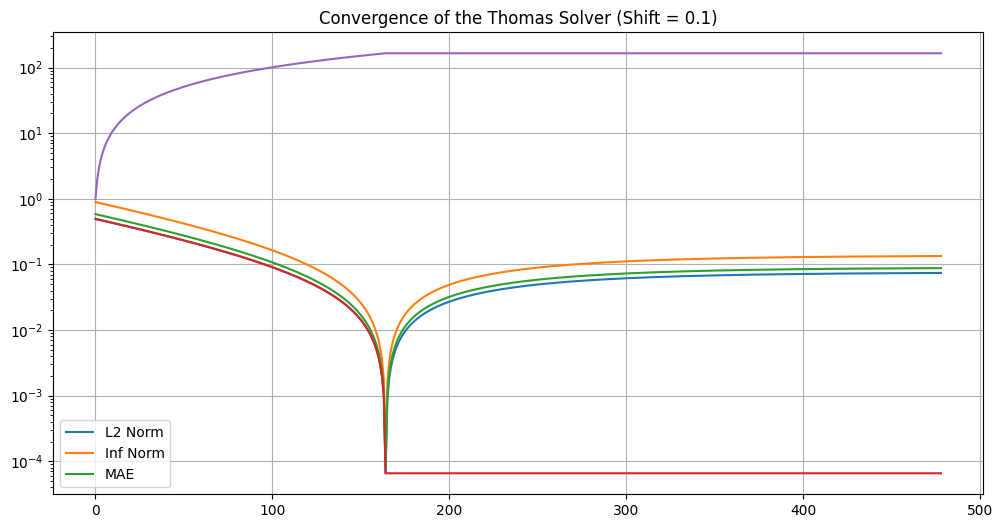

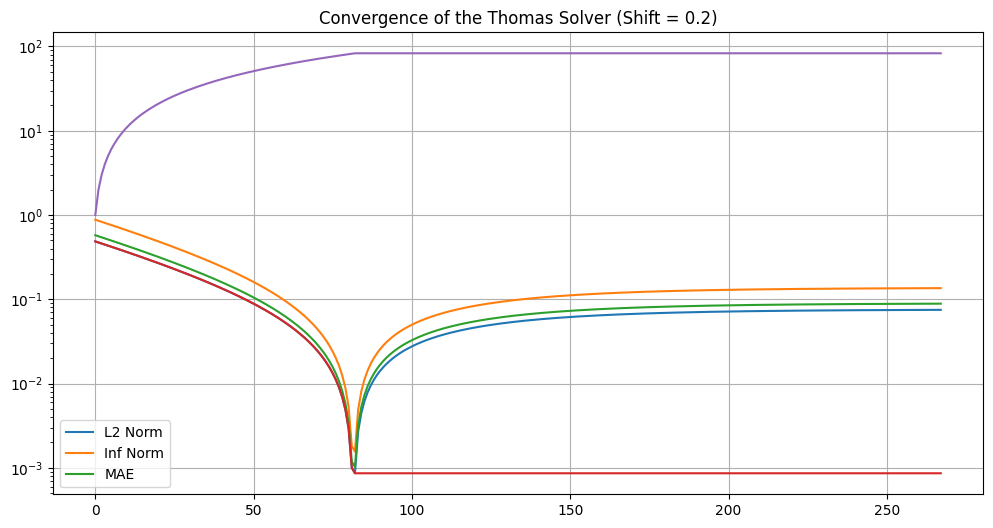

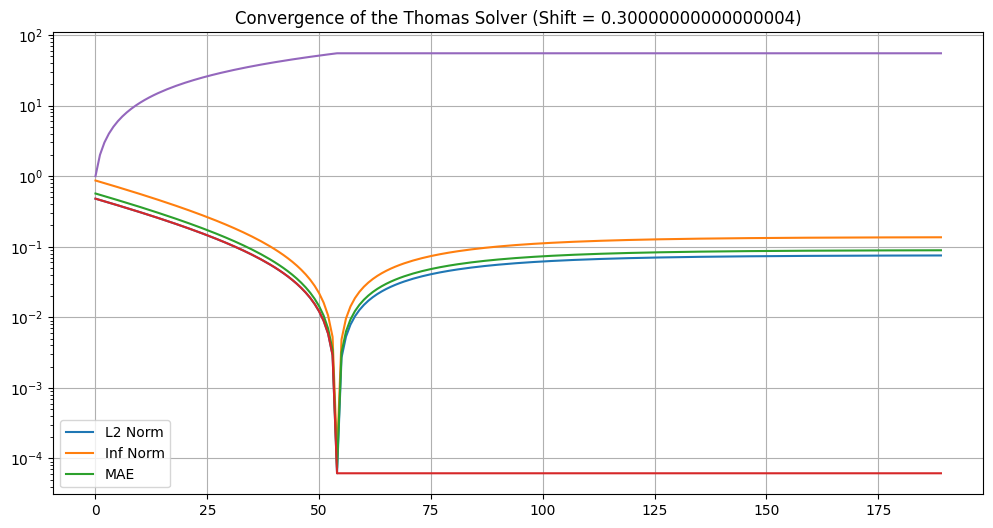

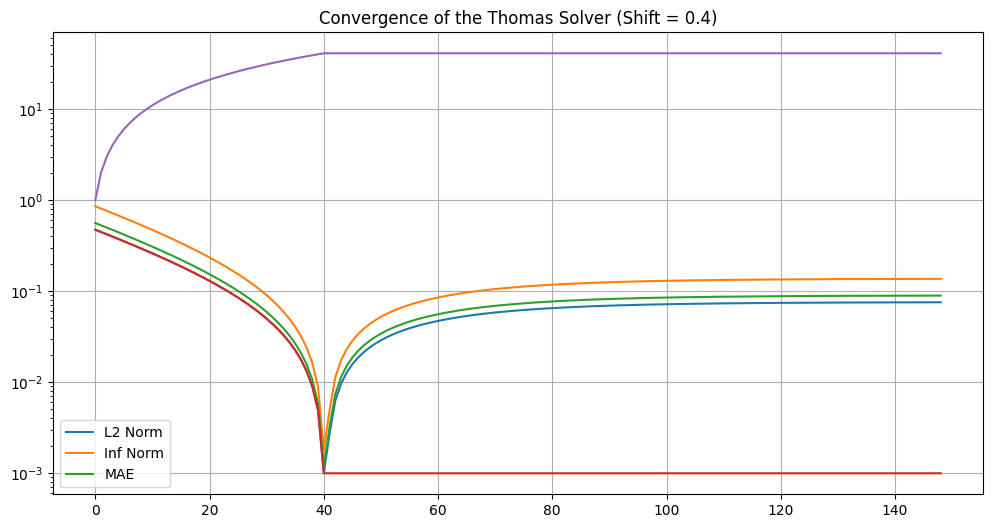

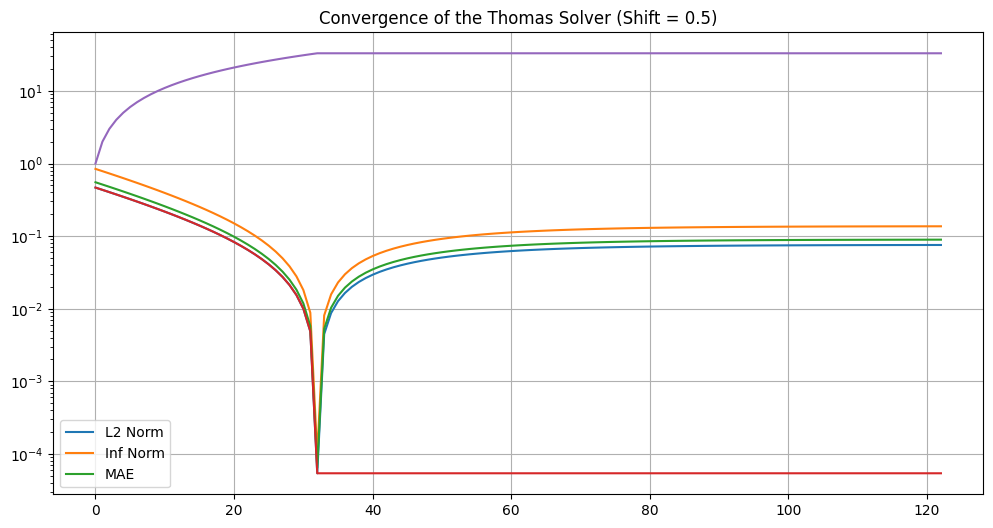

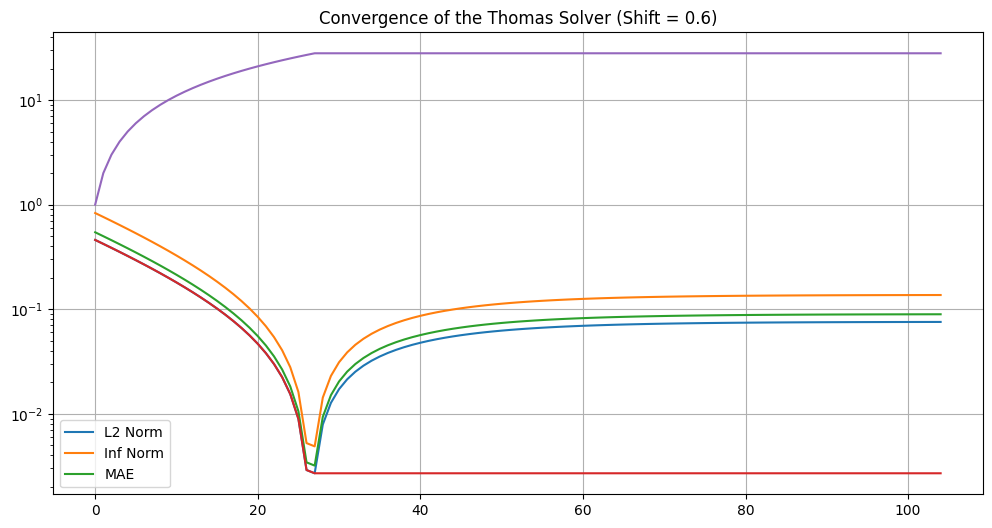

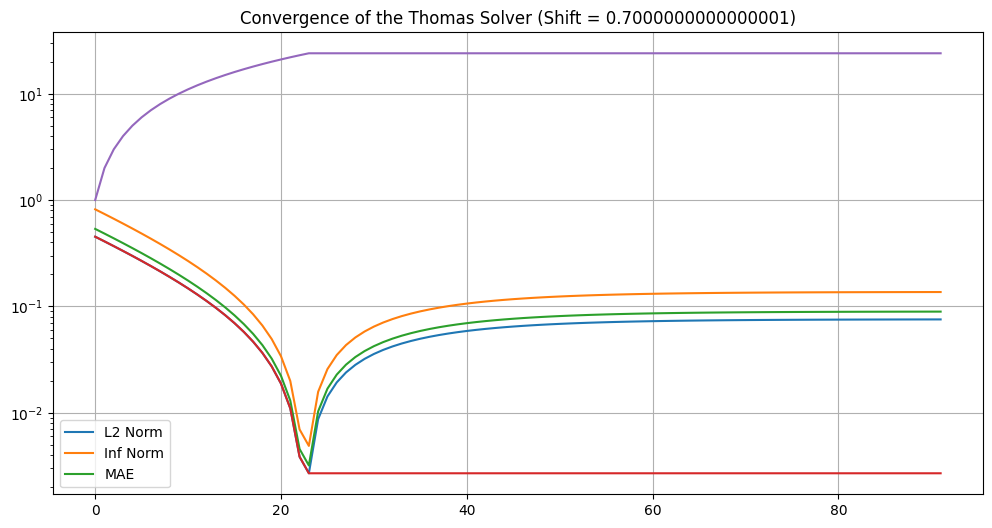

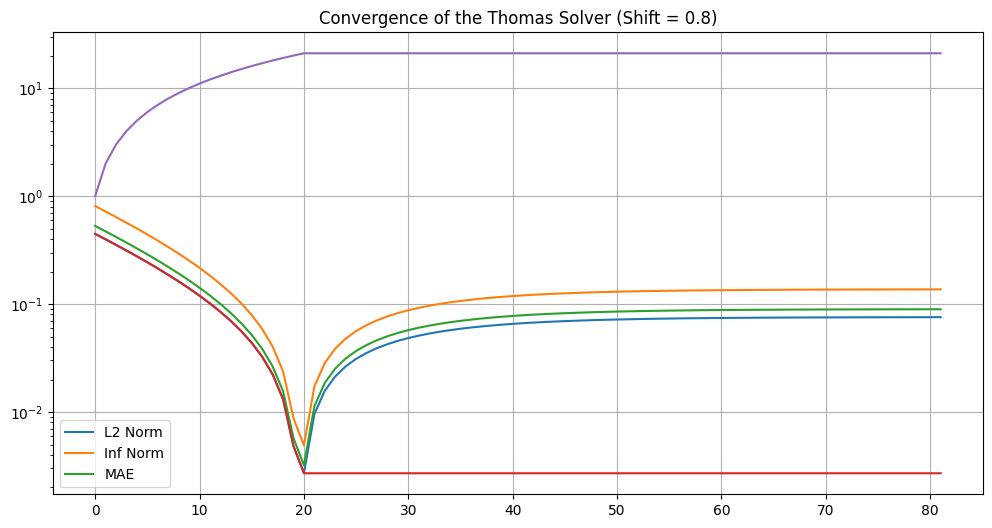

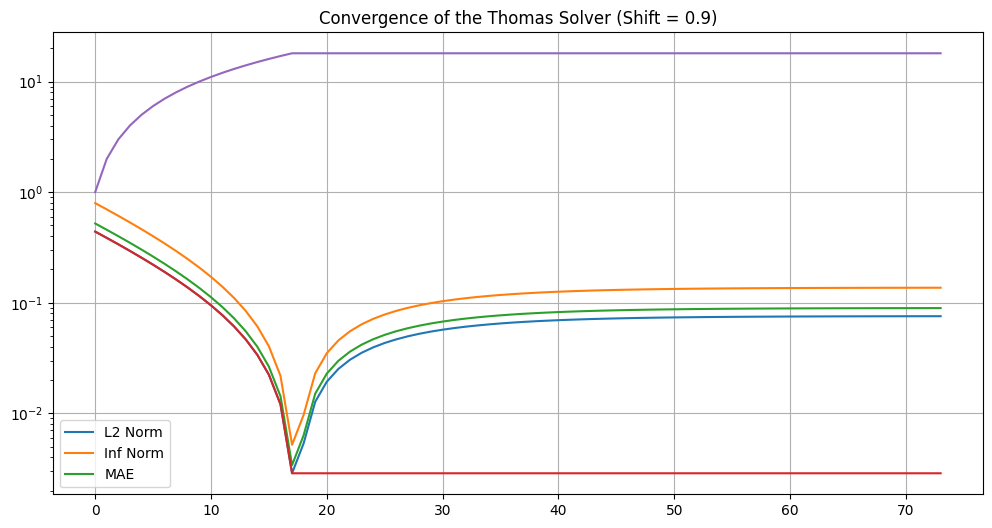

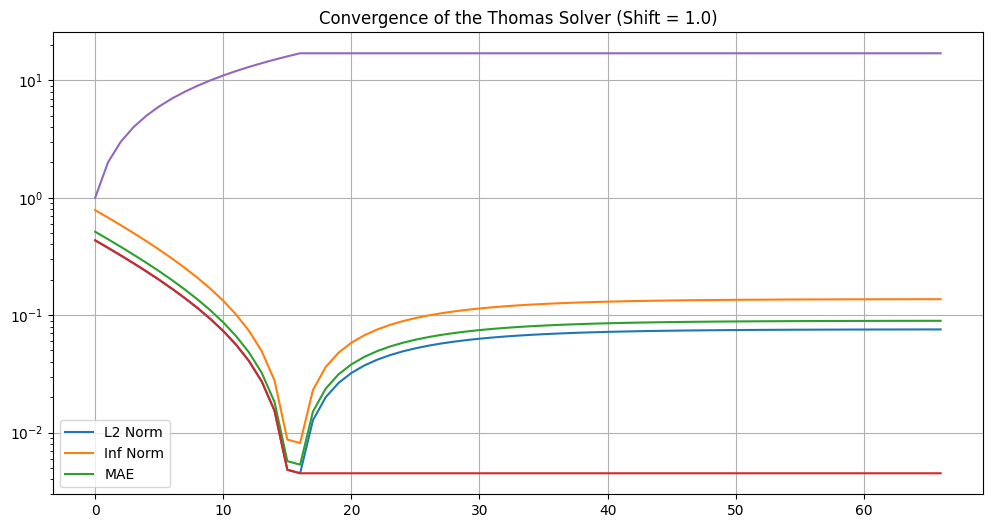

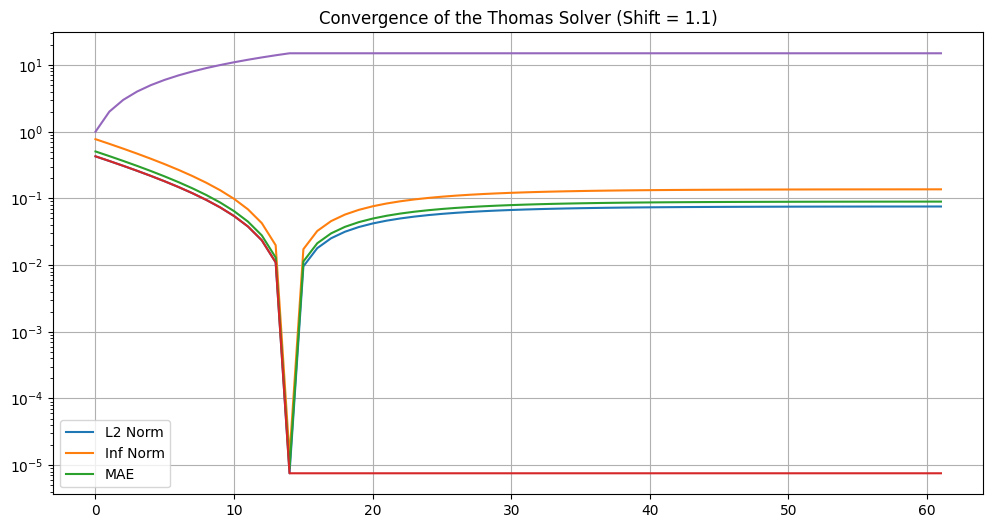

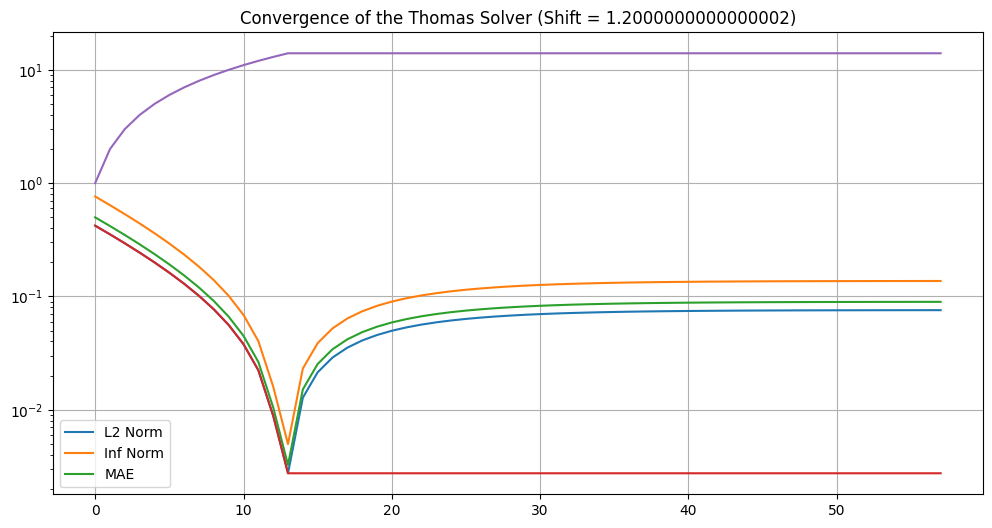

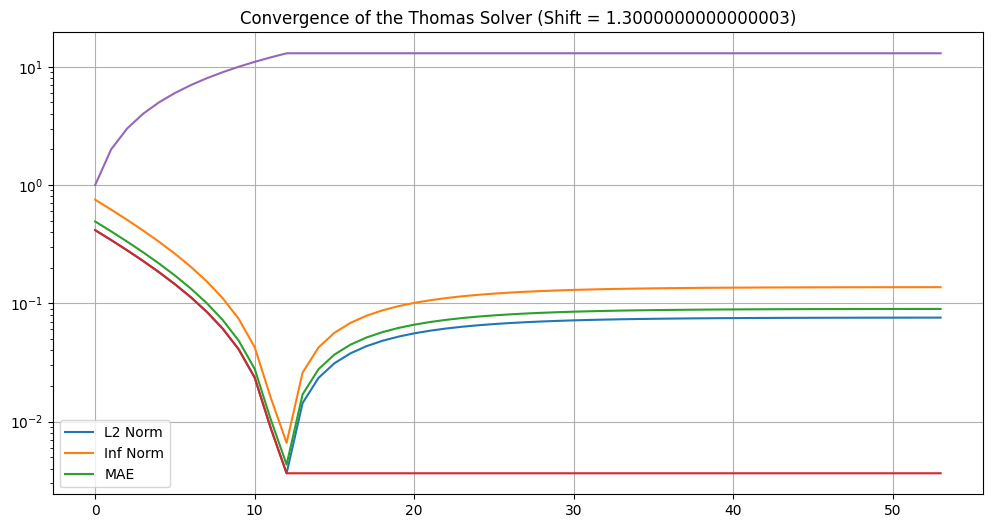

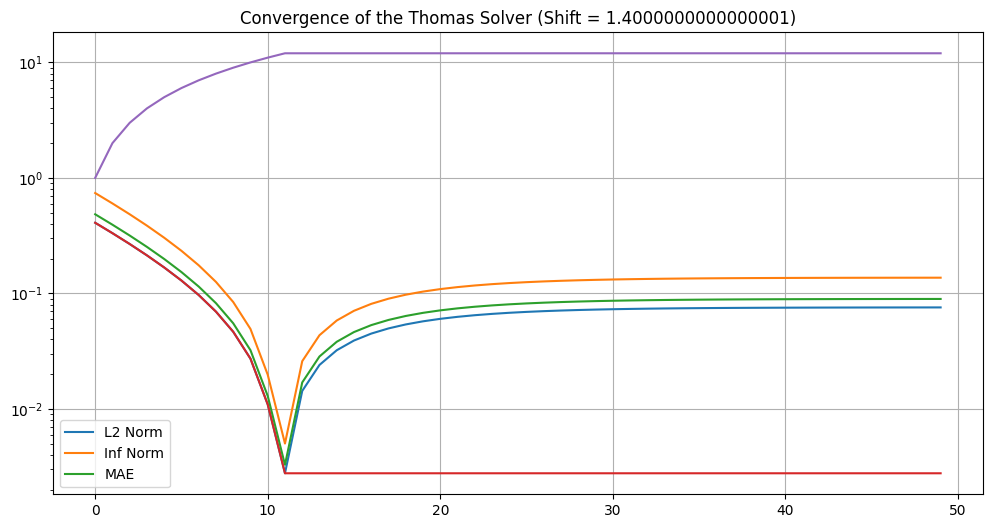

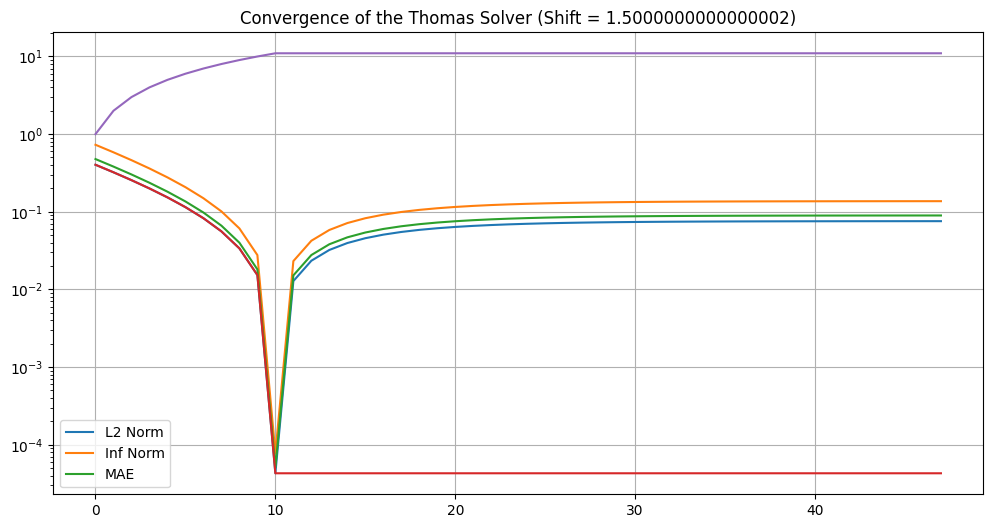

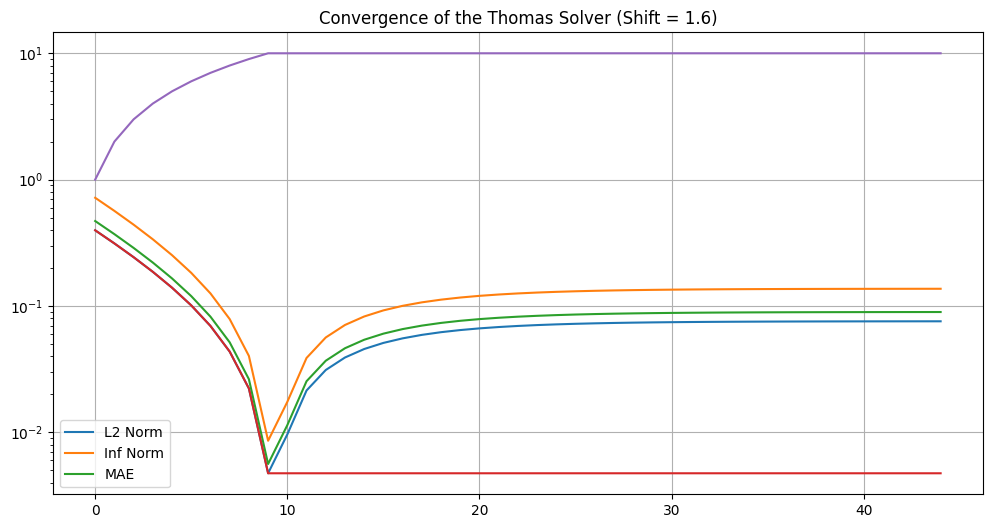

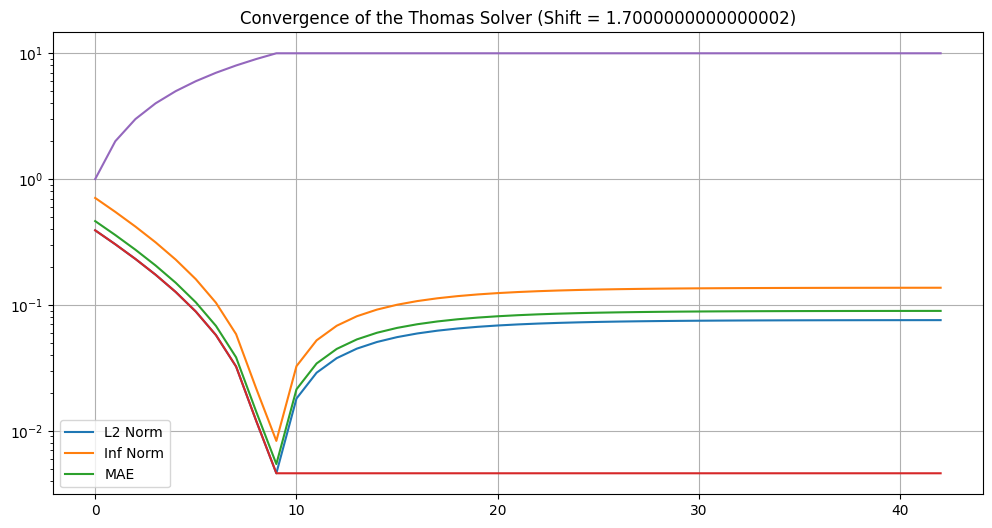

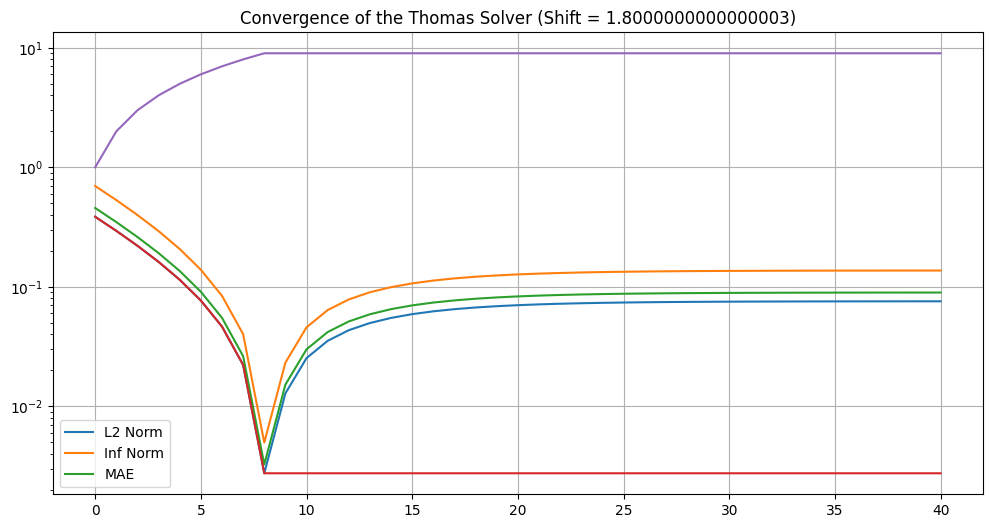

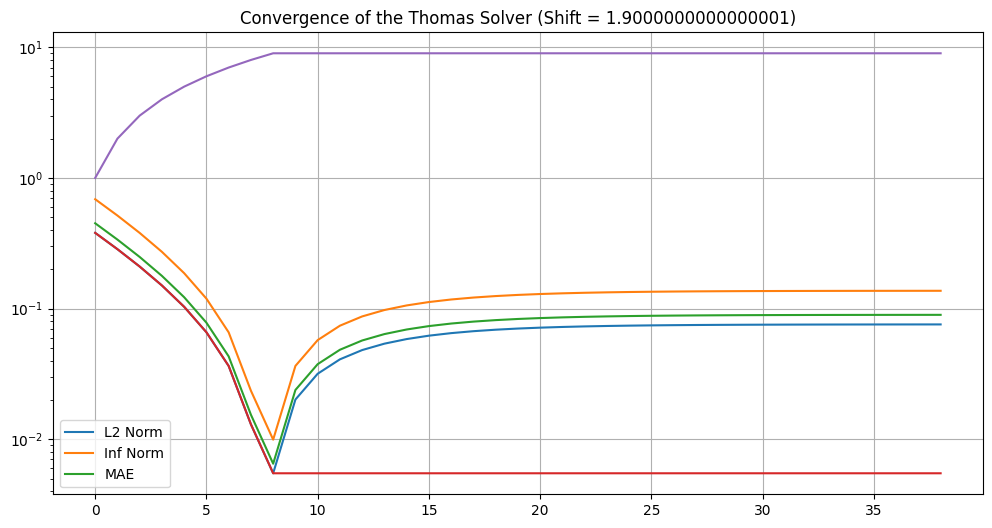

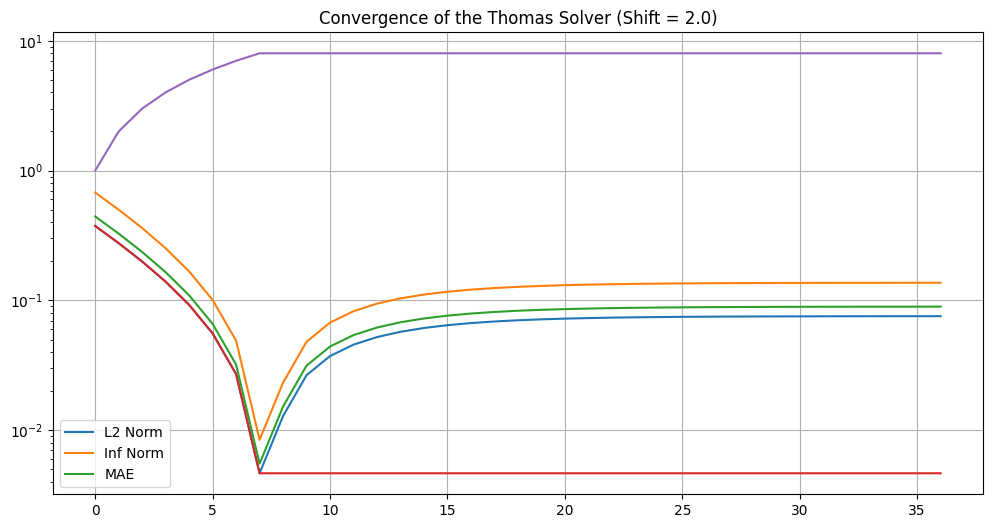

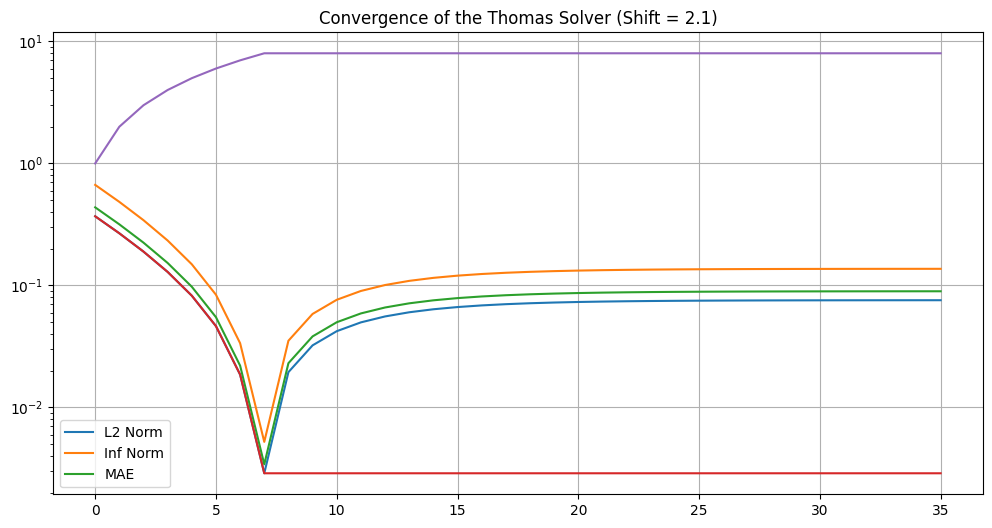

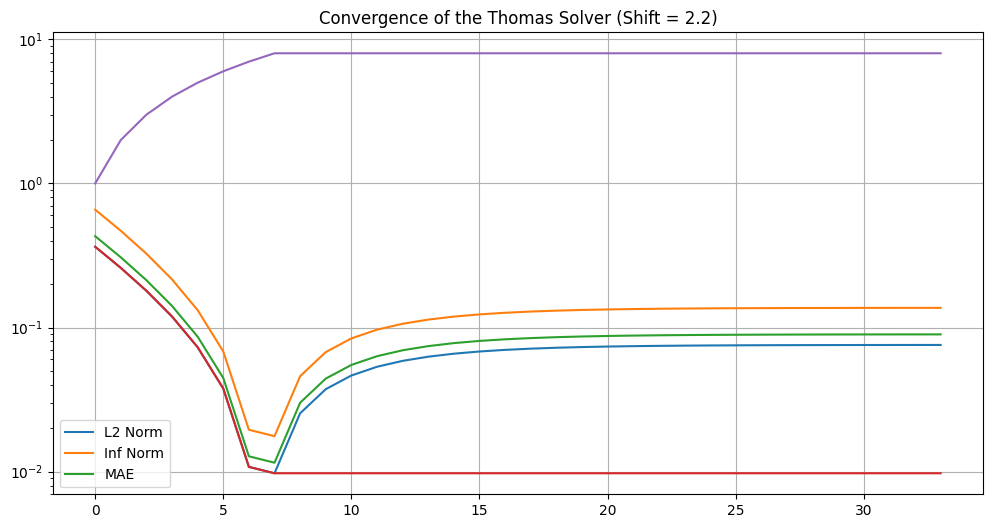

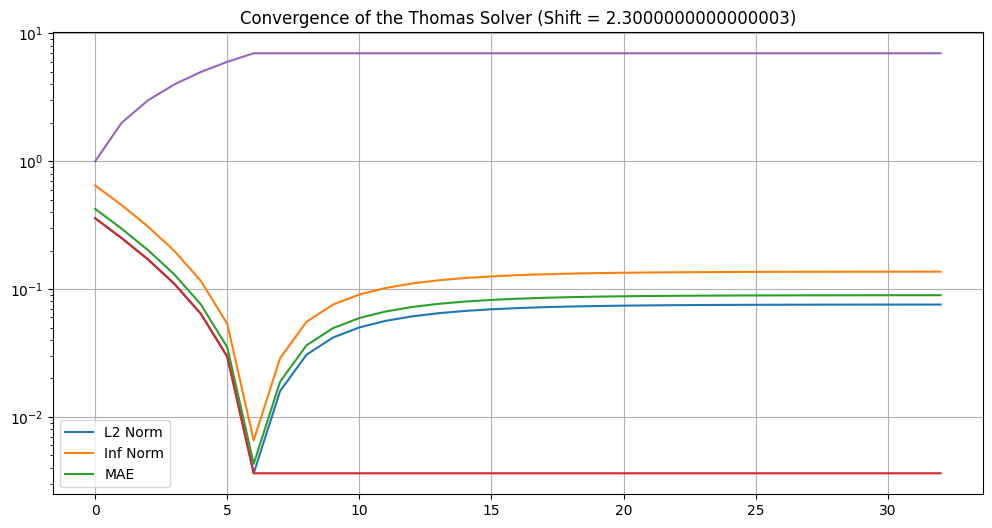

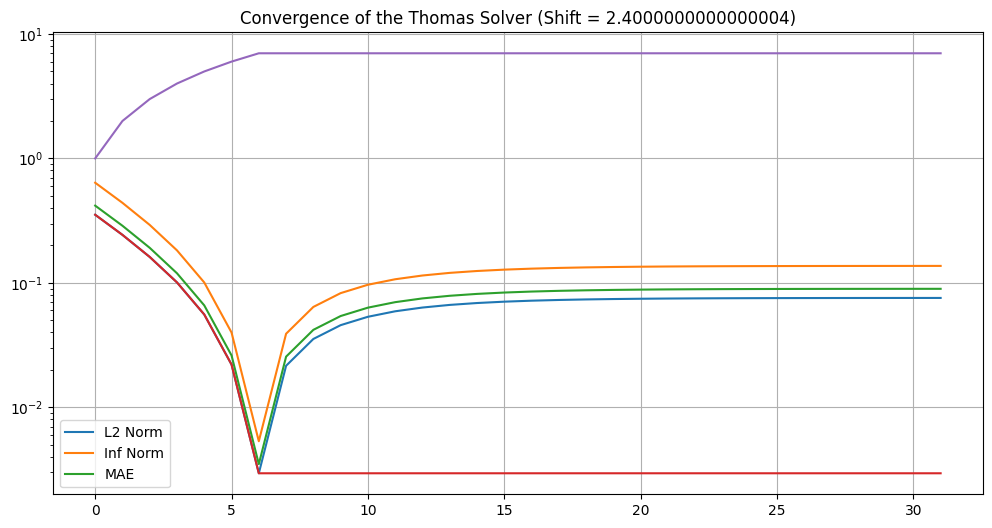

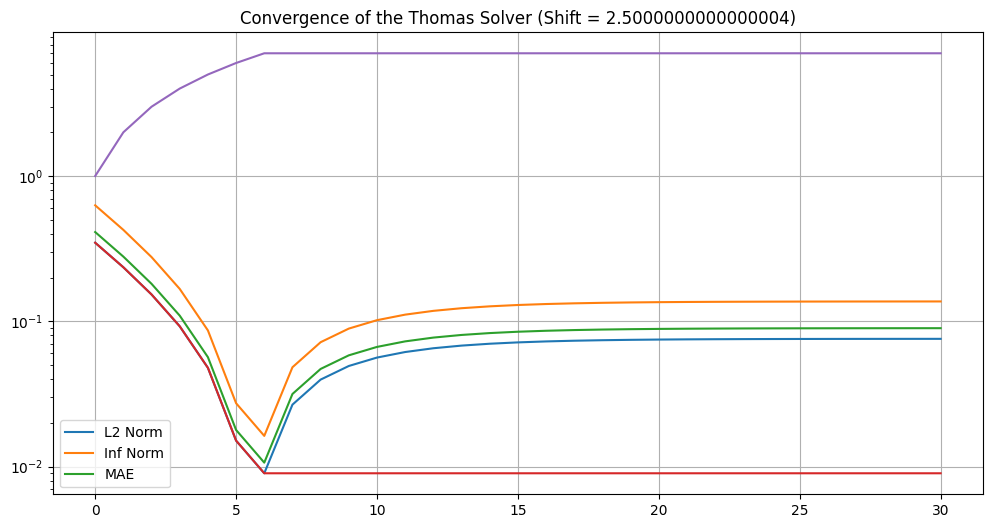

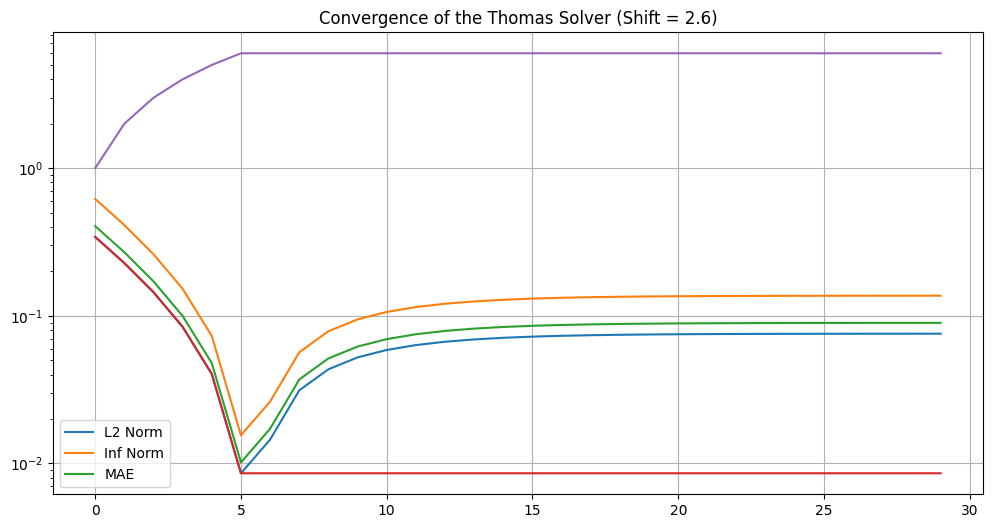

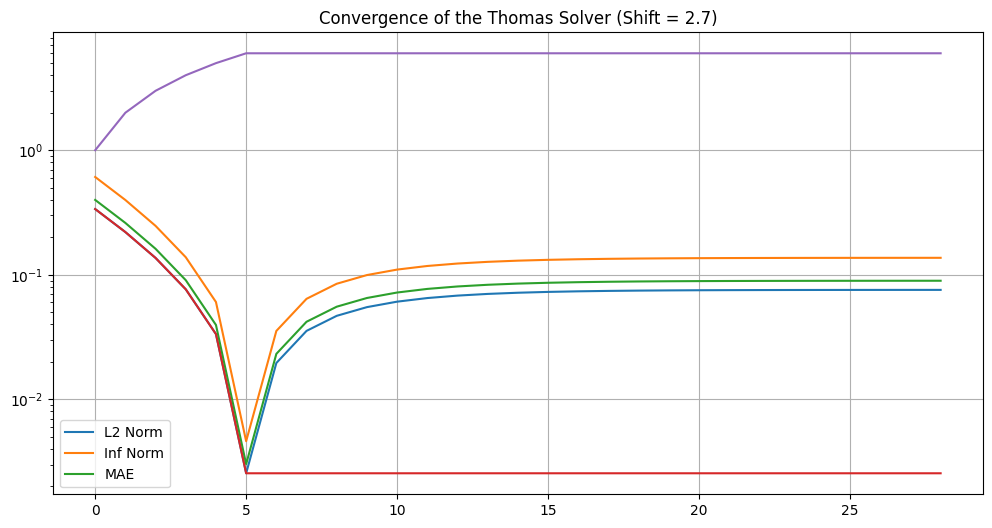

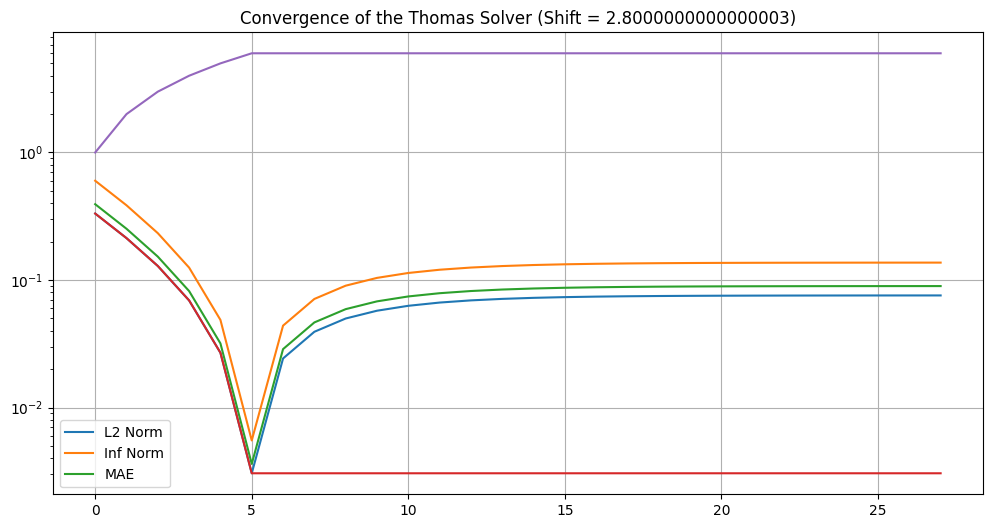

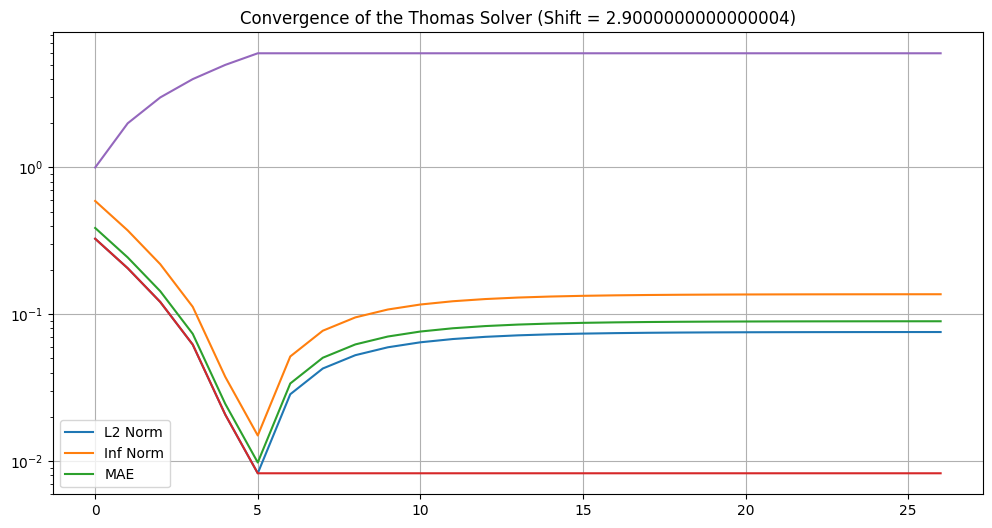

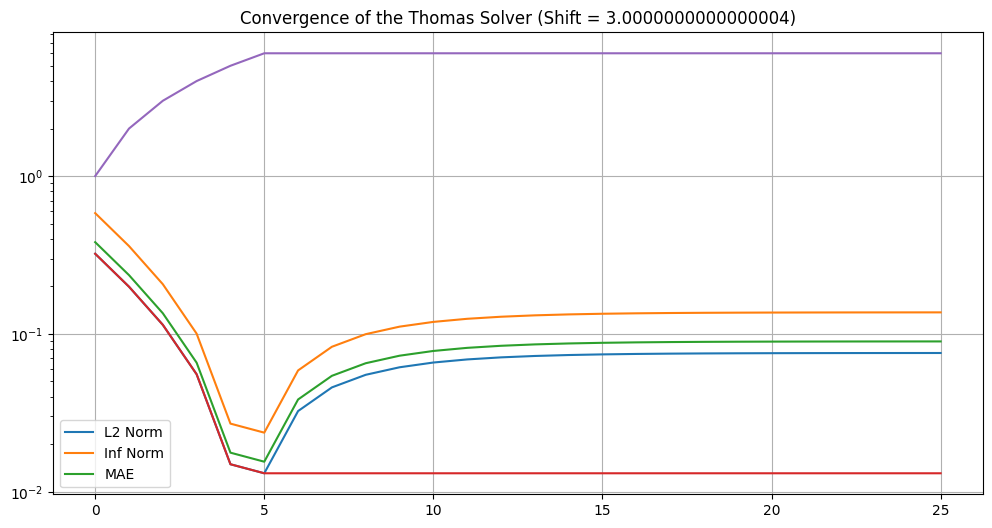

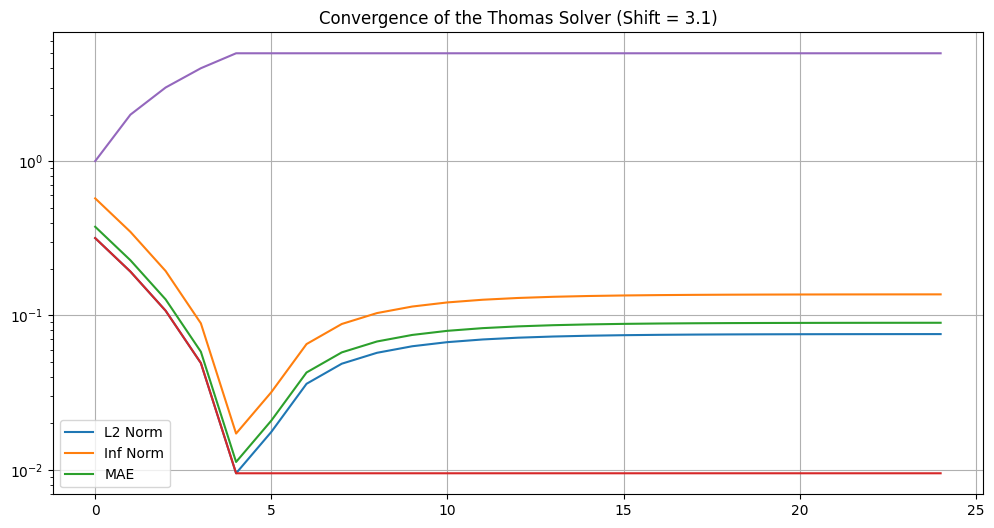

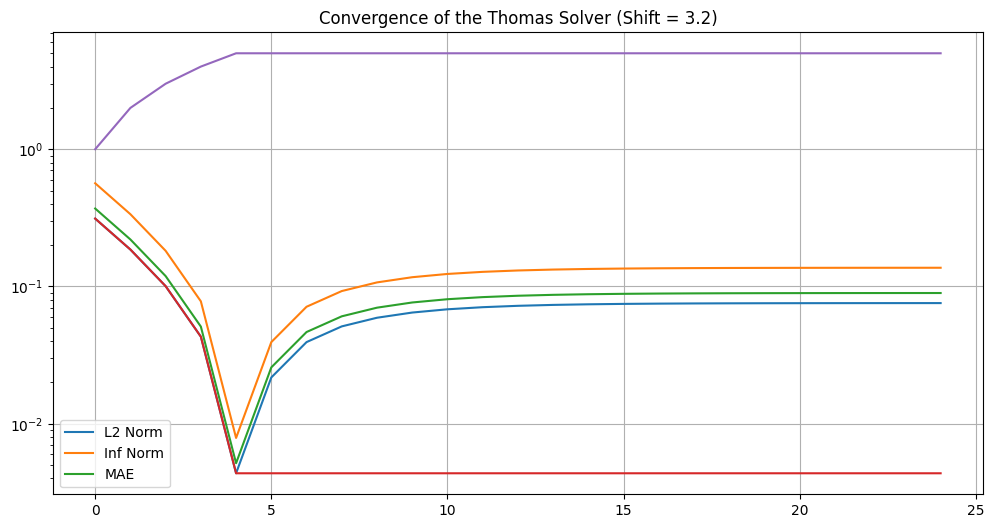

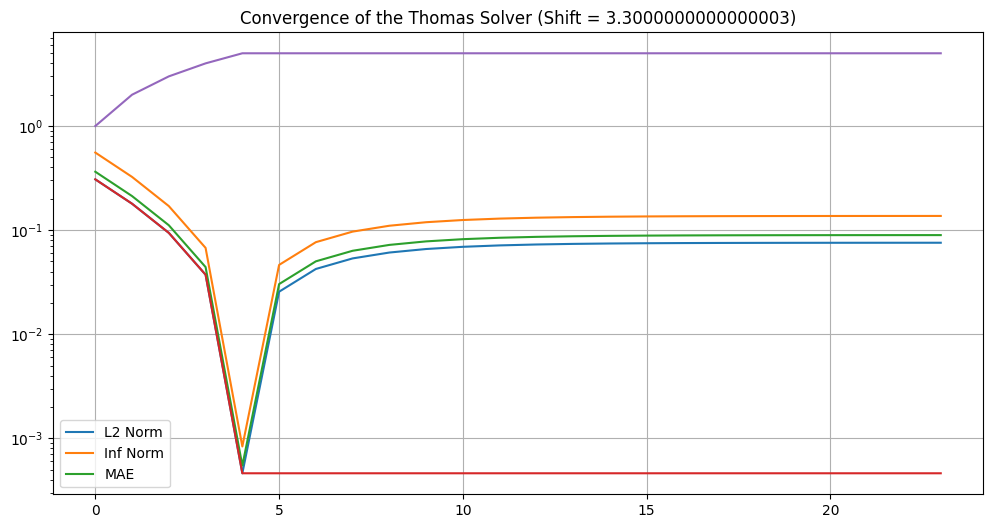

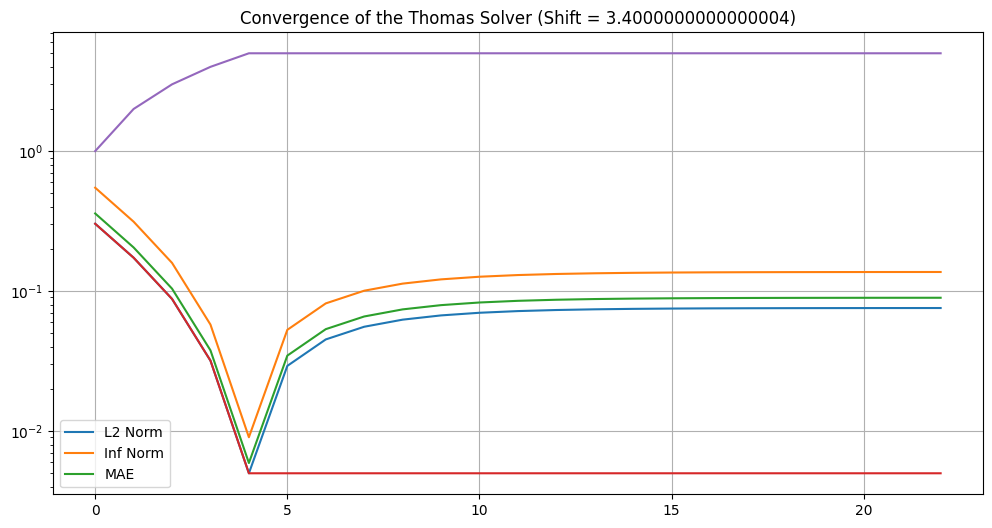

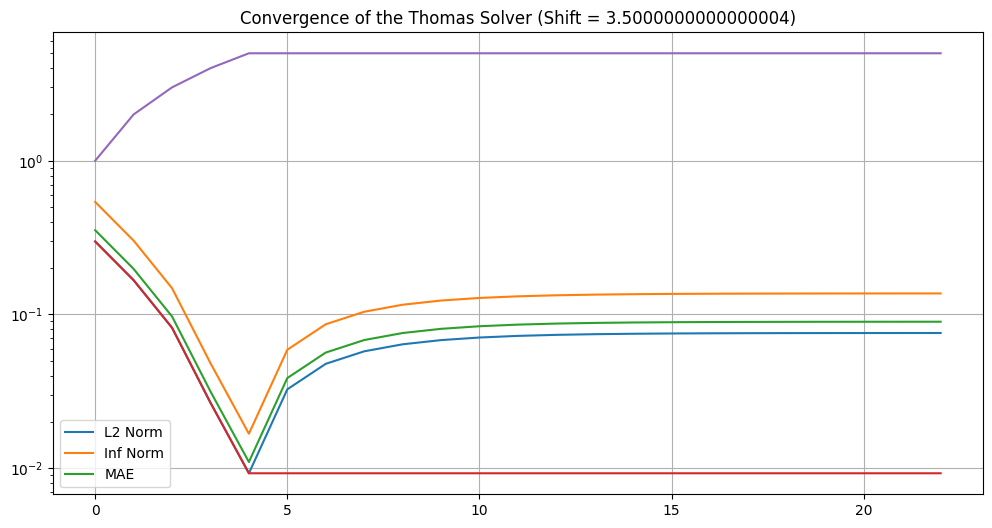

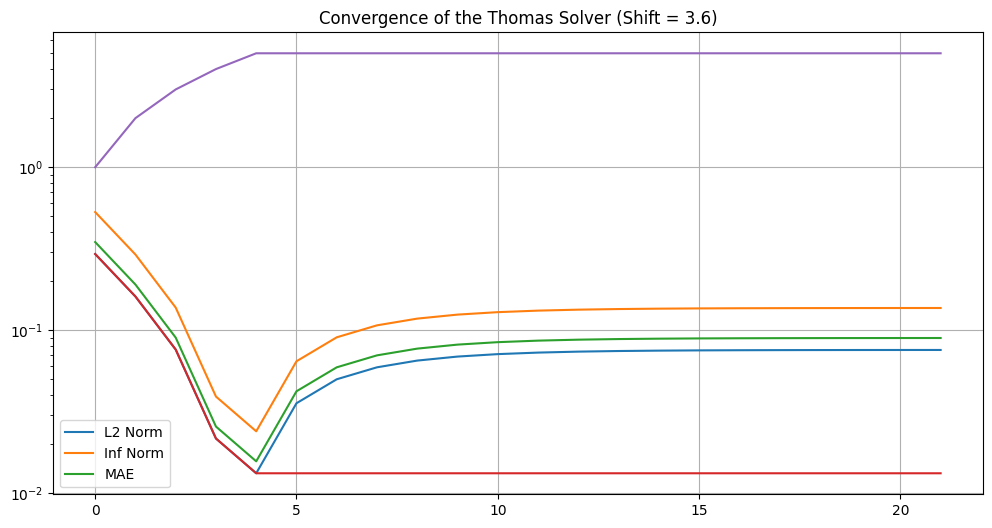

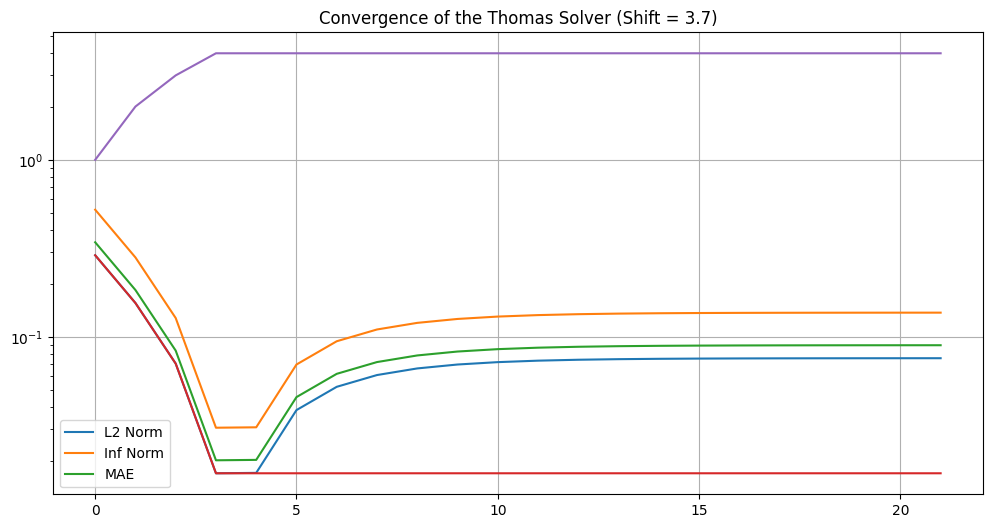

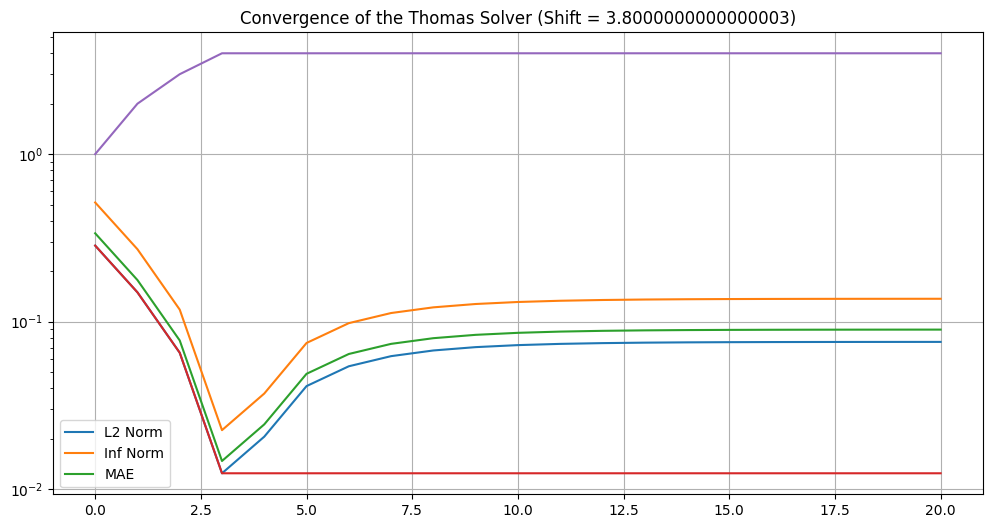

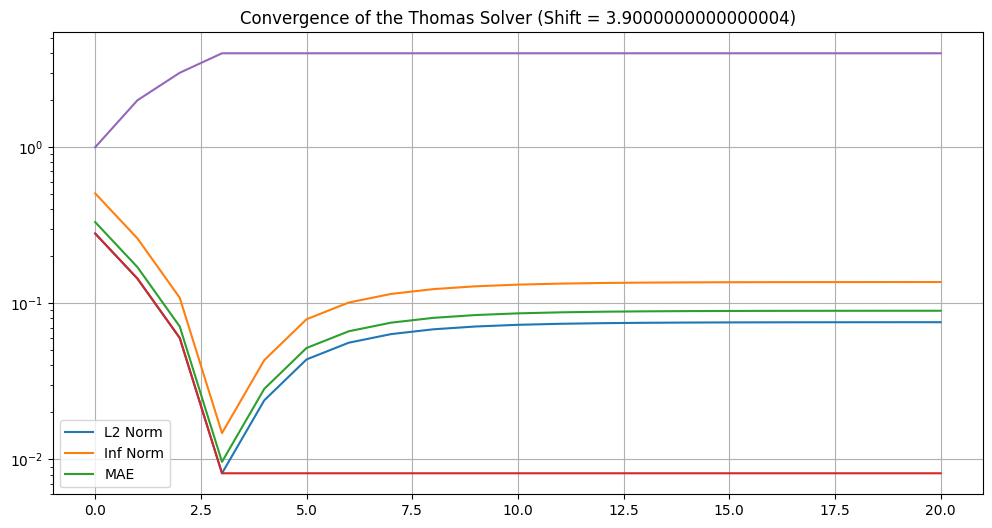

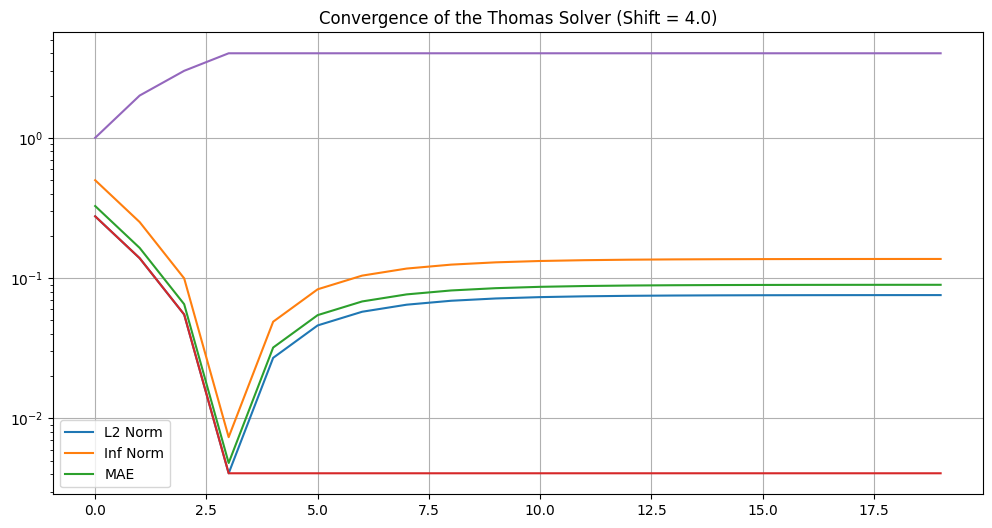

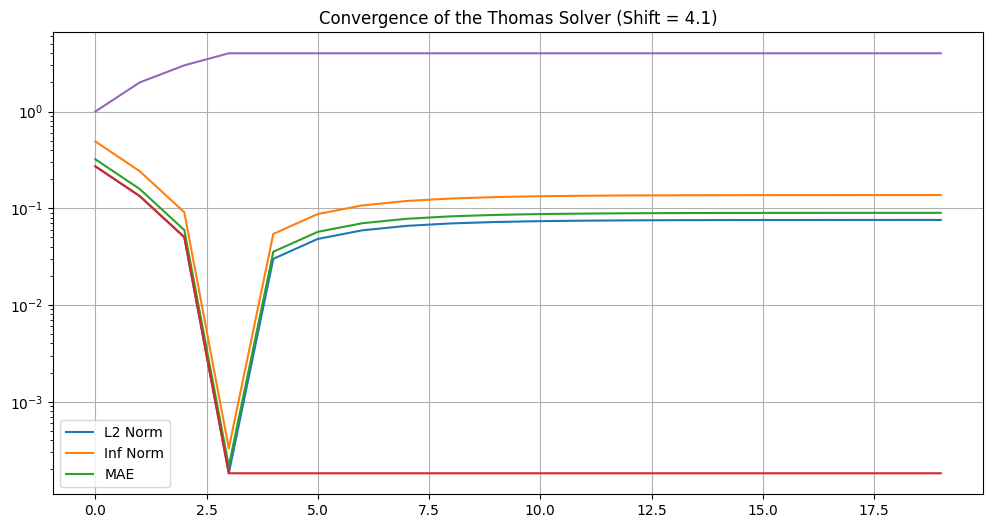

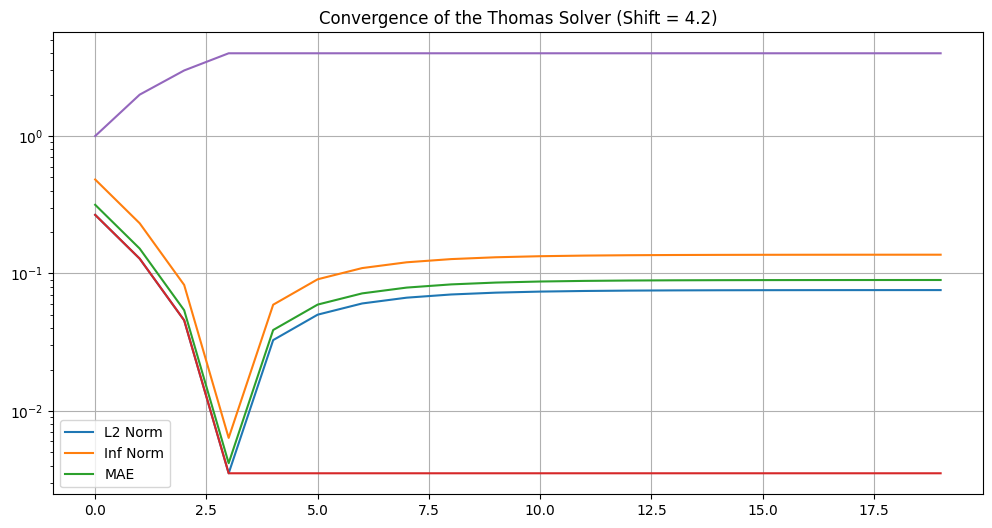

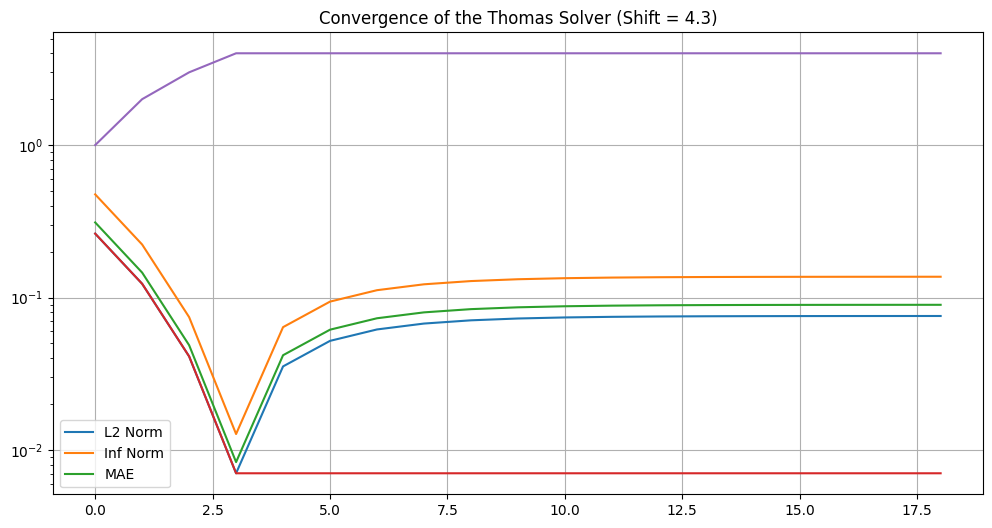

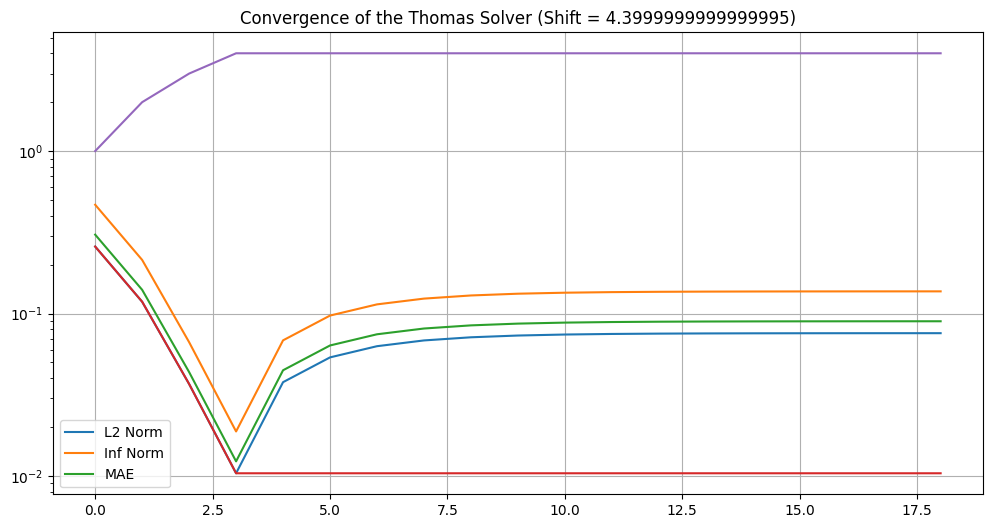

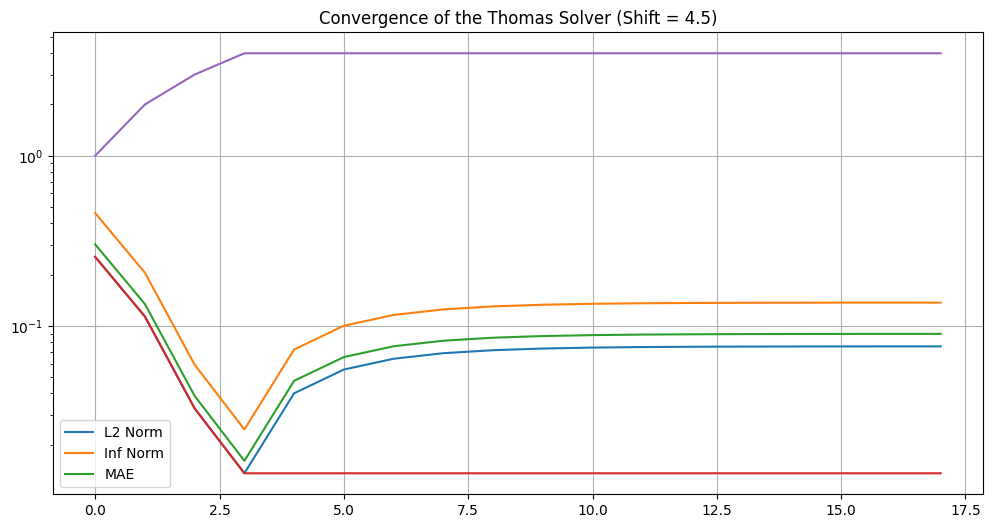

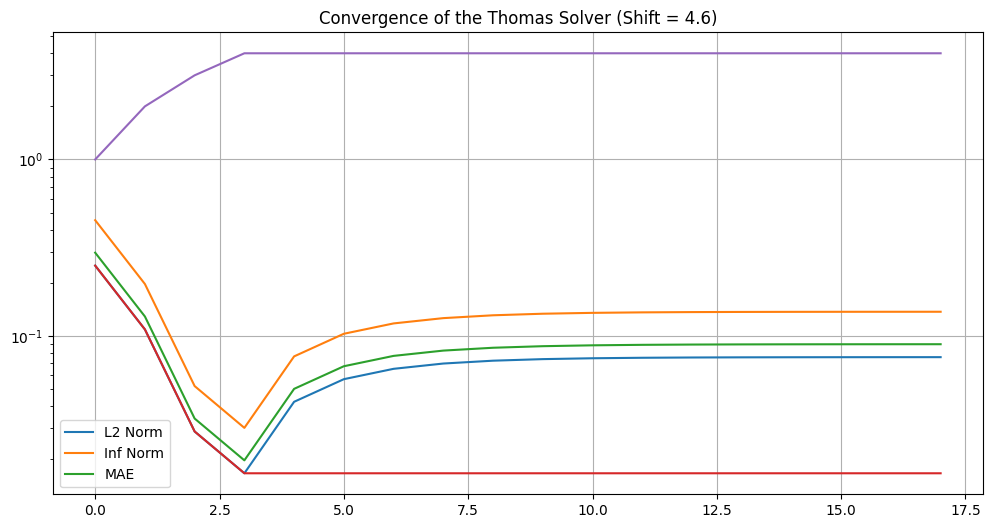

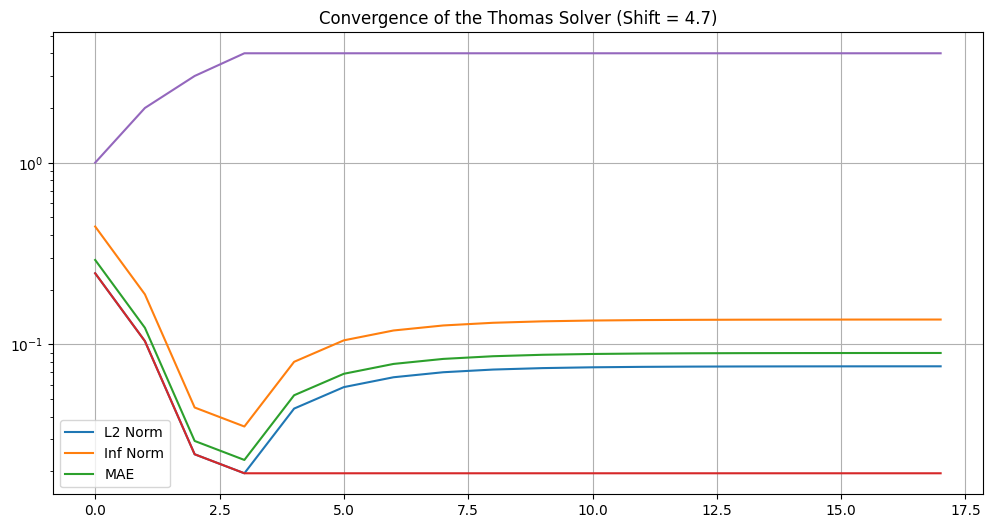

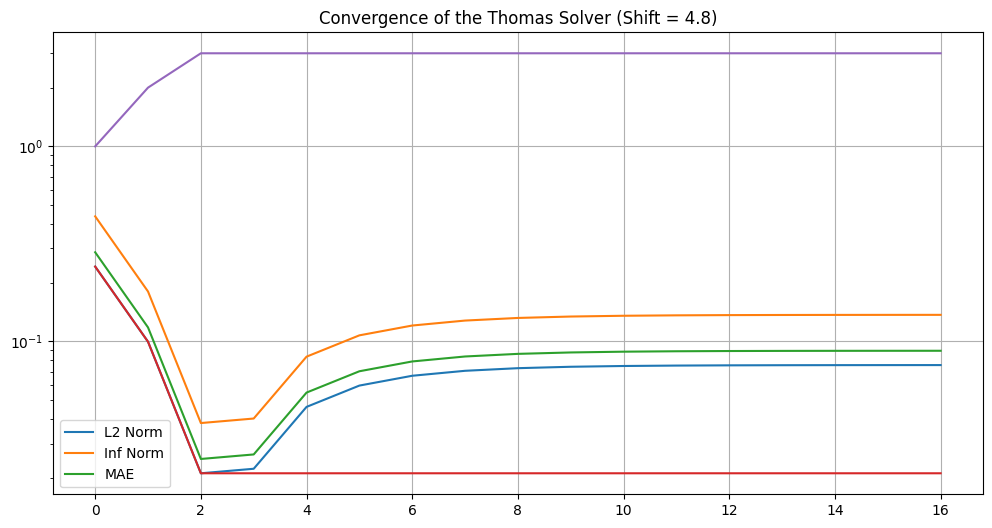

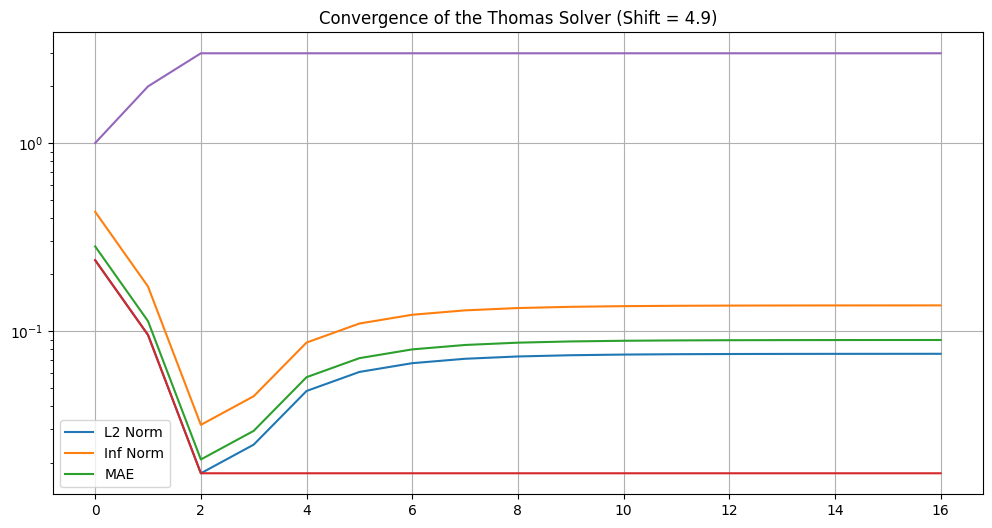

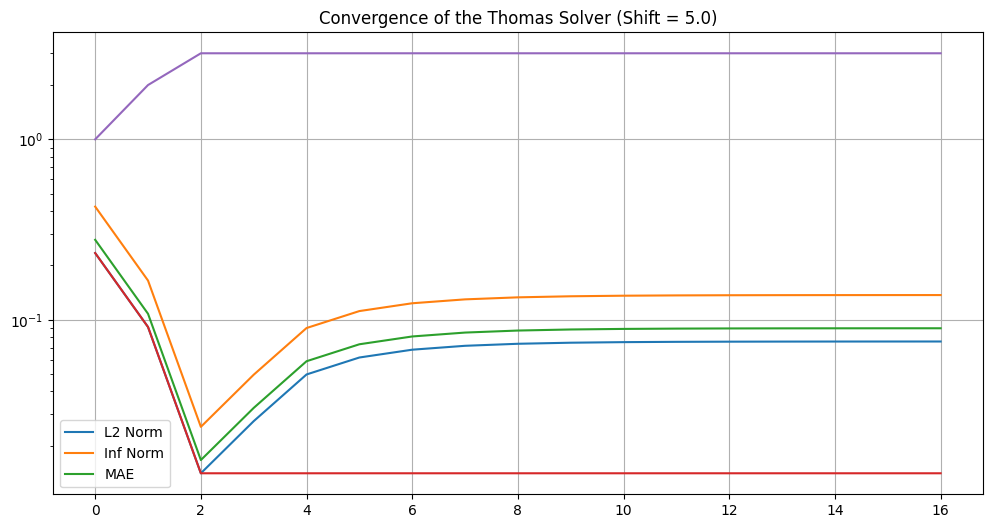

In [168]:
# List of shift values to test (investigation on the shift parameter)
shift_list = np.linspace(0.1, 5, 50)  # adjust range/number as needed
#shift_list = shift_list * np.cos(np.pi / N)  # Adjust shift based on your problem
Lx = 1.0       # Length of the x-dimension
Ly = 1.0       # Length of the y-dimension
k = 2.0              # Wave Number
max_iter = 1000
num_shots = 1000

# We'll use a fixed qubit count for this study
NUM_QUBITS = 2
N = 2**NUM_QUBITS
N_total = N + 2

# Define grid spacing and grids
dx = Lx / (N + 1)
dy = Ly / (N + 1)
h = dx  # h assumed same in both directions

# Create full grid including boundaries
x_vals = np.linspace(0, Lx, N_total)
y_vals = np.linspace(0, Ly, N_total)
x, y = np.meshgrid(x_vals, y_vals, indexing='ij')

# Interior grid points
interior_x = x_vals[1:-1]
interior_y = y_vals[1:-1]
interior_X, interior_Y = np.meshgrid(interior_x, interior_y, indexing='ij')

# Forcing function (evaluated on the interior)
f_interior  = (k**2*(1 - 2*np.pi**2)) * np.sin(k*np.pi*interior_X)*np.sin(k*np.pi*interior_Y)


# High resolution grid for the analytical solution
X_high_res, Y_high_res = np.meshgrid(np.linspace(0, Lx, 100), np.linspace(0, Ly, 100), indexing='ij')
u_analytical = np.sin(k * np.pi * X_high_res) * np.sin(k * np.pi * Y_high_res)

# Resampled analytical solution on the computed grid (for error estimation)
u_analytical_resampled = np.sin(k * np.pi * interior_X) * np.sin(k * np.pi * interior_Y)


# Dictionary to store errors for each shift value
errors_vs_shift = {}
ek = 0.0001
for shift in shift_list:
    print(f"Running shift study for shift = {shift}")
    # Initial guess
    u_init = np.zeros((N, N))
    
    # Solve using the ADI statevector validation method
    u_thomas, errors = ADI_val_sv_2(u_init, f_interior, u_analytical_resampled, shift, ek,
                                                    max_iter=max_iter, numShots=num_shots)

    # Use last iteration's percent difference and error values for reporting
    last_error = errors[-1]
    
    errors_vs_shift[shift] = {
        "L2 Error (Thomas)": last_error[0],
        "Linf Error (Thomas)": last_error[1],
        "MAE Error (Thomas)": last_error[2],
        "minimum_error" : last_error[3],
        'minimum_error_iteration' : last_error[4],
    }
    
    #print the errrors vs iterations for this case
    
    fig = plt.figure(figsize=(12, 6))
    plt.plot(errors)
    plt.legend(['L2 Norm', 'Inf Norm', 'MAE'])
    plt.title(f'Convergence of the Thomas Solver (Shift = {shift})')
    plt.yscale('log')
    plt.grid()
    
    print(f"shift = {shift}: L2 Error (Thomas) = {last_error[0]}, minimum_error = {last_error[3]}, minimum_error_iteration = {last_error[4]}")
    
    #visualize(x, y, X_high_res, Y_high_res, u_analytical, u_hhl_norm, u_thomas_norm)


## Plot Results

Shift: 0.1, Minimum Iteration: 165
Shift: 0.2, Minimum Iteration: 83
Shift: 0.30000000000000004, Minimum Iteration: 55
Shift: 0.4, Minimum Iteration: 41
Shift: 0.5, Minimum Iteration: 33
Shift: 0.6, Minimum Iteration: 28
Shift: 0.7000000000000001, Minimum Iteration: 24
Shift: 0.8, Minimum Iteration: 21
Shift: 0.9, Minimum Iteration: 18
Shift: 1.0, Minimum Iteration: 17
Shift: 1.1, Minimum Iteration: 15
Shift: 1.2000000000000002, Minimum Iteration: 14
Shift: 1.3000000000000003, Minimum Iteration: 13
Shift: 1.4000000000000001, Minimum Iteration: 12
Shift: 1.5000000000000002, Minimum Iteration: 11
Shift: 1.6, Minimum Iteration: 10
Shift: 1.7000000000000002, Minimum Iteration: 10
Shift: 1.8000000000000003, Minimum Iteration: 9
Shift: 1.9000000000000001, Minimum Iteration: 9
Shift: 2.0, Minimum Iteration: 8
Shift: 2.1, Minimum Iteration: 8
Shift: 2.2, Minimum Iteration: 8
Shift: 2.3000000000000003, Minimum Iteration: 7
Shift: 2.4000000000000004, Minimum Iteration: 7
Shift: 2.500000000000000

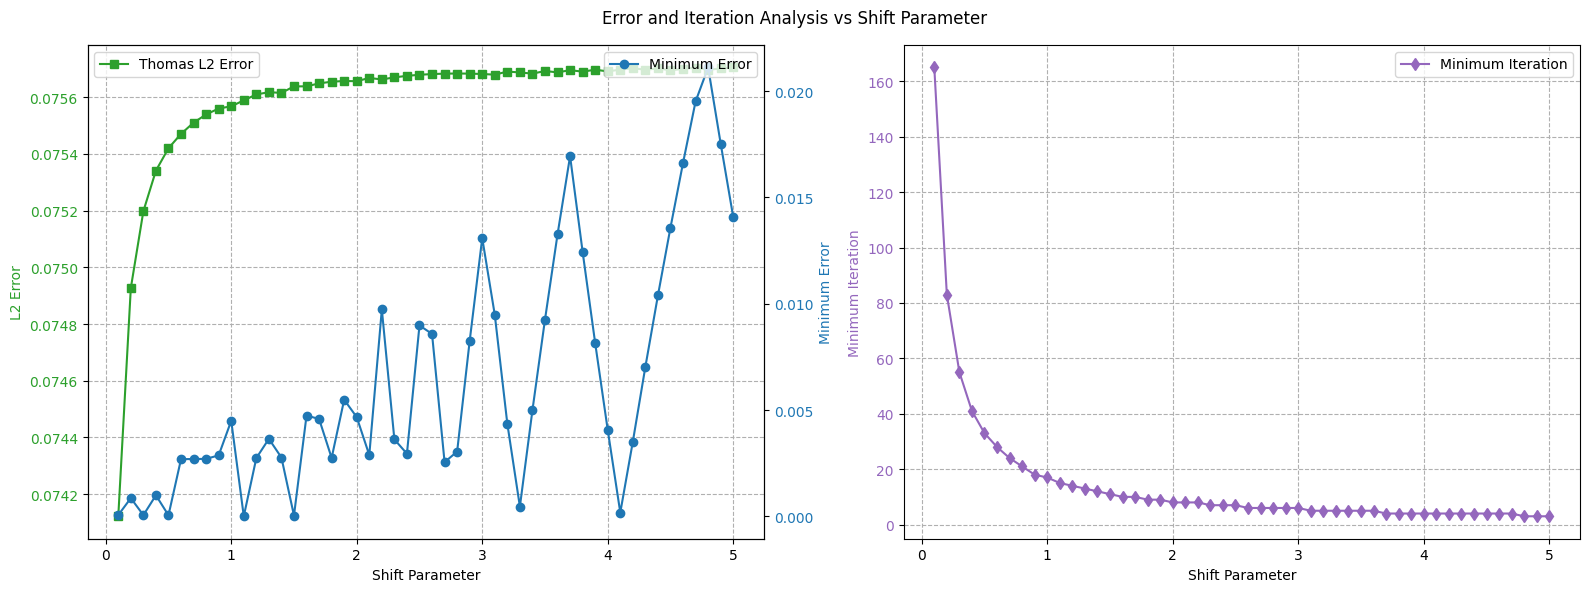

In [170]:
# Analyze and visualize the results
# Plot the error for different shift parameters
shift_values = list(errors_vs_shift.keys())
thomas_errors = [errors_vs_shift[shift]["L2 Error (Thomas)"] for shift in shift_values]
minimum_errors = [errors_vs_shift[shift]["minimum_error"] for shift in shift_values]

# print the minimum iteration for each shift
for shift in shift_values:
    print(f"Shift: {shift}, Minimum Iteration: {errors_vs_shift[shift]['minimum_error_iteration']}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot L2 Error on the primary y-axis for the first subplot
color = 'tab:green'
ax1.set_xlabel('Shift Parameter')
ax1.set_ylabel('L2 Error', color=color)
ax1.plot(shift_values, thomas_errors, label='Thomas L2 Error', marker='s', color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.legend(loc='upper left')
ax1.grid(True, which="both", ls="--")

# Create a secondary y-axis for minimum error on the first subplot
ax1_twin = ax1.twinx()
color = 'tab:blue'
ax1_twin.set_ylabel('Minimum Error', color=color)
ax1_twin.plot(shift_values, minimum_errors, label='Minimum Error', marker='o', color=color)
ax1_twin.tick_params(axis='y', labelcolor=color)
ax1_twin.legend(loc='upper right')

# Plot Minimum Iteration on the second subplot
color = 'tab:purple'
ax2.set_xlabel('Shift Parameter')
ax2.set_ylabel('Minimum Iteration', color=color)
minimum_iterations = [errors_vs_shift[shift]["minimum_error_iteration"] for shift in shift_values]
ax2.plot(shift_values, minimum_iterations, label='Minimum Iteration', marker='d', color=color)
ax2.tick_params(axis='y', labelcolor=color)
ax2.legend(loc='upper right')
ax2.grid(True, which="both", ls="--")

plt.suptitle('Error and Iteration Analysis vs Shift Parameter')
plt.tight_layout()
plt.show()
#hhl_mean_percent_error = [errors_vs_shift[shift]["Mean Percent Error (HHL)"] for shift in shift_values]
# thomas_mean_percent_error = [errors_vs_shift[shift]["Mean Percent Error (Thomas)"] for shift in shift_values]

# fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# # Plot Mean Percent Error for HHL
# axs[0].plot(shift_values, hhl_mean_percent_error, label='HHL Mean Percent Error', marker='o', color='red')
# ideal_shift = 2 * np.cos(np.pi / N)
# axs[0].axvline(ideal_shift, color='black', linestyle='--', label=f'Ideal Shift ({ideal_shift:.2f})')
# axs[0].set_xlabel('Shift Parameter')
# axs[0].set_ylabel('Mean Percent Error')
# axs[0].set_title('HHL Mean Percent Error vs Shift Parameter')
# axs[0].legend()
# axs[0].grid(True, which="both", ls="--")

# # Plot Mean Percent Error for Thomas
# axs[1].plot(shift_values, thomas_mean_percent_error, label='Thomas Mean Percent Error', marker='s', color='purple')
# ideal_shift = 2 * np.cos(np.pi / N)
# axs[1].axvline(ideal_shift, color='black', linestyle='--', label=f'Ideal Shift ({ideal_shift:.2f})')
# axs[1].set_xlabel('Shift Parameter')
# axs[1].set_ylabel('Mean Percent Error')
# axs[1].set_title('Thomas Mean Percent Error vs Shift Parameter')
# axs[1].legend()
# axs[1].grid(True, which="both", ls="--")

# plt.tight_layout()
# plt.show()

# # Plot the number of iterations vs shift
# plt.figure(figsize=(10, 6))
# plt.plot(shift_values, [errors_vs_shift[shift]["iteration"] for shift in shift_values], marker='o', linestyle='-')
# plt.xlabel('Shift Parameter')
# plt.ylabel('Number of Iterations')
# plt.title('Number of Iterations vs Shift Parameter')
# plt.grid(True, which="both", ls="--")
# plt.show()



# Solution Testing :: GAUSS :: confirmed working

Define solution and ADI parameters

In [ ]:
# Domain specifications
Lx = 1.0       # Length of the x-dimension
Ly = 1.0       # Length of the y-dimension
NUM_QUBITS = 3 # Number of qubits used to represent the solution
N = 2**NUM_QUBITS  # Number of interior grid points in each dimension
N_total = N + 2    # Total grid points including boundaries

dx = Lx / (N + 1)  # Grid spacing (consistent with N interior points)
dy = Ly / (N + 1)
h = dx

# Create full grid including boundaries
x_vals = np.linspace(0, Lx, N_total)
y_vals = np.linspace(0, Ly, N_total)

# Extract interior points (excluding boundaries)
interior_x = x_vals[1:-1]
interior_y = y_vals[1:-1]
interior_X, interior_Y = np.meshgrid(interior_x, interior_y, indexing='ij')

# PDE specifications
k = 10.0  # Wave Number
main_diag = -4/dx**2 + k**2  # main diagonal
off_diag = 1/dx**2   # off diagonal
Ax = construct_TT_matrix(main_diag=main_diag, off_diag=off_diag, size=N)
Ay = Ax

# Build the forcing function
f, f_grid, x_grid, y_grid = generate_forcing_function(N, N, Lx, Ly, forcing_type='gaussian', x0=Lx/2, y0=Ly/2, sigma=0.1, amplitude=1.0)
# Visualise forcing function
plot_forcing_function(f_grid, x_grid, y_grid, title="Forcing Function")

# get psuedo
u_analytic_high_res, X_high_res, Y_high_res = prepare_pseudoanalytic(Lx, Ly, k, N_high_res=100, type='gaussian')


Call the ADI now

In [ ]:
u_init = np.zeros((N,N))

# Solve using the ADI now in quantum
backend = Aer.get_backend('qasm_simulator')
backend_options = {
    'max_parallel_threads': 8,      # use up to 4 threads
    'max_parallel_experiments': 16,    # run up to 2 experiments in parallel
    'seed_simulator': 42,            # set a seed for reproducibility
    }

#u_hhl, u_tom, errors, pct_diff = ADI_qasm(u_init, Ax, Ay, f_grid, backend, backend_options, max_iter=3)
u_hhl, u_tom, pct_diff = ADI_sv_prec(u_init, Ax, Ay, f_grid,h,k, alpha=0.2, max_iter=3)

In [ ]:
####################################### Final solution #########################################################################
# Pad the computed solution with a boundary of zeros (Dirichlet condition)
lb, ub= -1.0,1.0
x, y = np.meshgrid(x_vals, y_vals, indexing='ij')
u_tom_padded = np.pad(u_tom, pad_width=1, mode='constant', constant_values=0)
u_tom_padded = normalize(u_tom_padded, lb, ub)

u_hhl_padded = np.pad(u_hhl, pad_width=1, mode='constant', constant_values=0)
u_hhl_padded = normalize(u_hhl_padded, lb, ub)

####################################### Final solution #########################################################################
# subplots of the erros heatmap

visualize(x, y, X_high_res, Y_high_res, -u_analytic_high_res, -u_hhl_padded, -u_tom_padded, cmap='hot')

# plot eerrors
plt.figure(figsize=(10, 6))
ax1 = plt.gca()
ax1.plot(range(1, len(errors) + 1), [err for err in errors], 'o-', label='L2 difference ', color='blue')
ax1.set_yscale('log')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('L2 Error (log scale)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.legend(loc='upper left')

# Create a twin y-axis for percent difference
ax2 = ax1.twinx()
ax2.plot(range(1, len(pct_diff) + 1), [np.mean(diff) for diff in pct_diff], 's--', color='red', label='Mean Pct Diff')
ax2.set_ylabel('Mean Percent Difference', color='red')
ax2.set_yscale('log')
ax2.tick_params(axis='y', labelcolor='red')
ax2.legend(loc='upper right')

plt.title('Error Convergence')
plt.tight_layout()
plt.show()

## Solution Testing :: UNIF

In [ ]:
# Domain specifications
Lx = 1.0       # Length of the x-dimension
Ly = 1.0       # Length of the y-dimension
NUM_QUBITS = 3 # Number of qubits used to represent the solution
N = 2**NUM_QUBITS  # Number of interior grid points in each dimension
N_total = N + 2    # Total grid points including boundaries

dx = Lx / (N + 1)  # Grid spacing (consistent with N interior points)
dy = Ly / (N + 1)

# Create full grid including boundaries
x_vals = np.linspace(0, Lx, N_total)
y_vals = np.linspace(0, Ly, N_total)

# Extract interior points (excluding boundaries)
interior_x = x_vals[1:-1]
interior_y = y_vals[1:-1]
interior_X, interior_Y = np.meshgrid(interior_x, interior_y, indexing='ij')

# PDE specifications
k = 10.0  # Wave Number
main_diag = -4/h**2 + k**2  # main diagonal
off_diag = 1/h**2   # off diagonal
Ax = construct_TT_matrix(main_diag=main_diag, off_diag=off_diag, size=N)
Ay = Ax

# Build the forcing function
f, f_grid, x_grid, y_grid = generate_forcing_function(N, N, Lx, Ly, forcing_type='uniform', amplitude=1.0)
# Visualise forcing function
plot_forcing_function(f_grid, x_grid, y_grid, title="Forcing Function")

# get psuedo
u_analytic_high_res, X_high_res, Y_high_res = prepare_pseudoanalytic(Lx, Ly, k, N_high_res=100, type='uniform')

In [ ]:
u_init = np.zeros((N,N))
# Solve using the ADI now in quantum
u_hhl, u_thomas, pct_diff =  ADI_sv_prec(u_init, Ax, Ay, f_grid,h, k, alpha = 0.1, max_iter = 4)

In [ ]:
####################################### Final solution #########################################################################
# Pad the computed solution with a boundary of zeros (Dirichlet condition)
lb, ub= -1.0,1.0
x, y = np.meshgrid(x_vals, y_vals, indexing='ij')
u_tom_padded = np.pad(u_thomas, pad_width=1, mode='constant', constant_values=0)
u_tom_padded = normalize(u_tom_padded, lb, ub)

u_hhl_padded = np.pad(u_hhl, pad_width=1, mode='constant', constant_values=0)
u_hhl_padded = normalize(u_hhl_padded, lb, ub)

u_analytical = normalize(u_analytical, lb, ub)

####################################### Final solution #########################################################################
# subplots of the erros heatmap

visualize(x, y, X_high_res, Y_high_res, -u_analytic_high_res, -u_hhl_padded, -u_tom_padded, cmap='hot')

# plot eerrors
plt.figure(figsize=(10, 6))
ax1 = plt.gca()
ax1.plot(range(1, len(errors) + 1), [err for err in errors], 'o-', label='L2 difference ', color='blue')
ax1.set_yscale('log')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('L2 Error (log scale)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.legend(loc='upper left')

# Create a twin y-axis for percent difference
ax2 = ax1.twinx()
ax2.plot(range(1, len(pct_diff) + 1), [np.mean(diff) for diff in pct_diff], 's--', color='red', label='Mean Pct Diff')
ax2.set_ylabel('Mean Percent Difference', color='red')
ax2.set_yscale('log')
ax2.tick_params(axis='y', labelcolor='red')
ax2.legend(loc='upper right')

plt.title('Error Convergence')
plt.tight_layout()
plt.show()

## Neumann Boundary Conditions
Assess and validate if the neumann b-c have been implemented correctly.

In [ ]:
def prepare_pseudoanalytic_neumann(Lx, Ly, k, N_high_res=100, type = 'gaussian'):
    """
    Prepare a pseudo-analytic solution using the ADI method with higher resolution.

    Parameters:
        f_high_grid : numpy.ndarray
            Forcing function grid at higher resolution.
        Lx, Ly : float
            Domain lengths in x and y directions.
        k : float
            Wave number for the Helmholtz equation.
        y_grid : numpy.ndarray
            Grid points in the y-direction.
        function : str, optional
            Description of the function being prepared (default is "Solution").
        N_high_res : int, optional
            Higher resolution grid size (default is 100).

    Returns:
        u_analytic_high_res : numpy.ndarray
            Pseudo-analytic solution at higher resolution.
        X_high_res, Y_high_res : numpy.ndarray
            Meshgrid of x and y coordinates at higher resolution.
    """
    # Define higher resolution parameters
    dx_high_res = Lx / (N_high_res + 1)
    dy_high_res = Ly / (N_high_res + 1)
    h_high_res = dx_high_res

    # Reconstruct the operator matrices for higher resolution
    main_diag_high_res = -4 / h_high_res**2 + k**2
    off_diag_high_res = 1 / h_high_res**2
    Ax_high_res = construct_TT_matrix(main_diag=main_diag_high_res, off_diag=off_diag_high_res, size=N_high_res)
    Ay_high_res = Ax_high_res

    # Generate the forcing function for higher resolution
    if type == 'gaussian':
        _, f_high_res_grid, _, _ = generate_forcing_function(
            N_high_res, N_high_res, Lx, Ly, forcing_type=type, x0=Lx/2, y0=Ly/2, sigma=0.1, amplitude=1.0
        )
    elif type == 'uniform':
        # Generate the forcing function for higher resolution
        _, f_high_res_grid, _, _ = generate_forcing_function(
            N_high_res, N_high_res, Lx, Ly, forcing_type='uniform', value=1.0
        )
    else:
        print('Invalid selection of forcing function type.')
        return None

    
    # Initialize the solution for higher resolution
    u_init_high_res = np.zeros((N_high_res, N_high_res))

    # Solve using the ADI method with the Thomas algorithm
    u_high_res_tom = ADI_neumann_general(u_init_high_res, Ax_high_res, Ay_high_res, f_high_res_grid)

    # Generate the high-resolution grid for visualization
    X_high_res, Y_high_res = np.meshgrid(np.linspace(0, Lx, N_high_res), np.linspace(0, Ly, N_high_res), indexing='ij')

    return u_high_res_tom, X_high_res, Y_high_res

def ADI_neumann_general(u, Ax, Ay, f_interior, max_iter=4):
    fun_start = time.time()
     # Build modified (Neumann) operators for the boundaries.
    # Here we assume that for a standard second-derivative discretization the interior
    # operator has off-diagonals = 1/h^2 (for example). At a Neumann boundary the ghost
    # point is replaced by the adjacent interior value and the off-diagonal should be doubled.
    Ax_neumann = Ax.copy()
    Ay_neumann = Ay.copy()
    Ax_neumann[0, 1] = 2 * Ax[0, 1]
    Ax_neumann[-1, -2] = 2 * Ax[-1, -2]
    Ay_neumann[0, 1] = 2 * Ay[0, 1]
    Ay_neumann[-1, -2] = 2 * Ay[-1, -2]

    Ax_neumann = 0.5 * (Ax_neumann + Ax_neumann.T)
    Ay_neumann = 0.5 * (Ay_neumann + Ay_neumann.T)

 

    # Initialize copies for the HHL and Thomas solutions
    u_thomas = u.copy()

    iter_count = 0
    while iter_count < max_iter:
        print(f'Iteration: {iter_count}')

        # 1) X-implicit, Y-explicit sweep (solve along rows)
        start = time.time()
        for j in range(N):
            f_j = f_interior[j, :].copy()

            # Modify neighbor absorption for Neumann boundaries:
            # For interior rows: use the row above and below.
            # For boundaries, reflect the neighbor (i.e. use the adjacent interior row).
            if j == 0:
                # At the bottom boundary (j=0) there is no row below so we reflect using row 1.
                bottom_row_thomas = u_thomas[j + 1, :]
                # In this case we also reflect for the top neighbor (only one neighbor exists).
                top_row_thomas = u_thomas[j + 1, :]
            elif j == N - 1:
                # At the top boundary (j=N-1) there is no row above; reflect using row N-2.
                top_row_thomas = u_thomas[j - 1, :]
                bottom_row_thomas = u_thomas[j - 1, :]
            else:
                top_row_thomas = u_thomas[j + 1, :]
                bottom_row_thomas = u_thomas[j - 1, :]

            # Adjust the forcing term to account for neighbors.
            f_j_thomas = f_j - top_row_thomas - bottom_row_thomas

            # Choose the operator and solver:
            # If on a boundary row, use the Neumann operator and a dense solver.
            if j == 0 or j == N - 1:
                operator = Ax_neumann
                solution_thomas = np.linalg.solve(operator, f_j_thomas)
            else:
                operator = Ax
                solution_thomas = solve_1DThomas(operator, f_j_thomas)

            
            u_thomas[j, :] = solution_thomas

        print('Columns computed in:', time.time() - start)

        # 2) Y-implicit, X-explicit sweep (solve along columns)
        start = time.time()
        for i in range(N):
            f_i = f_interior[:, i].copy()

            # For the x-direction neighbors, apply similar reflection for Neumann BC.
            if i == 0:
                left_col_thomas = u_thomas[:, i + 1]
                right_col_thomas = u_thomas[:, i + 1]
            elif i == N - 1:
                right_col_thomas = u_thomas[:, i - 1]
                left_col_thomas = u_thomas[:, i - 1]
            else:
                left_col_thomas = u_thomas[:, i - 1]
                right_col_thomas = u_thomas[:, i + 1]

            f_i_thomas = f_i - left_col_thomas - right_col_thomas

            if i == 0 or i == N - 1:
                operator = Ay_neumann
                solution_thomas = np.linalg.solve(operator, f_i_thomas)
            else:
                operator = Ay
                solution_thomas = solve_1DThomas(operator, f_i_thomas)

            
            u_thomas[:, i] = solution_thomas

        print('Rows computed in:', time.time() - start)

        
        iter_count += 1

    print('ADI run time:', time.time() - fun_start)
    return u_thomas

Define the domain

In [ ]:
# Domain specifications
Lx = 1.0       # Length of the x-dimension
Ly = 1.0       # Length of the y-dimension
NUM_QUBITS = 3 # Number of qubits used to represent the solution
N = 2**NUM_QUBITS  # Number of interior grid points in each dimension
N_total = N    # Total grid points including boundaries

dx = Lx / (N + 1)  # Grid spacing (consistent with N interior points)
dy = Ly / (N + 1)

# Create full grid including boundaries
x_vals = np.linspace(0, Lx, N_total)
y_vals = np.linspace(0, Ly, N_total)

# Extract interior points (excluding boundaries)
interior_x = x_vals[1:-1]
interior_y = y_vals[1:-1]
interior_X, interior_Y = np.meshgrid(interior_x, interior_y, indexing='ij')

# PDE specifications
k = 1.0  # Wave Number
main_diag = -4/h**2 + k**2  # main diagonal
off_diag = 1/h**2   # off diagonal
Ax = construct_TT_matrix(main_diag=main_diag, off_diag=off_diag, size=N)
Ay = Ax

# Build the forcing function
f, f_grid, x_grid, y_grid = generate_forcing_function(N, N, Lx, Ly, forcing_type='uniform', amplitude=1.0)
# Visualise forcing function
plot_forcing_function(f_grid, x_grid, y_grid, title="Forcing Function")

# get psuedo
u_analytic_high_res, X_high_res, Y_high_res = prepare_pseudoanalytic_neumann(Lx, Ly, k, N_high_res=100, type='uniform')

Call to solvers

In [ ]:
from turtle import back


u_init = np.zeros((N,N))

# Solve using the ADI now in quantum
backend = Aer.get_backend('qasm_simulator')
backend_options = {
    'max_parallel_threads': 8,      # use up to 4 threads
    'max_parallel_experiments': 16,    # run up to 2 experiments in parallel
    'seed_simulator': 42,            # set a seed for reproducibility
    }

u_hhl, u_thomas, errors, pct_diff_list = ADI_neumann(u_init, Ax, Ay, f_grid, backend, backend_options, max_iter=3)

Visualize

In [ ]:
####################################### Final solution #########################################################################
# Pad the computed solution with a boundary of zeros (Dirichlet condition)
lb, ub= -1.0,1.0

x, y = np.meshgrid(x_vals, y_vals, indexing='ij')
u_tom_padded = u_thomas
u_tom_padded = normalize(u_tom_padded, lb, ub)

u_hhl_padded = u_hhl
u_hhl_padded = normalize(u_hhl_padded, lb, ub)

u_analytic_high_res = normalize(u_analytic_high_res, lb, ub)

####################################### Final solution #########################################################################
# subplots of the erros heatmap

visualize(x, y, X_high_res, Y_high_res, -u_analytic_high_res, -u_hhl_padded, -u_tom_padded, cmap='hot')

# plot eerrors
plt.figure(figsize=(10, 6))
ax1 = plt.gca()
ax1.plot(range(1, len(errors) + 1), [err for err in errors], 'o-', label='L2 difference ', color='blue')
ax1.set_yscale('log')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('L2 Error (log scale)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.legend(loc='upper left')

# Create a twin y-axis for percent difference
ax2 = ax1.twinx()
ax2.plot(range(1, len(pct_diff) + 1), [np.mean(diff) for diff in pct_diff], 's--', color='red', label='Mean Pct Diff')
ax2.set_ylabel('Mean Percent Difference', color='red')
ax2.set_yscale('log')
ax2.tick_params(axis='y', labelcolor='red')
ax2.legend(loc='upper right')

plt.title('Error Convergence')
plt.tight_layout()
plt.show()